# 01. Construcción y validación de la base horaria de las redes seleccionadas

## Objetivo del notebook

Construir una base de datos horaria para analizar las concentraciones de
ozono (O₃), partículas PM₁₀ y partículas PM₂.₅ en las estaciones
seleccionadas durante el diagnóstico previo.

El periodo de trabajo comprende los años completos de **2015 a 2025**.
Los datos parciales de 2026 quedan fuera de esta base.

Las redes seleccionadas son:

| Contaminante | Estaciones | Número |
|---|---|---:|
| O₃ | CCA, CUT, FAC, MER, MGH, PED, TLA, UAX, UIZ | 9 |
| PM₁₀ | CUT, MER, TLA | 3 |
| PM₂.₅ | CCA, MER, TLA, UAX | 4 |

Una estación puede pertenecer a varias redes porque puede medir más de
un contaminante. Por ello, las 16 combinaciones de contaminante y estación
no representan 16 ubicaciones distintas.

## ¿Qué se hará?

1. Recuperar la configuración y las redes seleccionadas en el notebook 00.
2. Leer los archivos originales correspondientes al periodo de estudio.
3. Revisar las unidades y la interpretación de las columnas de fecha y hora.
4. Construir un índice horario completo para identificar tanto las
   mediciones disponibles como las horas ausentes.
5. Verificar duplicados, valores faltantes y otras inconsistencias.
6. Exportar una base validada y un registro de las decisiones de preparación.

Se conservará la resolución horaria para poder estudiar posteriormente
la evolución de las concentraciones y la anticipación de episodios.
En este notebook no se imputarán valores faltantes ni se definirán
todavía las etiquetas de los episodios.

Las gráficas se incorporarán después de las revisiones que requieran
una interpretación visual, como la distribución de las concentraciones
o los patrones de datos faltantes.

## 1. Recuperación de los resultados del diagnóstico

Antes de leer las concentraciones, comprobaremos que están disponibles
los archivos que conectan este notebook con el anterior:

- **Configuración del diagnóstico:** documenta el periodo, las redes y
  las decisiones de preparación.
- **Inventario de archivos:** identifica los archivos originales que
  deben leerse.
- **Redes seleccionadas:** establece qué estaciones se utilizarán para
  cada contaminante.
- **Coordenadas de las redes:** permite conservar la información
  geográfica asociada a las estaciones.
- **Resumen final:** contiene los indicadores que justificaron la
  selección de las redes.

Los resultados se cargarán desde los archivos exportados. De esta manera,
el notebook podrá ejecutarse desde cero, sin depender de variables que
hayan quedado en memoria al ejecutar el notebook 00.

Esta primera revisión comprueba la existencia de los archivos y la
consistencia de las redes. La validación de las concentraciones se
realizará en las siguientes secciones.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

from IPython.display import display

In [2]:
# Carpeta principal del proyecto.
RUTA_BASE = Path("/Users/juanalbertomartinez/Desktop/contaminantes_Isay")

RUTA_DIAGNOSTICO = RUTA_BASE / "resultados_00_diagnostico_RAMA_contingencias"

ARCHIVOS_REQUERIDOS = {
    "configuracion": "configuracion_diagnostico.json",
    "inventario": "inventario_archivos_objetivo.csv",
    "redes": "redes_seleccionadas.csv",
    "coordenadas": "redes_seleccionadas_con_coordenadas.csv",
    "resumen": "resumen_final_redes_seleccionadas.csv",
}


# 1. Comprobar la existencia de los archivos.
verificacion_archivos = pd.DataFrame(
    [
        {"CONTENIDO": contenido,"ARCHIVO": nombre,"EXISTE": (RUTA_DIAGNOSTICO / nombre).is_file(),}
        for contenido, nombre in ARCHIVOS_REQUERIDOS.items()
    ]
)

print("Directorio de resultados del notebook 00:")
print(RUTA_DIAGNOSTICO)
display(verificacion_archivos)

faltantes = verificacion_archivos.loc[~verificacion_archivos["EXISTE"], "ARCHIVO"].tolist()

if faltantes:
    raise FileNotFoundError("No se encontraron los siguientes archivos: " + ", ".join(faltantes))


# 2. Recuperar la configuración y las tablas.
with (
    RUTA_DIAGNOSTICO / ARCHIVOS_REQUERIDOS["configuracion"]
).open(encoding="utf-8-sig") as archivo:
    configuracion_00 = json.load(archivo)

inventario_00 = pd.read_csv(
    RUTA_DIAGNOSTICO / ARCHIVOS_REQUERIDOS["inventario"],
    encoding="utf-8-sig",
)

redes_00 = pd.read_csv(
    RUTA_DIAGNOSTICO / ARCHIVOS_REQUERIDOS["redes"],
    encoding="utf-8-sig",
    dtype={"CONTAMINANTE": "string", "ESTACION": "string"},
)

coordenadas_redes_00 = pd.read_csv(
    RUTA_DIAGNOSTICO / ARCHIVOS_REQUERIDOS["coordenadas"],
    encoding="utf-8-sig",
    dtype={
        "CONTAMINANTE": "string",
        "ESTACION": "string",
        "id_station": "string",
    },
)

resumen_redes_00 = pd.read_csv(
    RUTA_DIAGNOSTICO / ARCHIVOS_REQUERIDOS["resumen"],
    encoding="utf-8-sig",
)


# 3. Verificar las claves de las redes seleccionadas.
columnas_clave = ["CONTAMINANTE", "ESTACION"]

if not set(columnas_clave).issubset(redes_00.columns):
    raise ValueError("La tabla de redes no contiene CONTAMINANTE y ESTACION.")

for columna in columnas_clave:
    redes_00[columna] = redes_00[columna].str.strip().str.upper()

if redes_00[columnas_clave].isna().any().any():
    raise ValueError("Hay claves faltantes en las redes seleccionadas.")

if redes_00[columnas_clave].eq("").any().any():
    raise ValueError("Hay claves vacías en las redes seleccionadas.")

if redes_00.duplicated(columnas_clave).any():
    raise ValueError(
        "Hay combinaciones duplicadas de contaminante y estación."
    )

REDES_SELECCIONADAS = {
    contaminante: grupo["ESTACION"].sort_values().tolist()
    for contaminante, grupo in redes_00.groupby("CONTAMINANTE")
}

# Referencia acordada al cerrar el diagnóstico.
redes_esperadas = {
    "O3": ["CCA", "CUT", "FAC", "MER", "MGH", "PED", "TLA", "UAX", "UIZ"],
    "PM10": ["CUT", "MER", "TLA"],
    "PM25": ["CCA", "MER", "TLA", "UAX"],
}

if REDES_SELECCIONADAS != redes_esperadas:
    raise ValueError("Las redes exportadas difieren de las acordadas. "
        "Revisa redes_seleccionadas.csv antes de continuar.")


# 4. Mostrar los resultados recuperados.


print("\nRedes seleccionadas:")
for contaminante, estaciones in REDES_SELECCIONADAS.items():
    print(
        f"{contaminante}: {', '.join(estaciones)} "
        f"({len(estaciones)} estaciones)"
    )

print("\nCombinaciones de contaminante y estación:",len(redes_00),)
print("Ubicaciones distintas:",redes_00["ESTACION"].nunique(),)

print("\nInventario de archivos por contaminante:")
display(inventario_00.groupby("CONTAMINANTE").size().rename("N_ARCHIVOS").reset_index())

print("\nResumen de las redes seleccionadas:")
display(resumen_redes_00)

print("\nPrimera revisión completada.")

Directorio de resultados del notebook 00:
/Users/juanalbertomartinez/Desktop/contaminantes_Isay/resultados_00_diagnostico_RAMA_contingencias


,CONTENIDO,ARCHIVO,EXISTE
0,configuracion,configuracion_diagnostico.json,True
1,inventario,inventario_archivos_objetivo.csv,True
2,redes,redes_seleccionadas.csv,True
3,coordenadas,redes_seleccionadas_con_coordenadas.csv,True
4,resumen,resumen_final_redes_seleccionadas.csv,True



Redes seleccionadas:
O3: CCA, CUT, FAC, MER, MGH, PED, TLA, UAX, UIZ (9 estaciones)
PM10: CUT, MER, TLA (3 estaciones)
PM25: CCA, MER, TLA, UAX (4 estaciones)

Combinaciones de contaminante y estación: 16
Ubicaciones distintas: 9

Inventario de archivos por contaminante:


,CONTAMINANTE,N_ARCHIVOS
0,O3,11
1,PM10,11
2,PM25,11



Resumen de las redes seleccionadas:


,CONTAMINANTE,ESCENARIO,N_ESTACIONES,ESTACIONES,DIST_MIN_KM,DIST_MEDIA_KM,DIST_MAX_KM,PCT_HORAS_GE_1,PCT_HORAS_GE_2,PCT_HORAS_TODAS,MAX_RACHA_SIN_RED_DIAS,PEOR_PERIODO_GE_1,MIN_MENSUAL_GE_1,PEOR_PERIODO_GE_2,MIN_MENSUAL_GE_2
0,O3,ESCENARIO_B,9,"CCA, CUT, FAC, MER, MGH, PED, TLA, UAX, UIZ",2.946958,19.226415,47.305946,98.039033,97.789116,42.779368,0.250000,2024-04,96.250000,2024-04,96.111111
1,PM10,ESCENARIO_A,3,"CUT, MER, TLA",14.607397,23.320742,33.968482,99.301062,92.078356,59.478182,2.208333,2020-08,87.096774,2020-08,28.763441
2,PM25,ESCENARIO_A,4,"CCA, MER, TLA, UAX",7.986063,16.352609,27.033277,99.818525,97.763191,51.516094,1.000000,2017-08,91.532258,2017-08,59.005376



Primera revisión completada.


## 1.1. Verificación del inventario e inspección de los archivos originales

El inventario recuperado contiene los archivos de los tres contaminantes
durante los once años del estudio. Por tanto, esperamos:

$$
3\ \text{contaminantes}\times 11\ \text{años}
=33\ \text{archivos}.
$$

Antes de leer todas las concentraciones, debemos comprobar dos aspectos:

1. Que cada combinación de año y contaminante aparezca exactamente una vez
   y que su archivo exista.
2. Que podamos reconocer la estructura de las hojas de cálculo originales.

### ¿Por qué inspeccionar los archivos antes de procesarlos?

Un archivo puede contener títulos, unidades o notas antes de la fila
que identifica las columnas. Si suponemos que la primera fila contiene
los encabezados, podríamos interpretar incorrectamente su contenido.

En esta revisión leeremos las primeras doce filas **sin asignar
encabezados**. Así podremos observar el archivo tal como está organizado,
incluidas las filas que normalmente quedarían fuera de la tabla.

Inspeccionaremos los archivos de 2015 y 2025 para cada contaminante.
Esto permite comparar el inicio y el final del periodo de estudio.
Posteriormente se verificará la estructura de los 33 archivos; esta
muestra inicial no garantiza que todos los años tengan el mismo formato.

### Información que buscamos

- Los nombres de las hojas disponibles.
- La fila donde aparecen `FECHA`, `HORA` y las claves de las estaciones.
- Las unidades de las concentraciones, si están documentadas.
- Las notas que expliquen los códigos de valores faltantes.
- Cualquier descripción de la convención utilizada para registrar la hora.

La columna `HORA` requiere especial atención. Aunque el diagnóstico
utilizó `FECHA + (HORA - 1)` para organizar las observaciones, esa operación
no confirma si la hora original representa el inicio o el final del
intervalo de medición. Conservaremos los campos originales y verificaremos
esta interpretación antes de relacionar las mediciones con eventos externos.

Si las unidades o la convención horaria no aparecen en estas filas,
quedarán pendientes de confirmación mediante la documentación de la fuente.
No se deducirán únicamente a partir de los valores de concentración.

En esta celda no se modifican concentraciones, no se reemplaza el código
`-99` y no se rellenan horas ausentes.

In [3]:
# 1. Recuperar y validar el periodo del diagnóstico.
ANIOS_ESTUDIO = sorted(configuracion_00["anios_estudio"])
CONTAMINANTES = ["O3", "PM10", "PM25"]

if ANIOS_ESTUDIO != list(range(2015, 2026)):
    raise ValueError("El periodo recuperado no coincide con 2015–2025.")

columnas_requeridas = {"ANIO", "CONTAMINANTE", "RUTA"}

if not columnas_requeridas.issubset(inventario_00.columns):
    raise ValueError("El inventario debe contener ANIO, CONTAMINANTE y RUTA.")

inventario_01 = inventario_00.copy()

inventario_01["ANIO"] = pd.to_numeric(inventario_01["ANIO"], errors="raise")

if (
    inventario_01["ANIO"].isna().any()
    or inventario_01["ANIO"].mod(1).ne(0).any()
):
    raise ValueError("El inventario contiene años ausentes o no enteros.")

inventario_01["ANIO"] = inventario_01["ANIO"].astype(int)

inventario_01["CONTAMINANTE"] = (
    inventario_01["CONTAMINANTE"]
    .astype("string")
    .str.strip()
    .str.upper()
)

if inventario_01.duplicated(["ANIO", "CONTAMINANTE"]).any():
    raise ValueError(
        "Hay más de un archivo para alguna combinación de año "
        "y contaminante."
    )

combinaciones_esperadas = {
    (anio, contaminante)
    for anio in ANIOS_ESTUDIO
    for contaminante in CONTAMINANTES
}

combinaciones_encontradas = set(
    inventario_01[["ANIO", "CONTAMINANTE"]]
    .itertuples(index=False, name=None)
)

if combinaciones_encontradas != combinaciones_esperadas:
    raise ValueError(
        "El inventario no coincide con las 33 combinaciones esperadas.\n"
        f"Faltantes: "
        f"{sorted(combinaciones_esperadas - combinaciones_encontradas)}\n"
        f"Adicionales: "
        f"{sorted(combinaciones_encontradas - combinaciones_esperadas)}"
    )


# 2. Resolver las rutas respecto a la carpeta del proyecto.
def resolver_ruta_original(valor):
    if pd.isna(valor) or not str(valor).strip():
        raise ValueError("El inventario contiene una ruta vacía.")

    ruta = Path(str(valor).strip()).expanduser()

    if not ruta.is_absolute():
        ruta = RUTA_BASE / ruta

    return ruta.resolve()


inventario_01["RUTA_LOCAL"] = inventario_01["RUTA"].map(resolver_ruta_original)

inventario_01["EXISTE"] = inventario_01["RUTA_LOCAL"].map(lambda ruta: ruta.is_file())

inventario_01 = inventario_01.sort_values(["CONTAMINANTE", "ANIO"]).reset_index(drop=True)

print("Verificación del inventario:")
display(
    inventario_01.groupby("CONTAMINANTE")
    .agg(
        N_ARCHIVOS=("ANIO", "size"),
        ANIO_INICIAL=("ANIO", "min"),
        ANIO_FINAL=("ANIO", "max"),
        ARCHIVOS_EXISTENTES=("EXISTE", "sum"),
    )
    .reset_index()
)

if not inventario_01["EXISTE"].all():
    display(
        inventario_01.loc[~inventario_01["EXISTE"],["ANIO", "CONTAMINANTE", "RUTA_LOCAL"],]
    )
    raise FileNotFoundError(
        "Hay archivos originales que no se encontraron"
    )


# 3. Inspeccionar el primer y el último año de cada contaminante.
anios_muestra = [ANIOS_ESTUDIO[0], ANIOS_ESTUDIO[-1]]

muestra_archivos = inventario_01.loc[inventario_01["ANIO"].isin(anios_muestra)]

vistas_originales = {}
registros_inspeccion = []

for _, fila in muestra_archivos.iterrows():
    contaminante = fila["CONTAMINANTE"]
    anio = int(fila["ANIO"])
    ruta = fila["RUTA_LOCAL"]

    with pd.ExcelFile(ruta) as libro:
        hojas = libro.sheet_names

        # Se inspecciona la primera hoja; todavía no se establece que sea la hoja definitiva para extraer las mediciones.
        hoja_inspeccionada = hojas[0]

        vista = pd.read_excel(libro,sheet_name=hoja_inspeccionada,header=None,nrows=12,)

    vistas_originales[(contaminante, anio)] = vista

    registros_inspeccion.append(
        {
            "CONTAMINANTE": contaminante,
            "ANIO": anio,
            "ARCHIVO": ruta.name,
            "HOJAS_DISPONIBLES": ", ".join(hojas),
            "HOJA_INSPECCIONADA": hoja_inspeccionada,
            "COLUMNAS_EN_VISTA": vista.shape[1],
        }
    )

    print(f"\n{contaminante} — {anio}")
    print(f"Archivo: {ruta.name}")
    print(f"Hojas disponibles: {hojas}")
    print(f"Hoja inspeccionada: {hoja_inspeccionada}")

    # Mostrar todas las columnas para no ocultar estaciones o notas.
    with pd.option_context(
        "display.max_columns", None,
        "display.max_colwidth", 100,
    ):
        display(vista)

inspeccion_inicial_archivos = pd.DataFrame(registros_inspeccion)

print("\nResumen de la inspección inicial:")
display(inspeccion_inicial_archivos)

Verificación del inventario:


,CONTAMINANTE,N_ARCHIVOS,ANIO_INICIAL,ANIO_FINAL,ARCHIVOS_EXISTENTES
0,O3,11,2015,2025,11
1,PM10,11,2015,2025,11
2,PM25,11,2015,2025,11



O3 — 2015
Archivo: 2015O3.xls
Hojas disponibles: ['2015O3']
Hoja inspeccionada: 2015O3


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36
0,FECHA,HORA,ACO,AJM,AJU,ATI,BJU,CAM,CCA,CHO,COY,CUA,CUT,FAC,GAM,HGM,INN,IZT,LLA,LPR,MER,MGH,MON,NEZ,PED,SAG,SFE,SJA,SUR,TAH,TLA,TLI,TPN,UAX,UIZ,VIF,XAL
1,2015-01-01 00:00:00,1,4,8,20,21,-99,2,2,3,2,14,3,5,-99,3,-99,4,-99,-99,3,3,-99,2,-99,2,26,3,2,6,3,2,20,2,2,2,-99
2,2015-01-01 00:00:00,2,5,2,31,16,-99,2,4,6,2,9,3,5,-99,3,-99,4,4,-99,2,5,-99,3,-99,3,27,3,2,16,3,3,15,2,2,3,-99
3,2015-01-01 00:00:00,3,6,3,26,10,-99,3,1,4,2,14,3,5,-99,3,-99,4,4,-99,2,4,-99,4,-99,3,22,3,1,7,4,3,21,2,4,3,-99
4,2015-01-01 00:00:00,4,7,6,17,7,-99,3,2,5,2,28,3,4,-99,4,-99,5,4,-99,-99,3,-99,4,-99,4,23,4,2,5,4,3,15,4,4,2,-99
5,2015-01-01 00:00:00,5,6,2,20,5,-99,3,1,4,2,9,3,4,-99,4,-99,5,5,-99,3,4,-99,4,-99,3,21,4,2,5,2,3,20,5,4,5,-99
6,2015-01-01 00:00:00,6,6,4,21,6,-99,2,1,4,2,25,4,4,-99,4,-99,5,5,-99,3,4,-99,5,-99,3,15,4,3,5,2,3,9,4,5,1,-99
7,2015-01-01 00:00:00,7,4,27,16,5,-99,2,1,3,2,32,4,4,-99,4,-99,5,3,-99,3,5,-99,4,-99,4,21,4,3,4,2,3,9,3,4,2,-99
8,2015-01-01 00:00:00,8,5,26,12,4,-99,2,2,2,2,28,4,4,-99,4,-99,5,4,-99,4,4,-99,4,-99,4,25,5,2,5,3,4,12,4,3,1,-99
9,2015-01-01 00:00:00,9,6,19,14,9,-99,5,4,7,5,25,3,5,-99,5,-99,6,4,-99,5,7,-99,7,-99,4,23,5,4,12,7,4,17,6,5,2,-99



O3 — 2025
Archivo: 2025O3.xls
Hojas disponibles: ['2025O3']
Hoja inspeccionada: 2025O3


...

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
0,FECHA,HORA,AJM,AJU,BJU,CAM,CCA,COY,GAM,HGM,INN,MER,MGH,NEZ,PED,SAG,SFE,SJA,TLA,UAX,UIZ,XAL
1,2015-01-01 00:00:00,1,-99,-99,-99,80,118,159,-99,85,-99,84,146,66,123,98,81,76,-99,132,81,-99
2,2015-01-01 00:00:00,2,-99,-99,-99,118,107,177,-99,104,-99,79,267,95,140,132,82,95,-99,138,104,-99
3,2015-01-01 00:00:00,3,-99,-99,-99,148,121,171,-99,112,-99,87,242,141,133,122,84,108,-99,123,135,-99
4,2015-01-01 00:00:00,4,-99,-99,-99,151,124,133,-99,139,-99,-99,161,126,133,135,80,86,-99,129,118,-99
5,2015-01-01 00:00:00,5,-99,-99,-99,128,123,121,-99,125,-99,-99,132,117,129,135,80,102,-99,132,141,-99
6,2015-01-01 00:00:00,6,-99,-99,-99,124,101,125,-99,123,-99,123,147,120,118,151,82,104,-99,163,159,-99
7,2015-01-01 00:00:00,7,-99,-99,-99,123,94,130,-99,133,-99,120,155,161,116,158,-99,118,-99,155,155,-99
8,2015-01-01 00:00:00,8,-99,-99,-99,129,92,132,-99,129,-99,146,149,139,85,185,-99,122,-99,170,140,-99
9,2015-01-01 00:00:00,9,-99,-99,-99,149,74,175,-99,136,-99,154,150,190,130,146,-99,124,-99,167,166,-99



PM25 — 2025
Archivo: 2025PM25.xls
Hojas disponibles: ['2025PM25']
Hoja inspeccionada: 2025PM25


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
0,FECHA,HORA,AJM,AJU,BJU,CAM,CCA,FAR,GAM,HGM,INN,MER,MGH,MON,MPA,NEZ,PED,SAC,SAG,SFE,TLA,UAX,UIZ,XAL
1,2025-01-01 00:00:00,1,13,54,-99,40,30,-99,-99,44,-99,-99,-99,107,15,105,33,126,-99,-99,71,81,47,-99
2,2025-01-01 00:00:00,2,12,28,-99,71,36,-99,-99,38,-99,-99,-99,104,12,155,33,151,-99,-99,90,131,67,-99
3,2025-01-01 00:00:00,3,11,35,-99,105,42,-99,-99,50,-99,-99,-99,111,13,174,45,177,-99,-99,54,146,73,-99
4,2025-01-01 00:00:00,4,14,23,-99,105,52,-99,-99,59,-99,-99,-99,143,13,166,39,162,-99,-99,96,111,100,-99
5,2025-01-01 00:00:00,5,15,15,-99,81,61,-99,-99,74,-99,-99,-99,85,11,234,43,152,-99,-99,18,83,112,-99
6,2025-01-01 00:00:00,6,13,11,-99,80,50,-99,-99,90,-99,-99,-99,94,12,268,41,162,-99,-99,19,112,92,-99
7,2025-01-01 00:00:00,7,16,11,-99,72,54,-99,-99,139,-99,-99,-99,116,15,263,38,147,-99,-99,32,148,91,-99
8,2025-01-01 00:00:00,8,10,13,-99,56,48,-99,-99,102,-99,-99,-99,116,12,239,32,207,-99,-99,3,135,122,-99
9,2025-01-01 00:00:00,9,10,10,-99,62,38,-99,-99,116,-99,-99,-99,67,12,171,34,189,-99,-99,2,132,174,-99



Resumen de la inspección inicial:


,CONTAMINANTE,ANIO,ARCHIVO,HOJAS_DISPONIBLES,HOJA_INSPECCIONADA,COLUMNAS_EN_VISTA
0,O3,2015,2015O3.xls,2015O3,2015O3,37
1,O3,2025,2025O3.xls,2025O3,2025O3,38
2,PM10,2015,2015PM10.xls,2015PM10,2015PM10,26
3,PM10,2025,2025PM10.xls,2025PM10,2025PM10,28
4,PM25,2015,2015PM25.xls,2015PM25,2015PM25,22
5,PM25,2025,2025PM25.xls,2025PM25,2025PM25,24


## 1.2. Lectura de los archivos y verificación de las estaciones seleccionadas

La inspección inicial mostró que los archivos tienen una estructura
de tabla:

- `FECHA` identifica el día del registro.
- `HORA` contiene el código horario original.
- Las demás columnas corresponden a estaciones de monitoreo.

Sin embargo, las estaciones disponibles y su posición pueden cambiar
entre años. Por ejemplo, una columna que corresponde a una estación
en 2015 puede ocupar otra posición en 2025.

Por ello, la extracción se realizará mediante los **nombres de las
estaciones**, utilizando las redes recuperadas del notebook 00.

### Procedimiento de lectura

Para cada uno de los 33 archivos:

1. Comprobaremos que exista una hoja cuyo nombre coincida con el año
   y el contaminante, como `2015O3`.
2. Leeremos la tabla completa.
3. Normalizaremos los encabezados eliminando espacios al inicio y al
   final y convirtiendo las letras a mayúsculas.
4. Verificaremos que no existan encabezados vacíos o repetidos.
5. Comprobaremos la presencia de `FECHA`, `HORA` y todas las estaciones
   seleccionadas para ese contaminante.
6. Conservaremos esas columnas en una tabla independiente.

Si encontramos un problema de estructura, lo mostraremos y detendremos
el procesamiento antes de construir la base horaria.

### Presencia de una estación y disponibilidad de sus mediciones

Que una estación aparezca como columna no significa que tenga
mediciones disponibles durante todas las horas.

Por ejemplo, una columna puede existir y contener `-99` en algunos
registros. Esta celda verifica la **presencia de las columnas**; la
disponibilidad de las mediciones se revisará posteriormente.

### Conservación de los datos originales

Las tablas se guardarán en memoria en el diccionario
`datos_originales_seleccionados`, identificado mediante una pareja:

```python
(contaminante, año)

In [4]:
import calendar


datos_originales_seleccionados = {}
registros_lectura = []

for _, fila in inventario_01.iterrows():
    contaminante = fila["CONTAMINANTE"]
    anio = int(fila["ANIO"])
    ruta = fila["RUTA_LOCAL"]

    estaciones = REDES_SELECCIONADAS[contaminante]
    columnas_requeridas = ["FECHA", "HORA"] + estaciones
    hoja_esperada = f"{anio}{contaminante}"

    registro = {
        "CONTAMINANTE": contaminante,
        "ANIO": anio,
        "ARCHIVO": ruta.name,
        "HOJA_UTILIZADA": "",
        "N_FILAS": None,
        "HORAS_ANIO": 24 * (366 if calendar.isleap(anio) else 365),
        "N_ESTACIONES_ARCHIVO": None,
        "N_ESTACIONES_RED": len(estaciones),
        "ESTADO": "PENDIENTE",
        "DETALLE": "",
    }

    # SELECCIÓN DIRECTA DE HOJA 
    hoja_seleccionada = hoja_esperada
    if anio == 2024 and contaminante in ["O3", "PM10"]:
        hoja_seleccionada = contaminante.lower()

    try:
        tabla_sin_encabezado = pd.read_excel(
            ruta,
            sheet_name=hoja_seleccionada,
            header=None,
        )
    except Exception as e:
        registro["ESTADO"] = "ERROR"
        registro["DETALLE"] = f"No se encontró la hoja {hoja_seleccionada}. Error: {e}"
        registros_lectura.append(registro)
        continue

    # Revisión estructural y auditoría
    encabezados = tabla_sin_encabezado.iloc[0].astype("string").str.strip().str.upper()

    registro["HOJA_UTILIZADA"] = hoja_seleccionada
    registro["N_FILAS"] = len(tabla_sin_encabezado) - 1

    problemas = []

    if encabezados.isna().any() or encabezados.eq("").any():
        problemas.append("Hay encabezados vacíos.")

    if encabezados.duplicated().any():
        repetidos = encabezados.loc[encabezados.duplicated(keep=False)].dropna().tolist()
        problemas.append(f"Hay encabezados repetidos: {repetidos}.")

    columnas_ausentes = [
        columna
        for columna in columnas_requeridas
        if columna not in encabezados.dropna().tolist()
    ]

    if columnas_ausentes:
        problemas.append(f"Faltan columnas requeridas: {columnas_ausentes}.")

    if problemas:
        registro["ESTADO"] = "ERROR"
        registro["DETALLE"] = " ".join(problemas)
        registros_lectura.append(registro)
        continue

    tabla = tabla_sin_encabezado.iloc[1:].copy()
    tabla.columns = encabezados.tolist()
    tabla = tabla.reset_index(drop=True)

    registro["N_ESTACIONES_ARCHIVO"] = sum(
        columna not in ["FECHA", "HORA"]
        for columna in tabla.columns
    )

    datos_originales_seleccionados[(contaminante, anio)] = tabla.loc[:, columnas_requeridas].copy()
    registro["ESTADO"] = "OK"

    if hoja_seleccionada != hoja_esperada:
        registro["DETALLE"] = ("Hoja identificada por sus encabezados; su nombre difiere del esperado.")

    registros_lectura.append(registro)

# Resumen de la revisión estructural.
auditoria_lectura_01 = pd.DataFrame(registros_lectura)

for columna in [
    "N_FILAS",
    "HORAS_ANIO",
    "N_ESTACIONES_ARCHIVO",
    "N_ESTACIONES_RED",
]:
    auditoria_lectura_01[columna] = auditoria_lectura_01[columna].astype("Int64")

auditoria_lectura_01["DIF_FILAS_VS_HORAS"] = auditoria_lectura_01["N_FILAS"] - auditoria_lectura_01["HORAS_ANIO"]

print("Revisión estructural de los 33 archivos:")
display(
    auditoria_lectura_01[
        [
            "CONTAMINANTE",
            "ANIO",
            "HOJA_UTILIZADA",
            "N_FILAS",
            "HORAS_ANIO",
            "DIF_FILAS_VS_HORAS",
            "N_ESTACIONES_ARCHIVO",
            "N_ESTACIONES_RED",
            "ESTADO",
        ]
    ]
)

errores_lectura = auditoria_lectura_01.loc[auditoria_lectura_01["ESTADO"] != "OK"]

if not errores_lectura.empty:
    print("\nProblemas encontrados:")
    with pd.option_context("display.max_colwidth", None):
        display(errores_lectura[["CONTAMINANTE", "ANIO", "ARCHIVO", "DETALLE"]])
    raise ValueError("La revisión estructural encontró problemas. Deben resolverse antes de continuar.")

print("\nTablas originales seleccionadas cargadas:", len(datos_originales_seleccionados))

print("\nHojas utilizadas con nombres diferentes del esperado:")
display(
    auditoria_lectura_01.loc[
        auditoria_lectura_01["DETALLE"].ne(""),
        ["CONTAMINANTE", "ANIO", "ARCHIVO", "HOJA_UTILIZADA"],
    ]
)

print("\nArchivos cuyo número de filas difiere de las horas del año:")
display(
    auditoria_lectura_01.loc[
        auditoria_lectura_01["DIF_FILAS_VS_HORAS"] != 0,
        [
            "CONTAMINANTE",
            "ANIO",
            "N_FILAS",
            "HORAS_ANIO",
            "DIF_FILAS_VS_HORAS",
        ],
    ]
)

print("\nEjemplo: primeras cinco filas de cada red en 2015.")
for contaminante in CONTAMINANTES:
    print(f"\n{contaminante}")
    display(datos_originales_seleccionados[(contaminante, 2015)].head())

Revisión estructural de los 33 archivos:


,CONTAMINANTE,ANIO,HOJA_UTILIZADA,N_FILAS,HORAS_ANIO,DIF_FILAS_VS_HORAS,N_ESTACIONES_ARCHIVO,N_ESTACIONES_RED,ESTADO
0,O3,2015,2015O3,8760,8760,0,35,9,OK
1,O3,2016,2016O3,8784,8784,0,34,9,OK
2,O3,2017,2017O3,8760,8760,0,34,9,OK
3,O3,2018,2018O3,8760,8760,0,34,9,OK
4,O3,2019,2019O3,8760,8760,0,37,9,OK
5,O3,2020,2020O3,8784,8784,0,36,9,OK
6,O3,2021,2021O3,8760,8760,0,36,9,OK
7,O3,2022,2022O3,8760,8760,0,36,9,OK
8,O3,2023,2023O3,8760,8760,0,34,9,OK
9,O3,2024,o3,8782,8784,-2,36,9,OK



Tablas originales seleccionadas cargadas: 33

Hojas utilizadas con nombres diferentes del esperado:


,CONTAMINANTE,ANIO,ARCHIVO,HOJA_UTILIZADA
9,O3,2024,2024O3.xls,o3
20,PM10,2024,2024PM10.xls,pm10



Archivos cuyo número de filas difiere de las horas del año:


...

,FECHA,HORA,CCA,CUT,FAC,MER,MGH,PED,TLA,UAX,UIZ
0,2015-01-01 00:00:00,1,2,3,5,3,3,-99,3,2,2
1,2015-01-01 00:00:00,2,4,3,5,2,5,-99,3,2,2
2,2015-01-01 00:00:00,3,1,3,5,2,4,-99,4,2,4
3,2015-01-01 00:00:00,4,2,3,4,-99,3,-99,4,4,4
4,2015-01-01 00:00:00,5,1,3,4,3,4,-99,2,5,4



PM10


,FECHA,HORA,CUT,MER,TLA
0,2015-01-01 00:00:00,1,186,123,-99
1,2015-01-01 00:00:00,2,177,113,-99
2,2015-01-01 00:00:00,3,223,118,-99
3,2015-01-01 00:00:00,4,225,-99,-99
4,2015-01-01 00:00:00,5,147,-99,-99



PM25


,FECHA,HORA,CCA,MER,TLA,UAX
0,2015-01-01 00:00:00,1,118,84,-99,132
1,2015-01-01 00:00:00,2,107,79,-99,138
2,2015-01-01 00:00:00,3,121,87,-99,123
3,2015-01-01 00:00:00,4,124,-99,-99,129
4,2015-01-01 00:00:00,5,123,-99,-99,132


## 1.3. Validación temporal e identificación de horas ausentes

Una serie horaria necesita una referencia temporal que permita ordenar
las mediciones e identificar los intervalos sin registros.

Tener el número esperado de filas no garantiza que la serie esté completa:
podría existir una hora duplicada y otra ausente. Por ello, revisaremos
las combinaciones de `FECHA` y `HORA`, además del conteo de filas.

### Comprobaciones temporales

Para cada archivo verificaremos:

1. Que `FECHA` pueda interpretarse como una fecha.
2. Que las fechas pertenezcan al año indicado en el inventario.
3. Que `FECHA` contenga el día sin una hora adicional distinta de medianoche.
4. Que `HORA` sea un número entero entre 1 y 24.
5. Que no existan combinaciones duplicadas de fecha y hora.
6. Que los registros estén ordenados cronológicamente.
7. Qué horas del calendario anual no tienen una fila en el archivo.

Una fecha con una hora adicional requiere revisión porque, al sumarle
el código horario, podríamos desplazar incorrectamente la observación.

### Construcción de una referencia temporal interna

Mantendremos la misma convención utilizada en el diagnóstico:

$$
t_{\mathrm{interno}}
=
\mathrm{FECHA}
+
(\mathrm{HORA}-1)\ \text{horas}.
$$

Por ejemplo:

| FECHA | HORA original | TIEMPO_INTERNO |
|---|---:|---|
| 2015-01-01 | 1 | 2015-01-01 00:00 |
| 2015-01-01 | 2 | 2015-01-01 01:00 |
| 2015-01-01 | 24 | 2015-01-01 23:00 |

Esta referencia permite representar los 24 códigos de cada día sin
cambiar de fecha. **Todavía no confirma si la medición representa el
inicio o el final de un intervalo horario.** Tampoco asignaremos una
zona horaria hasta confirmar la convención de la fuente.

Los campos originales `FECHA` y `HORA` se conservarán. Las columnas
convertidas se agregarán por separado para mantener la trazabilidad.

### Hora ausente y medición faltante

Debemos distinguir dos situaciones:

- **Hora ausente del archivo:** no existe una fila para esa combinación
  de fecha y hora. Afecta a todas las estaciones de la tabla.
- **Medición faltante de una estación:** la fila existe, pero una estación
  contiene `-99` o una celda vacía.

En esta sección identificaremos únicamente las horas ausentes del archivo.
Los valores faltantes de las estaciones se revisarán después.

La comparación se hará contra un calendario completo de cada año:
8,760 horas en años comunes y 8,784 en años bisiestos.

No agregaremos todavía las filas ausentes ni estimaremos sus
concentraciones. Si encontramos fechas u horas inválidas o duplicados,
detendremos la preparación para revisarlos.

In [5]:
datos_temporales_seleccionados = {}
registros_temporales = []
registros_horas_ausentes = []
problemas_temporales = []

for (contaminante, anio), original in sorted(
    datos_originales_seleccionados.items()
):
    tabla = original.copy()

    # Convertir en columnas independientes, preservando los originales.
    fechas = pd.to_datetime(tabla["FECHA"], errors="coerce")
    horas = pd.to_numeric(tabla["HORA"], errors="coerce")

    fecha_no_interpretable = fechas.isna()

    fecha_fuera_anio = (fechas.notna() & fechas.dt.year.ne(anio))

    fecha_con_hora = (fechas.notna() & fechas.ne(fechas.dt.normalize()))

    hora_valida = (horas.notna() & np.isfinite(horas) & horas.between(1, 24) & horas.mod(1).eq(0))

    fila_valida = (~fecha_no_interpretable & ~fecha_fuera_anio & ~fecha_con_hora & hora_valida)

    tabla["FECHA_VALIDADA"] = fechas
    tabla["HORA_VALIDADA"] = horas.where(hora_valida).astype("Int64")
    tabla["TIEMPO_INTERNO"] = pd.Series(pd.NaT, index=tabla.index, dtype="datetime64[ns]")

    tabla.loc[fila_valida, "TIEMPO_INTERNO"] = (
        fechas.loc[fila_valida] + pd.to_timedelta(horas.loc[fila_valida].astype(int) - 1,unit="h",)
    )

    tiempos_validos = tabla.loc[fila_valida, "TIEMPO_INTERNO"]

    # Contar todas las filas involucradas en duplicados.
    filas_duplicadas = pd.Series(False, index=tabla.index)

    filas_duplicadas.loc[fila_valida] = tiempos_validos.duplicated(keep=False)

    indice_esperado = pd.date_range(
        start=f"{anio}-01-01 00:00:00",
        end=f"{anio}-12-31 23:00:00",
        freq="h",
    )

    indice_observado = pd.DatetimeIndex(tiempos_validos).unique()

    horas_ausentes = indice_esperado.difference(indice_observado)

    for tiempo in horas_ausentes:
        registros_horas_ausentes.append(
            {
                "CONTAMINANTE": contaminante,
                "ANIO": anio,
                "FECHA": tiempo.normalize(),
                "HORA": tiempo.hour + 1,
                "TIEMPO_INTERNO": tiempo,
            }
        )

    registros_temporales.append(
        {
            "CONTAMINANTE": contaminante,
            "ANIO": anio,
            "N_FILAS": len(tabla),
            "FECHAS_NO_INTERPRETABLES": int(
                fecha_no_interpretable.sum()
            ),
            "FECHAS_FUERA_ANIO": int(fecha_fuera_anio.sum()),
            "FECHAS_CON_HORA": int(fecha_con_hora.sum()),
            "HORAS_INVALIDAS": int((~hora_valida).sum()),
            "FILAS_DUPLICADAS": int(filas_duplicadas.sum()),
            "ORDEN_CRONOLOGICO": (
                tiempos_validos.is_monotonic_increasing
                if fila_valida.all()
                else pd.NA
            ),
            "HORAS_ESPERADAS": len(indice_esperado),
            "HORAS_UNICAS_OBSERVADAS": len(indice_observado),
            "HORAS_AUSENTES": len(horas_ausentes),
        }
    )

    filas_problematicas = ~fila_valida | filas_duplicadas

    if filas_problematicas.any():
        detalle = tabla.loc[filas_problematicas,["FECHA", "HORA", "TIEMPO_INTERNO"],].copy()

        detalle.insert(
            0, "FILA_EXCEL", detalle.index.to_numpy() + 2
        )
        detalle.insert(0, "ANIO", anio)
        detalle.insert(0, "CONTAMINANTE", contaminante)

        detalle["FECHA_NO_INTERPRETABLE"] = fecha_no_interpretable.loc[filas_problematicas].to_numpy()
        
        detalle["FECHA_FUERA_ANIO"] = fecha_fuera_anio.loc[filas_problematicas].to_numpy()
        
        detalle["FECHA_CON_HORA"] = fecha_con_hora.loc[filas_problematicas].to_numpy()
        
        detalle["HORA_INVALIDA"] = (~hora_valida).loc[filas_problematicas].to_numpy()
        
        detalle["DUPLICADA"] = filas_duplicadas.loc[filas_problematicas].to_numpy()

        problemas_temporales.append(detalle)

    else:
        datos_temporales_seleccionados[(contaminante, anio)] = tabla


auditoria_temporal_01 = pd.DataFrame(registros_temporales)

horas_ausentes_archivos = pd.DataFrame(
    registros_horas_ausentes,
    columns=["CONTAMINANTE","ANIO","FECHA","HORA","TIEMPO_INTERNO",],
)

print("Auditoría temporal de los 33 archivos:")
with pd.option_context("display.max_columns", None):
    display(auditoria_temporal_01)

if problemas_temporales:
    detalle_problemas_temporales = pd.concat(problemas_temporales, ignore_index=True)

    print("\nFilas con problemas temporales (primeras 50):")
    with pd.option_context("display.max_columns", None):
        display(detalle_problemas_temporales.head(50))

    raise ValueError("Se encontraron fechas u horas inválidas o duplicados. Revisa el detalle antes de continuar.")

print("\nHoras ausentes de los archivos:")
display(horas_ausentes_archivos)

print("\nArchivos que requieren ordenamiento cronológico:")
display(
    auditoria_temporal_01.loc[
        auditoria_temporal_01["ORDEN_CRONOLOGICO"].eq(False),["CONTAMINANTE", "ANIO"],
    ]
)

print("\nTablas sin fechas u horas inválidas y sin duplicados:",len(datos_temporales_seleccionados),)
print("Zona horaria y significado del intervalo: pendientes de confirmar.")
print("No se agregaron filas ni se modificaron concentraciones.")

Auditoría temporal de los 33 archivos:


,CONTAMINANTE,ANIO,N_FILAS,FECHAS_NO_INTERPRETABLES,FECHAS_FUERA_ANIO,FECHAS_CON_HORA,HORAS_INVALIDAS,FILAS_DUPLICADAS,ORDEN_CRONOLOGICO,HORAS_ESPERADAS,HORAS_UNICAS_OBSERVADAS,HORAS_AUSENTES
0,O3,2015,8760,0,0,0,0,0,True,8760,8760,0
1,O3,2016,8784,0,0,0,0,0,True,8784,8784,0
2,O3,2017,8760,0,0,0,0,0,True,8760,8760,0
3,O3,2018,8760,0,0,0,0,0,True,8760,8760,0
4,O3,2019,8760,0,0,0,0,0,True,8760,8760,0
5,O3,2020,8784,0,0,0,0,0,True,8784,8784,0
6,O3,2021,8760,0,0,0,0,0,True,8760,8760,0
7,O3,2022,8760,0,0,0,0,0,True,8760,8760,0
8,O3,2023,8760,0,0,0,0,0,True,8760,8760,0
9,O3,2024,8782,0,0,0,0,0,True,8784,8782,2



Horas ausentes de los archivos:


,CONTAMINANTE,ANIO,FECHA,HORA,TIEMPO_INTERNO
0,O3,2024,2024-01-17,19,2024-01-17 18:00:00
1,O3,2024,2024-04-06,24,2024-04-06 23:00:00
2,PM10,2024,2024-01-17,19,2024-01-17 18:00:00
3,PM10,2024,2024-04-06,24,2024-04-06 23:00:00
4,PM25,2024,2024-01-17,19,2024-01-17 18:00:00
5,PM25,2024,2024-04-06,24,2024-04-06 23:00:00



Archivos que requieren ordenamiento cronológico:


,CONTAMINANTE,ANIO



Tablas sin fechas u horas inválidas y sin duplicados: 33
Zona horaria y significado del intervalo: pendientes de confirmar.
No se agregaron filas ni se modificaron concentraciones.


La auditoría temporal confirmó que no hay fechas u horas inválidas, duplicados ni problemas de orden. Las únicas filas ausentes corresponden a las mismas dos combinaciones de fecha y hora de 2024 en los tres contaminantes.

## 1.4. Auditoría de los valores de concentración

La estructura temporal ya está verificada. El siguiente paso consiste
en revisar el contenido de las columnas de las estaciones seleccionadas.

Aunque una celda contenga un número, todavía debemos distinguir una
medición de un código utilizado para representar información faltante.

### Clasificación de las celdas

Cada celda se clasificará en una de las siguientes categorías:

1. **Celda vacía:** no contiene un valor, o contiene únicamente espacios.
2. **Contenido no numérico:** contiene información que no puede convertirse
   a un número.
3. **Valor no finito:** contiene infinito positivo o negativo.
4. **Código `-99`:** representa un dato faltante según el criterio
   utilizado en el diagnóstico.
5. **Valor numérico finito distinto de `-99`:** cumple el criterio
   de disponibilidad empleado en el notebook 00.

Estas categorías permitirán comprobar que todas las celdas revisadas
queden contabilizadas.

### Disponibilidad y calidad de la medición

El criterio de disponibilidad del diagnóstico fue:

> Valor numérico no faltante y distinto de `-99`.

Este criterio permite contar registros disponibles, pero no certifica
por sí solo la calidad instrumental o la validez física de cada medición.

Por ello, también contaremos:

- Valores iguales a cero.
- Valores negativos distintos de `-99`.
- El mínimo y el máximo de los valores numéricos finitos, excluyendo `-99`.

Un cero no se considerará automáticamente un dato faltante. Los valores
negativos distintos de `-99`, si existen, quedarán señalados para revisión.

Tampoco eliminaremos valores altos por el solo hecho de ser extremos:
el proyecto busca estudiar episodios extremos y una eliminación automática
podría retirar observaciones relevantes.

### Alcance de esta revisión

La auditoría se realizará para cada combinación de contaminante, año
y estación. Después reuniremos los conteos por contaminante y estación
para facilitar su interpretación.

Las dos horas ausentes de 2024 todavía no forman parte de estas tablas.
Por tanto, esta auditoría cuenta las celdas de las **filas existentes**,
no todas las mediciones esperadas en el calendario completo.

Se conservarán las tablas originales y se creará una copia numérica
independiente. En esta etapa se mantendrá el código `-99`; su reemplazo
por un valor faltante se realizará después de revisar los resultados.

Las unidades de concentración continúan pendientes de confirmación.
Los mínimos y máximos se mostrarán en la escala original de los archivos.

In [6]:
datos_numericos_seleccionados = {}
registros_valores = []
detalles_valores_problematicos = []

for (contaminante, anio), original in sorted(
    datos_temporales_seleccionados.items()
):
    tabla_numerica = original.copy()

    for estacion in REDES_SELECCIONADAS[contaminante]:
        valores_originales = original[estacion]

        texto = valores_originales.astype("string").str.strip()

        vacios = (valores_originales.isna() | texto.eq("").fillna(False))

        # Los espacios o celdas vacías se representan como NaN.
        # El código -99 se conserva por ahora.
        numeros = pd.to_numeric(
            valores_originales.where(~vacios),
            errors="coerce",
        ).astype(float)

        no_numericos = ~vacios & numeros.isna()

        no_finitos = numeros.notna() & ~np.isfinite(numeros)

        codigo_menos_99 = numeros.eq(-99)

        numericos_disponibles = (numeros.notna() & np.isfinite(numeros) & ~codigo_menos_99)

        negativos_otros = numericos_disponibles & numeros.lt(0)

        ceros = numericos_disponibles & numeros.eq(0)

        valores_para_rango = numeros.loc[numericos_disponibles]

        conteos = {
            "N_VACIOS": int(vacios.sum()),
            "N_NO_NUMERICOS": int(no_numericos.sum()),
            "N_NO_FINITOS": int(no_finitos.sum()),
            "N_CODIGO_MENOS_99": int(codigo_menos_99.sum()),
            "N_NUMERICOS_DISPONIBLES": int(
                numericos_disponibles.sum()
            ),
        }

        if sum(conteos.values()) != len(original):
            raise ValueError(
                "La clasificación no contabilizó correctamente "
                f"las celdas de {contaminante}, {anio}, {estacion}."
            )

        registros_valores.append(
            {
                "CONTAMINANTE": contaminante,
                "ANIO": anio,
                "ESTACION": estacion,
                "N_CELDAS": len(original),
                **conteos,
                "N_NEGATIVOS_OTROS": int(negativos_otros.sum()),
                "N_CEROS": int(ceros.sum()),
                "MIN_ORIGINAL_SIN_MENOS_99": valores_para_rango.min(),
                "MAX_ORIGINAL_SIN_MENOS_99": valores_para_rango.max(),
            }
        )

        # Conservar el detalle de valores que requieren revisión.
        problematicos = (no_numericos | no_finitos | negativos_otros)

        if problematicos.any():
            detalle = original.loc[problematicos,["FECHA", "HORA", "TIEMPO_INTERNO"],].copy()

            detalle.insert(0, "FILA_EXCEL", detalle.index.to_numpy() + 2)
            detalle.insert(0, "ESTACION", estacion)
            detalle.insert(0, "ANIO", anio)
            detalle.insert(0, "CONTAMINANTE", contaminante)

            detalle["VALOR_ORIGINAL"] = valores_originales.loc[problematicos].to_numpy()

            detalle["TIPO_PROBLEMA"] = np.select(
                [
                    no_numericos.loc[problematicos].to_numpy(),
                    no_finitos.loc[problematicos].to_numpy(),
                    negativos_otros.loc[problematicos].to_numpy(),
                ],
                ["NO_NUMERICO","NO_FINITO","NEGATIVO_DISTINTO_DE_MENOS_99",],
                default="REVISAR",
            )

            detalles_valores_problematicos.append(detalle)

        tabla_numerica[estacion] = numeros

    datos_numericos_seleccionados[(contaminante, anio)] = tabla_numerica


auditoria_valores_01 = pd.DataFrame(registros_valores)

columnas_conteos = [
    "N_CELDAS",
    "N_VACIOS",
    "N_NO_NUMERICOS",
    "N_NO_FINITOS",
    "N_CODIGO_MENOS_99",
    "N_NUMERICOS_DISPONIBLES",
    "N_NEGATIVOS_OTROS",
    "N_CEROS",
]

resumen_valores_contaminante = auditoria_valores_01.groupby("CONTAMINANTE")[columnas_conteos].sum().reset_index()

resumen_valores_estacion = (
    auditoria_valores_01.groupby(["CONTAMINANTE", "ESTACION"])
    .agg(
        N_CELDAS=("N_CELDAS", "sum"),
        N_VACIOS=("N_VACIOS", "sum"),
        N_NO_NUMERICOS=("N_NO_NUMERICOS", "sum"),
        N_NO_FINITOS=("N_NO_FINITOS", "sum"),
        N_CODIGO_MENOS_99=("N_CODIGO_MENOS_99", "sum"),
        N_NUMERICOS_DISPONIBLES=("N_NUMERICOS_DISPONIBLES", "sum"),
        N_NEGATIVOS_OTROS=("N_NEGATIVOS_OTROS", "sum"),
        N_CEROS=("N_CEROS", "sum"),
        MIN_ORIGINAL_SIN_MENOS_99=("MIN_ORIGINAL_SIN_MENOS_99", "min"),
        MAX_ORIGINAL_SIN_MENOS_99=("MAX_ORIGINAL_SIN_MENOS_99", "max"),
    )
    .reset_index()
)

print("Resumen de las celdas existentes por contaminante:")
with pd.option_context("display.max_columns", None):
    display(resumen_valores_contaminante)

print("\nResumen por contaminante y estación:")
with pd.option_context("display.max_columns", None):
    display(resumen_valores_estacion)

print("\nCombinaciones de contaminante, año y estación auditadas:",len(auditoria_valores_01),)

if detalles_valores_problematicos:
    detalle_valores_problematicos_01 = pd.concat(detalles_valores_problematicos,ignore_index=True,)

    print("\nValores que requieren revisión (primeros 30):")
    with pd.option_context("display.max_columns", None):
        display(detalle_valores_problematicos_01.head(30))

else:
    detalle_valores_problematicos_01 = pd.DataFrame()
    print("\nNo se encontraron contenidos no numéricos, valores no finitos ni negativos distintos de -99.")

print("\nEl código -99 se conserva en las copias numéricas.")
print("Las tablas originales permanecen disponibles.")

if (
    auditoria_valores_01["N_NO_NUMERICOS"].sum() > 0
    or auditoria_valores_01["N_NO_FINITOS"].sum() > 0
):
    raise ValueError(
        "Hay contenidos no numéricos o valores no finitos. Revisa su detalle antes de utilizar las copias numéricas."
    )

Resumen de las celdas existentes por contaminante:


,CONTAMINANTE,N_CELDAS,N_VACIOS,N_NO_NUMERICOS,N_NO_FINITOS,N_CODIGO_MENOS_99,N_NUMERICOS_DISPONIBLES,N_NEGATIVOS_OTROS,N_CEROS
0,O3,867870,0,0,0,93628,774242,0,6717
1,PM10,289290,0,0,0,47383,241907,0,0
2,PM25,385720,0,0,0,62203,323517,0,0



Resumen por contaminante y estación:


,CONTAMINANTE,ESTACION,N_CELDAS,N_VACIOS,N_NO_NUMERICOS,N_NO_FINITOS,N_CODIGO_MENOS_99,N_NUMERICOS_DISPONIBLES,N_NEGATIVOS_OTROS,N_CEROS,MIN_ORIGINAL_SIN_MENOS_99,MAX_ORIGINAL_SIN_MENOS_99
0,O3,CCA,96430,0,0,0,8112,88318,0,428,0.0,185.0
1,O3,CUT,96430,0,0,0,10825,85605,0,985,0.0,181.0
2,O3,FAC,96430,0,0,0,9773,86657,0,565,0.0,185.0
3,O3,MER,96430,0,0,0,8842,87588,0,925,0.0,166.0
4,O3,MGH,96430,0,0,0,7792,88638,0,1417,0.0,190.0
5,O3,PED,96430,0,0,0,11776,84654,0,398,0.0,183.0
6,O3,TLA,96430,0,0,0,11222,85208,0,613,0.0,180.0
7,O3,UAX,96430,0,0,0,11803,84627,0,854,0.0,176.0
8,O3,UIZ,96430,0,0,0,13483,82947,0,532,0.0,167.0
9,PM10,CUT,96430,0,0,0,12231,84199,0,0,1.0,584.0



Combinaciones de contaminante, año y estación auditadas: 176

No se encontraron contenidos no numéricos, valores no finitos ni negativos distintos de -99.

El código -99 se conserva en las copias numéricas.
Las tablas originales permanecen disponibles.


## 1.5. Construcción de las bases horarias con calendario completo

La auditoría de concentraciones permite avanzar con la preparación:

- Todas las celdas existentes contienen valores numéricos.
- No se encontraron valores infinitos.
- No se encontraron negativos distintos del código `-99`.
- Los valores iguales a cero se conservarán.
- Los valores altos se conservarán para su análisis posterior.

### Un calendario común para las tres redes

Construiremos un índice horario desde el 1 de enero de 2015 a las 00:00
hasta el 31 de diciembre de 2025 a las 23:00, utilizando la referencia
temporal interna definida anteriormente.

El periodo contiene ocho años comunes y tres años bisiestos:

$$
N_{\mathrm{horas}}
=
8(8760)+3(8784)
=
96\,432.
$$

Cada contaminante tendrá una tabla con ese mismo índice:

| Contaminante | Filas horarias | Columnas de estaciones |
|---|---:|---:|
| O₃ | 96,432 | 9 |
| PM₁₀ | 96,432 | 3 |
| PM₂.₅ | 96,432 | 4 |

Usar un calendario común facilita comparar las redes y calcular
posteriormente rezagos y ventanas sobre una secuencia horaria regular.

### Representación de las mediciones faltantes

El código `-99` se reemplazará por `NaN`, que representa un valor faltante.
De esta manera, no participará como una concentración negativa en
promedios, gráficas u otras operaciones numéricas.

También incorporaremos las dos horas que no tienen una fila en los
archivos de 2024. Sus concentraciones quedarán como `NaN` en todas las
estaciones correspondientes.

**Completar el calendario no equivale a imputar datos:** se agregan
las posiciones temporales ausentes, pero no se estiman sus mediciones.

### Conservación del origen de cada valor faltante

Además de las bases de concentraciones, construiremos tablas de estados
con las mismas filas y columnas.

Cada celda tendrá uno de estos estados:

| Estado | Significado |
|---|---|
| `OBSERVADO` | Valor numérico finito distinto de `-99` |
| `CODIGO_MENOS_99` | La fila existe y la estación contiene `-99` |
| `CELDA_VACIA` | La fila existe y la estación tiene una celda vacía |
| `FILA_AUSENTE` | No existe la fila horaria en el archivo original |

Aunque la auditoría no encontró celdas vacías, conservaremos esa
categoría en el procedimiento para documentar las posibles fuentes
de información faltante.

Esto permite distinguir una ausencia particular de una estación
de la ausencia de una fila completa.

### Objetos que se obtendrán

- `bases_horarias`: concentraciones por contaminante, con `NaN`
  para los valores faltantes.
- `estados_horarios`: origen de cada valor observado o faltante.
- `resumen_preparacion_estaciones`: conteos por contaminante y estación.

Las tablas originales seguirán disponibles. Las unidades, la zona
horaria y el significado preciso del intervalo de medición continúan
pendientes de confirmación.

In [7]:
INDICE_HORARIO_COMPLETO = pd.date_range(
    start=f"{ANIOS_ESTUDIO[0]}-01-01 00:00:00",
    end=f"{ANIOS_ESTUDIO[-1]}-12-31 23:00:00",
    freq="h",
    name="TIEMPO_INTERNO",
)

bases_horarias = {}
estados_horarios = {}

registros_bases = []
registros_preparacion = []

for contaminante in CONTAMINANTES:
    estaciones = REDES_SELECCIONADAS[contaminante]

    partes = [
        datos_numericos_seleccionados[(contaminante, anio)].set_index("TIEMPO_INTERNO")[estaciones]
        for anio in ANIOS_ESTUDIO
    ]

    valores_existentes = pd.concat(partes).sort_index()

    if not valores_existentes.index.is_unique:
        raise ValueError(f"Hay marcas de tiempo duplicadas en {contaminante}.")

    if not valores_existentes.index.isin(
        INDICE_HORARIO_COMPLETO
    ).all():
        raise ValueError(f"Hay marcas de tiempo fuera del periodo en {contaminante}.")

    # Incorporar las posiciones horarias que no tienen fila original.
    valores_completos = valores_existentes.reindex(INDICE_HORARIO_COMPLETO)

    fila_presente = pd.Series(
        INDICE_HORARIO_COMPLETO.isin(valores_existentes.index),
        index=INDICE_HORARIO_COMPLETO,
        name="FILA_PRESENTE",
    )

    # Registrar el estado antes de reemplazar -99.
    estados = pd.DataFrame("OBSERVADO",index=INDICE_HORARIO_COMPLETO,columns=estaciones,)

    estados = estados.mask(valores_completos.eq(-99),"CODIGO_MENOS_99",)

    estados = estados.mask(valores_completos.isna(),"CELDA_VACIA",)

    estados.loc[~fila_presente, :] = "FILA_AUSENTE"

    # Preparar concentraciones sin imputar.
    base = valores_completos.replace(-99, np.nan).astype(float)

    # Verificar que los estados concuerden con la base preparada.
    if not base.notna().equals(estados.eq("OBSERVADO")):
        raise ValueError(
            f"Los estados y las concentraciones no coinciden "
            f"en {contaminante}."
        )

    bases_horarias[contaminante] = base
    estados_horarios[contaminante] = estados

    registros_bases.append(
        {
            "CONTAMINANTE": contaminante,
            "N_HORAS": len(base),
            "N_ESTACIONES": len(estaciones),
            "INICIO_INTERNO": base.index.min(),
            "FIN_INTERNO": base.index.max(),
            "FILAS_ORIGINALES": int(fila_presente.sum()),
            "FILAS_AGREGADAS": int((~fila_presente).sum()),
        }
    )

    for estacion in estaciones:
        estado_estacion = estados[estacion]

        n_observados = int(estado_estacion.eq("OBSERVADO").sum())
        n_codigo = int(estado_estacion.eq("CODIGO_MENOS_99").sum())
        n_vacios = int(estado_estacion.eq("CELDA_VACIA").sum())
        n_fila_ausente = int(estado_estacion.eq("FILA_AUSENTE").sum())
        n_faltantes = int(base[estacion].isna().sum())

        if n_faltantes != n_codigo + n_vacios + n_fila_ausente:
            raise ValueError(
                "El conteo de faltantes no coincide con sus causas "
                f"en {contaminante}, {estacion}."
            )

        if n_observados + n_faltantes != len(base):
            raise ValueError(
                "El conteo de observaciones no coincide con el calendario "
                f"en {contaminante}, {estacion}."
            )

        registros_preparacion.append(
            {
                "CONTAMINANTE": contaminante,
                "ESTACION": estacion,
                "HORAS_ESPERADAS": len(base),
                "N_OBSERVADOS": n_observados,
                "N_CODIGO_MENOS_99": n_codigo,
                "N_CELDAS_VACIAS": n_vacios,
                "N_FILA_AUSENTE": n_fila_ausente,
                "N_FALTANTES_TOTAL": n_faltantes,
                "PCT_DISPONIBILIDAD": (
                    100 * n_observados / len(base)
                ),
            }
        )


resumen_bases_horarias = pd.DataFrame(registros_bases)

resumen_preparacion_estaciones = pd.DataFrame(registros_preparacion)

print("Dimensiones y periodo de las bases horarias:")
with pd.option_context("display.max_columns", None):
    display(resumen_bases_horarias)

print("\nDisponibilidad y origen de los faltantes por estación:")
with pd.option_context("display.max_columns", None,"display.precision", 2,):
    display(resumen_preparacion_estaciones)

print("\nConcentraciones en las filas incorporadas al calendario:")

for contaminante in CONTAMINANTES:
    filas_agregadas = estados_horarios[contaminante].eq("FILA_AUSENTE").all(axis=1)

    print(f"\n{contaminante}")
    display(bases_horarias[contaminante].loc[filas_agregadas])

print("\nPreparación completada sin imputación.")
print("Las tablas originales se conservaron.")

Dimensiones y periodo de las bases horarias:


,CONTAMINANTE,N_HORAS,N_ESTACIONES,INICIO_INTERNO,FIN_INTERNO,FILAS_ORIGINALES,FILAS_AGREGADAS
0,O3,96432,9,2015-01-01,2025-12-31 23:00:00,96430,2
1,PM10,96432,3,2015-01-01,2025-12-31 23:00:00,96430,2
2,PM25,96432,4,2015-01-01,2025-12-31 23:00:00,96430,2



Disponibilidad y origen de los faltantes por estación:


,CONTAMINANTE,ESTACION,HORAS_ESPERADAS,N_OBSERVADOS,N_CODIGO_MENOS_99,N_CELDAS_VACIAS,N_FILA_AUSENTE,N_FALTANTES_TOTAL,PCT_DISPONIBILIDAD
0,O3,CCA,96432,88318,8112,0,2,8114,91.59
1,O3,CUT,96432,85605,10825,0,2,10827,88.77
2,O3,FAC,96432,86657,9773,0,2,9775,89.86
3,O3,MER,96432,87588,8842,0,2,8844,90.83
4,O3,MGH,96432,88638,7792,0,2,7794,91.92
5,O3,PED,96432,84654,11776,0,2,11778,87.79
6,O3,TLA,96432,85208,11222,0,2,11224,88.36
7,O3,UAX,96432,84627,11803,0,2,11805,87.76
8,O3,UIZ,96432,82947,13483,0,2,13485,86.02
9,PM10,CUT,96432,84199,12231,0,2,12233,87.31



Concentraciones en las filas incorporadas al calendario:

O3


...


PM10


,CUT,MER,TLA
TIEMPO_INTERNO,,,
2024-01-17 18:00:00,NaN,NaN,NaN
2024-04-06 23:00:00,NaN,NaN,NaN



PM25


,CCA,MER,TLA,UAX
TIEMPO_INTERNO,,,,
2024-01-17 18:00:00,NaN,NaN,NaN,NaN
2024-04-06 23:00:00,NaN,NaN,NaN,NaN



Preparación completada sin imputación.
Las tablas originales se conservaron.


## 1.6. Comprobación de consistencia con el diagnóstico previo

La preparación de los datos debe conservar los resultados de
disponibilidad obtenidos en el notebook 00.

Esta comprobación conecta ambos notebooks: permite verificar que
la lectura de los archivos, la selección de estaciones, el reemplazo
de `-99` y la incorporación de las horas ausentes no hayan cambiado
los indicadores del diagnóstico.

### Disponibilidad individual y disponibilidad de la red

La disponibilidad de una estación es la proporción de horas en las
que esa estación tiene una medición.

La disponibilidad de la red depende de cuántas estaciones tienen
mediciones simultáneamente. Aunque una estación tenga datos faltantes,
otras pueden seguir aportando información durante esa hora.

Para cada contaminante calcularemos:

$$
K_t=\sum_{s=1}^{S} I_{t,s},
$$

donde:

- $S$ es el número de estaciones de la red.
- $I_{t,s}=1$ si la estación $s$ tiene una medición disponible en la hora $t$.
- $I_{t,s}=0$ si su medición es faltante.
- $K_t$ es el número de estaciones disponibles en esa hora.

### Indicadores que se comprobarán

1. **Porcentaje de horas con al menos una estación disponible:**

$$
100\frac{\#\{t:K_t\geq 1\}}{N}.
$$

2. **Porcentaje de horas con al menos dos estaciones disponibles:**

$$
100\frac{\#\{t:K_t\geq 2\}}{N}.
$$

3. **Porcentaje de horas con todas las estaciones disponibles:**

$$
100\frac{\#\{t:K_t=S\}}{N}.
$$

4. **Mayor racha sin mediciones en ninguna estación:**

Es el mayor número de horas consecutivas con $K_t=0$.
Para compararlo con el diagnóstico, también lo expresaremos en días
dividiendo su duración horaria entre 24.

En los tres porcentajes, $N=96\,432$ es el número de horas del calendario
completo, incluidas las horas que no tenían una fila original.

### Comparación con los resultados exportados

Los valores recalculados se compararán con
`resumen_final_redes_seleccionadas.csv`.

La comparación utilizará los valores completos del archivo, sin
redondearlos previamente. Se admitirá únicamente una diferencia
numérica muy pequeña asociada a la representación decimal.

Si algún indicador no coincide, revisaremos la preparación antes de
continuar con el análisis de las concentraciones.

Esta comprobación valida la consistencia de la preparación con el
diagnóstico; no confirma todavía las unidades ni la interpretación
horaria de la fuente.

In [8]:
def mayor_racha_true(mascara):
    """Número máximo de posiciones consecutivas con valor True."""
    valores = np.asarray(mascara, dtype=bool)

    limites = np.diff(np.concatenate(([False], valores, [False])).astype(int))

    inicios = np.flatnonzero(limites == 1)
    finales = np.flatnonzero(limites == -1)

    if len(inicios) == 0:
        return 0

    return int((finales - inicios).max())


series_estaciones_disponibles = {}
registros_indicadores = []

for contaminante in CONTAMINANTES:
    base = bases_horarias[contaminante]

    if not base.index.equals(INDICE_HORARIO_COMPLETO):
        raise ValueError(f"El calendario de {contaminante} no coincide " "con el índice horario completo.")

    k = base.notna().sum(axis=1)
    k.name = "N_ESTACIONES_DISPONIBLES"

    series_estaciones_disponibles[contaminante] = k

    racha_horas = mayor_racha_true(k.eq(0))

    registros_indicadores.append(
        {
            "CONTAMINANTE": contaminante,
            "N_ESTACIONES": base.shape[1],
            "PCT_HORAS_GE_1": 100 * k.ge(1).mean(),
            "PCT_HORAS_GE_2": 100 * k.ge(2).mean(),
            "PCT_HORAS_TODAS": 100 * k.eq(base.shape[1]).mean(),
            "MAX_RACHA_SIN_RED_HORAS": racha_horas,
            "MAX_RACHA_SIN_RED_DIAS": racha_horas / 24,
        }
    )

indicadores_redes_01 = pd.DataFrame(registros_indicadores)

indicadores_comparar = [
    "N_ESTACIONES",
    "PCT_HORAS_GE_1",
    "PCT_HORAS_GE_2",
    "PCT_HORAS_TODAS",
    "MAX_RACHA_SIN_RED_DIAS",
]

comparacion_indicadores_00_01 = indicadores_redes_01.merge(
    resumen_redes_00[["CONTAMINANTE"] + indicadores_comparar],
    on="CONTAMINANTE",
    how="outer",
    suffixes=("_NB01", "_NB00"),
    validate="one_to_one",
    indicator=True,
)

if not comparacion_indicadores_00_01["_merge"].eq("both").all():
    raise ValueError("Los contaminantes de ambos resúmenes no coinciden.")

registros_comparacion = []

for _, fila in comparacion_indicadores_00_01.iterrows():
    for indicador in indicadores_comparar:
        valor_00 = fila[f"{indicador}_NB00"]
        valor_01 = fila[f"{indicador}_NB01"]

        coincide = (
            valor_00 == valor_01
            if indicador == "N_ESTACIONES"
            else np.isclose(valor_01,valor_00,rtol=0,atol=1e-8,)
        )

        registros_comparacion.append(
            {
                "CONTAMINANTE": fila["CONTAMINANTE"],
                "INDICADOR": indicador,
                "VALOR_NB00": valor_00,
                "VALOR_NB01": valor_01,
                "DIFERENCIA_NB01_MENOS_NB00": valor_01 - valor_00,
                "COINCIDE": bool(coincide),
            }
        )

verificacion_consistencia_01 = pd.DataFrame(registros_comparacion)

print("Indicadores recalculados desde las bases horarias:")
with pd.option_context("display.max_columns", None,"display.precision", 6,):
    display(indicadores_redes_01)

print("\nComparación con el notebook 00:")
with pd.option_context("display.max_columns", None,"display.precision", 10,):
    display(verificacion_consistencia_01)

if not verificacion_consistencia_01["COINCIDE"].all():
    raise ValueError("Hay diferencias respecto al diagnóstico. ")

print("\nTodos los indicadores coinciden con el notebook 00.")
print("La preparación conserva la disponibilidad de las redes.")

Indicadores recalculados desde las bases horarias:


,CONTAMINANTE,N_ESTACIONES,PCT_HORAS_GE_1,PCT_HORAS_GE_2,PCT_HORAS_TODAS,MAX_RACHA_SIN_RED_HORAS,MAX_RACHA_SIN_RED_DIAS
0,O3,9,98.039033,97.789116,42.779368,6,0.250000
1,PM10,3,99.301062,92.078356,59.478182,53,2.208333
2,PM25,4,99.818525,97.763191,51.516094,24,1.000000



Comparación con el notebook 00:


,CONTAMINANTE,INDICADOR,VALOR_NB00,VALOR_NB01,DIFERENCIA_NB01_MENOS_NB00,COINCIDE
0,O3,N_ESTACIONES,9.0000000000,9.0000000000,0.0000000000e+00,True
1,O3,PCT_HORAS_GE_1,98.0390326862,98.0390326862,0.0000000000e+00,True
2,O3,PCT_HORAS_GE_2,97.7891156463,97.7891156463,-1.4210854715e-14,True
3,O3,PCT_HORAS_TODAS,42.7793678447,42.7793678447,7.1054273576e-15,True
4,O3,MAX_RACHA_SIN_RED_DIAS,0.2500000000,0.2500000000,0.0000000000e+00,True
5,PM10,N_ESTACIONES,3.0000000000,3.0000000000,0.0000000000e+00,True
6,PM10,PCT_HORAS_GE_1,99.3010618882,99.3010618882,-1.4210854715e-14,True
7,PM10,PCT_HORAS_GE_2,92.0783557325,92.0783557325,0.0000000000e+00,True
8,PM10,PCT_HORAS_TODAS,59.4781815165,59.4781815165,0.0000000000e+00,True
9,PM10,MAX_RACHA_SIN_RED_DIAS,2.2083333333,2.2083333333,4.4408920985e-16,True



Todos los indicadores coinciden con el notebook 00.
La preparación conserva la disponibilidad de las redes.


## 1.7. Distribución del número de estaciones disponibles por hora

La comprobación anterior confirmó que las bases preparadas reproducen
los indicadores del diagnóstico.

Ahora representaremos la distribución de:

$$
K_t=\text{número de estaciones con una medición disponible en la hora }t.
$$

Para cada red, contaremos las horas con exactamente cero, una, dos
o más estaciones disponibles, hasta alcanzar el tamaño total de la red.

### Lectura de la figura

Cada panel corresponderá a un contaminante:

- El eje horizontal mostrará el número de estaciones disponibles.
- El eje vertical mostrará el porcentaje de horas con ese número
  exacto de estaciones.
- La barra de cero estaciones se mostrará en gris.
- Las demás barras utilizarán el color asignado al contaminante.

Por ejemplo, la barra de dos estaciones en PM₁₀ representa las horas
con **exactamente dos** estaciones disponibles. No incluye las horas
con tres estaciones.

Los porcentajes de todas las barras de un panel deben sumar 100%,
porque cada hora pertenece a una sola categoría.

Usaremos la misma escala vertical en los tres paneles para facilitar
la comparación de sus porcentajes. Sin embargo, el número máximo de
estaciones es diferente: nueve para O₃, tres para PM₁₀ y cuatro para PM₂.₅.

### ¿Qué aporta esta distribución?

Los indicadores de disponibilidad resumen condiciones como
"al menos una estación" o "todas las estaciones". Esta figura muestra
también las situaciones intermedias.

Esto será útil al construir posteriormente resúmenes de concentración
de la red: una medida calculada con una sola estación tiene un soporte
espacial diferente de una calculada con todas.

La figura describe la cantidad de estaciones disponibles, pero no
identifica cuáles son ni garantiza la representatividad espacial
de cada hora.

Se guardará en PNG para utilizarla en el informe del proyecto.

Distribución del número de estaciones disponibles:


,CONTAMINANTE,N_ESTACIONES_DISPONIBLES,N_HORAS,PCT_HORAS
0,O3,0,1891,1.96
1,O3,1,241,0.25
2,O3,2,79,0.08
3,O3,3,28,0.03
4,O3,4,50,0.05
5,O3,5,487,0.51
6,O3,6,3309,3.43
7,O3,7,12759,13.23
8,O3,8,36335,37.68
9,O3,9,41253,42.78


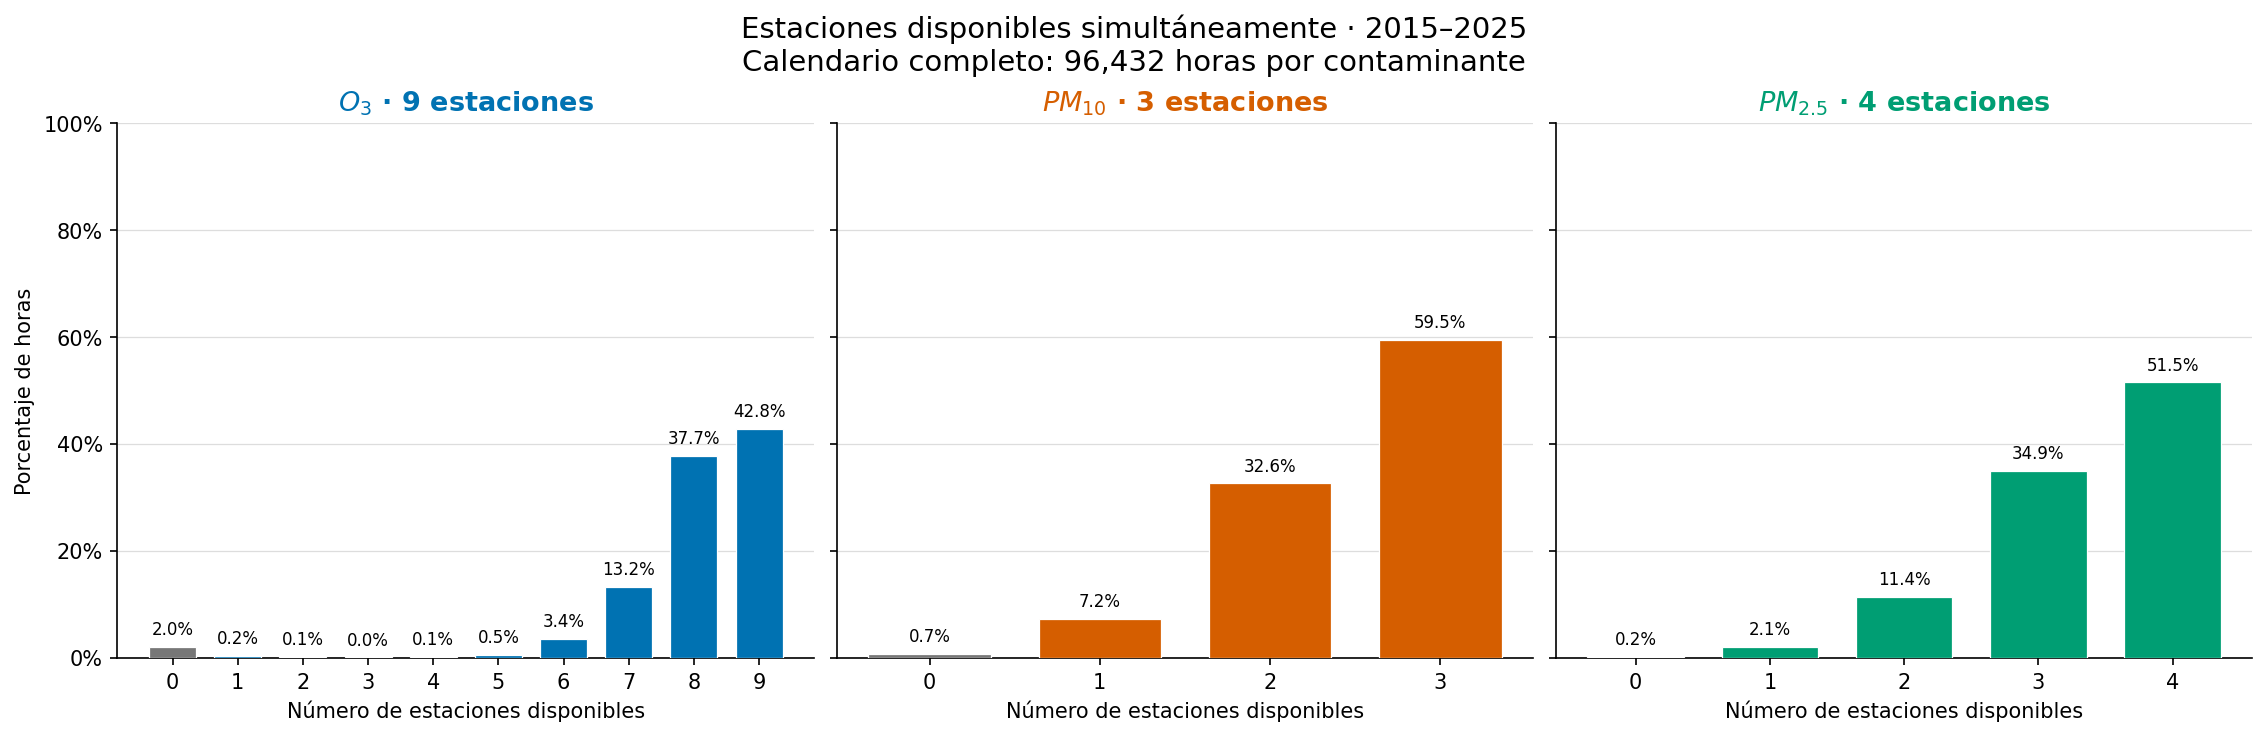

In [9]:
from matplotlib.ticker import PercentFormatter


DIR_RESULTADOS_01 = (
    RUTA_BASE / "resultados_01_base_horaria_RAMA"
)

DIR_FIGURAS_01 = DIR_RESULTADOS_01 / "figuras"
DIR_FIGURAS_01.mkdir(parents=True, exist_ok=True)

COLORES_CONTAMINANTES = {
    "O3": "#0072B2",
    "PM10": "#D55E00",
    "PM25": "#009E73",
}

NOMBRES_CONTAMINANTES = {
    "O3": r"$O_3$",
    "PM10": r"$PM_{10}$",
    "PM25": r"$PM_{2.5}$",
}

registros_distribucion = []

for contaminante in CONTAMINANTES:
    k = series_estaciones_disponibles[contaminante]
    n_estaciones = len(REDES_SELECCIONADAS[contaminante])

    conteos = k.value_counts().reindex(range(n_estaciones + 1), fill_value=0).sort_index()
    
    if int(conteos.sum()) != len(INDICE_HORARIO_COMPLETO):
        raise ValueError(f"Los conteos horarios no coinciden en {contaminante}.")

    for n_disponibles, n_horas in conteos.items():
        registros_distribucion.append(
            {
                "CONTAMINANTE": contaminante,
                "N_ESTACIONES_DISPONIBLES": int(n_disponibles),
                "N_HORAS": int(n_horas),
                "PCT_HORAS": 100 * n_horas / len(k),
            }
        )

distribucion_estaciones_disponibles = pd.DataFrame(registros_distribucion)

print("Distribución del número de estaciones disponibles:")
with pd.option_context("display.precision", 2):
    display(distribucion_estaciones_disponibles)


fig_distribucion_estaciones, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.8),
    sharey=True,
    dpi=150,
    constrained_layout=True,
)

for ax, contaminante in zip(axes, CONTAMINANTES):
    datos = distribucion_estaciones_disponibles.loc[
        distribucion_estaciones_disponibles["CONTAMINANTE"].eq(contaminante)]

    x = datos["N_ESTACIONES_DISPONIBLES"].to_numpy()
    porcentajes = datos["PCT_HORAS"].to_numpy()

    colores = [
        "#777777" if numero == 0
        else COLORES_CONTAMINANTES[contaminante]
        for numero in x
    ]

    ax.bar(
        x,
        porcentajes,
        color=colores,
        width=0.72,
        edgecolor="white",
        linewidth=0.6,
        zorder=3,
    )

    for numero, porcentaje in zip(x, porcentajes):
        ax.annotate(
            f"{porcentaje:.1f}%",
            xy=(numero, porcentaje),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    n_estaciones = len(REDES_SELECCIONADAS[contaminante])

    ax.set_title(
        f"{NOMBRES_CONTAMINANTES[contaminante]} "
        f"· {n_estaciones} estaciones",
        color=COLORES_CONTAMINANTES[contaminante],
        fontsize=13,
        fontweight="bold",
    )

    ax.set_xlabel("Número de estaciones disponibles")
    ax.set_xticks(x)
    ax.set_ylim(0, 100)
    ax.set_yticks(range(0, 101, 20))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    ax.grid(axis="y", color="#DDDDDD", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Porcentaje de horas")

fig_distribucion_estaciones.suptitle(
    "Estaciones disponibles simultáneamente · 2015–2025\n"
    "Calendario completo: 96,432 horas por contaminante",
    fontsize=14,
)

ruta_fig_distribucion_estaciones = (
    DIR_FIGURAS_01
    / "distribucion_estaciones_disponibles_2015_2025.png"
)

fig_distribucion_estaciones.savefig(
    ruta_fig_distribucion_estaciones,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 2. Exploración de las concentraciones horarias

Una vez verificada la estructura de las bases, estudiaremos cómo se
distribuyen las concentraciones observadas en cada estación.

Esta exploración permitirá identificar diferencias entre estaciones,
examinar la amplitud de los valores y reconocer observaciones que
requieran una revisión posterior.

Las unidades todavía están pendientes de confirmación documental.
Por ello, los resultados de esta sección se expresarán en la
**escala original de los archivos**, sin realizar conversiones ni
comparaciones con umbrales normativos.

## 2.1. Estadísticos descriptivos por contaminante y estación

Calcularemos los siguientes estadísticos utilizando únicamente las
mediciones disponibles:

| Estadístico | Interpretación |
|---|---|
| Número de observaciones | Cantidad de mediciones no faltantes |
| Media | Promedio de las concentraciones observadas |
| Desviación estándar | Dispersión de las concentraciones alrededor de la media |
| Mínimo | Menor valor observado |
| Percentil 1 | Referencia de la parte baja de la distribución |
| Percentil 25 | Primer cuartil |
| Mediana | Valor central de la distribución |
| Percentil 75 | Tercer cuartil |
| Percentil 95 | Referencia de la parte alta de la distribución |
| Percentil 99 | Referencia de la cola superior |
| Máximo | Mayor valor observado |

### Media y mediana

La media utiliza todos los valores y puede cambiar considerablemente
cuando existen concentraciones muy altas.

La mediana divide las observaciones ordenadas en dos partes y es menos
sensible a esos valores. Comparar ambas ayuda a describir la forma de
la distribución, aunque no sustituye su inspección gráfica.

### Percentiles y rango intercuartílico

El percentil $p$ indica una posición dentro de la distribución ordenada.
Por ejemplo, el percentil 95 sirve como referencia del nivel por debajo
del cual se encuentra aproximadamente el 95% de las observaciones.

Debido a valores repetidos e interpolación, las proporciones exactas
pueden diferir ligeramente de esa interpretación.

También calcularemos el rango intercuartílico:

$$
RIC=Q_{75}-Q_{25}.
$$

El RIC describe la amplitud de la mitad central de la distribución
y resulta menos sensible a los extremos que el rango entre mínimo
y máximo.

### Tratamiento de faltantes y extremos

Los valores `NaN` no participarán en los estadísticos. Los ceros sí
participarán, porque no se han identificado como códigos faltantes.

No eliminaremos ni recortaremos las observaciones altas. Los
percentiles 95 y 99 se usarán aquí como descriptores; **no constituyen
todavía umbrales para definir episodios extremos**.

Estos resúmenes combinan los once años de estudio. Por tanto, no
describen por separado los cambios anuales, estacionales o por hora
del día, que se examinarán posteriormente.

Además, cada estación puede tener mediciones disponibles en momentos
diferentes. Una diferencia entre sus promedios puede reflejar tanto
diferencias de concentración como diferencias en los periodos observados.
Las comparaciones directas entre estaciones requerirán revisar las
horas compartidas.

In [10]:
registros_descriptivos = []

for contaminante in CONTAMINANTES:
    base = bases_horarias[contaminante]

    for estacion in REDES_SELECCIONADAS[contaminante]:
        serie = base[estacion]
        observados = serie.dropna()

        percentiles = observados.quantile([0.01, 0.25, 0.50, 0.75, 0.95, 0.99])

        registros_descriptivos.append(
            {
                "CONTAMINANTE": contaminante,
                "ESTACION": estacion,
                "N_OBSERVADOS": len(observados),
                "N_FALTANTES": int(serie.isna().sum()),
                "N_CEROS": int(observados.eq(0).sum()),
                "MEDIA": observados.mean(),
                "DESV_ESTANDAR": observados.std(ddof=1),
                "MINIMO": observados.min(),
                "P01": percentiles.loc[0.01],
                "P25": percentiles.loc[0.25],
                "MEDIANA": percentiles.loc[0.50],
                "P75": percentiles.loc[0.75],
                "P95": percentiles.loc[0.95],
                "P99": percentiles.loc[0.99],
                "MAXIMO": observados.max(),
                "RIC": (
                    percentiles.loc[0.75]
                    - percentiles.loc[0.25]
                ),
            }
        )

descriptivos_concentraciones = pd.DataFrame(registros_descriptivos)

# Comprobar que los conteos coincidan con la preparación anterior.
verificacion_conteos_descriptivos = (
    descriptivos_concentraciones[
        ["CONTAMINANTE", "ESTACION", "N_OBSERVADOS", "N_FALTANTES"]
    ]
    .merge(
        resumen_preparacion_estaciones[["CONTAMINANTE","ESTACION","N_OBSERVADOS","N_FALTANTES_TOTAL",]],
        on=["CONTAMINANTE", "ESTACION"],
        how="outer",
        suffixes=("_DESCRIPTIVOS", "_PREPARACION"),
        validate="one_to_one",
        indicator=True,
    )
)

conteos_correctos = (
    verificacion_conteos_descriptivos["_merge"].eq("both")
    & verificacion_conteos_descriptivos[
        "N_OBSERVADOS_DESCRIPTIVOS"
    ].eq(
        verificacion_conteos_descriptivos[
            "N_OBSERVADOS_PREPARACION"
        ]
    )
    & verificacion_conteos_descriptivos["N_FALTANTES"].eq(
        verificacion_conteos_descriptivos["N_FALTANTES_TOTAL"]
    )
)

if not conteos_correctos.all():
    display(
        verificacion_conteos_descriptivos.loc[~conteos_correctos]
    )
    raise ValueError(
        "Los conteos descriptivos no coinciden con la preparación."
    )

print("Estadísticos sobre las concentraciones observadas, 2015–2025.")
print("Escala original de los archivos; unidades pendientes de confirmar.")

for contaminante in CONTAMINANTES:
    print(f"\n{contaminante}")

    with pd.option_context(
        "display.max_columns", None,
        "display.precision", 2,
    ):
        display(
            descriptivos_concentraciones.loc[
                descriptivos_concentraciones[
                    "CONTAMINANTE"
                ].eq(contaminante)
            ].reset_index(drop=True)
        )

print("\nLos conteos coinciden con la preparación de las bases.")
print("No se eliminaron extremos ni se imputaron valores.")
print("Los estadísticos se conservan sin redondear en la tabla.")

Estadísticos sobre las concentraciones observadas, 2015–2025.
Escala original de los archivos; unidades pendientes de confirmar.

O3


,CONTAMINANTE,ESTACION,N_OBSERVADOS,N_FALTANTES,N_CEROS,MEDIA,DESV_ESTANDAR,MINIMO,P01,P25,MEDIANA,P75,P95,P99,MAXIMO,RIC
0,O3,CCA,88318,8114,428,33.31,29.94,0.0,1.0,9.0,24.0,51.0,94.0,119.0,185.0,42.0
1,O3,CUT,85605,10827,985,26.98,24.76,0.0,0.0,6.0,20.0,42.0,75.0,99.0,181.0,36.0
2,O3,FAC,86657,9775,565,29.25,25.63,0.0,1.0,9.0,22.0,43.0,81.0,106.0,185.0,34.0
3,O3,MER,87588,8844,925,26.24,27.17,0.0,0.0,4.0,16.0,41.0,83.0,107.0,166.0,37.0
4,O3,MGH,88638,7794,1417,29.27,28.04,0.0,0.0,7.0,20.0,44.0,87.0,113.0,190.0,37.0
5,O3,PED,84654,11778,398,34.97,29.05,0.0,1.0,13.0,26.0,51.0,94.0,121.0,183.0,38.0
6,O3,TLA,85208,11224,613,26.39,25.23,0.0,1.0,6.0,18.0,40.0,77.0,103.0,180.0,34.0
7,O3,UAX,84627,11805,854,33.45,29.56,0.0,0.0,9.0,25.0,52.0,92.0,117.0,176.0,43.0
8,O3,UIZ,82947,13485,532,29.68,27.97,0.0,1.0,6.0,21.0,47.0,86.0,109.0,167.0,41.0



PM10


,CONTAMINANTE,ESTACION,N_OBSERVADOS,N_FALTANTES,N_CEROS,MEDIA,DESV_ESTANDAR,MINIMO,P01,P25,MEDIANA,P75,P95,P99,MAXIMO,RIC
0,PM10,CUT,84199,12233,0,48.09,35.49,1.0,3.0,24.0,40.0,62.0,116.0,175.0,584.0,38.0
1,PM10,MER,81530,14902,0,44.95,25.12,2.0,7.0,27.0,41.0,58.0,91.0,124.0,468.0,31.0
2,PM10,TLA,76178,20254,0,48.59,25.96,1.0,10.0,30.0,44.0,62.0,96.0,131.0,550.0,32.0



PM25


,CONTAMINANTE,ESTACION,N_OBSERVADOS,N_FALTANTES,N_CEROS,MEDIA,DESV_ESTANDAR,MINIMO,P01,P25,MEDIANA,P75,P95,P99,MAXIMO,RIC
0,PM25,CCA,86476,9956,0,18.33,11.21,1.0,2.0,10.0,17.0,24.0,38.0,55.0,302.0,14.0
1,PM25,MER,81530,14902,0,23.83,14.97,1.0,1.0,13.0,21.0,32.0,50.0,70.0,380.0,19.0
2,PM25,TLA,76178,20254,0,23.48,13.92,1.0,2.0,14.0,21.0,31.0,49.0,68.0,212.0,17.0
3,PM25,UAX,79333,17099,0,20.07,12.96,1.0,1.0,11.0,18.0,26.0,42.0,60.0,209.0,15.0



Los conteos coinciden con la preparación de las bases.
No se eliminaron extremos ni se imputaron valores.
Los estadísticos se conservan sin redondear en la tabla.


## 2.2. Comparación visual de las distribuciones por estación

Los estadísticos descriptivos muestran diferencias entre la concentración
habitual y los valores más altos de cada serie.

Para representarlas construiremos una figura con tres paneles,
uno por contaminante, utilizando diagramas de caja.

### Elementos del diagrama

En esta figura:

- La caja abarcará desde el percentil 25 hasta el percentil 75.
- La línea dentro de la caja indicará la mediana.
- El rombo indicará la media.
- Los bigotes se extenderán hasta los valores observados próximos
  a los percentiles 1 y 99.
- Un triángulo adicional indicará el máximo observado.

Los bigotes se definirán explícitamente mediante percentiles,
en lugar de utilizar la regla habitual de 1.5 veces el rango
intercuartílico.

### ¿Por qué utilizar bigotes entre los percentiles 1 y 99?

Esta representación permite comparar la parte central y una porción
amplia de la distribución sin dibujar decenas de miles de puntos
superpuestos.

Las observaciones fuera de los bigotes seguirán presentes en las bases
y en los estadísticos. No se eliminarán ni se sustituirán.

El máximo se mostrará por separado para indicar hasta dónde se extiende
la distribución. Puede corresponder a una sola observación o a varias
observaciones con el mismo valor.

### Interpretación y límites

Una media por encima de la mediana es compatible con una distribución
que se extiende hacia concentraciones altas. La posición del máximo
permite reconocer cuánto se aleja del grueso de las observaciones,
pero no establece que sea un error de medición.

Las escalas verticales serán independientes para cada contaminante,
porque sus rangos son diferentes y las unidades aún están pendientes
de confirmación.

Los valores se mostrarán en la escala original. La figura permitirá
comparar estaciones dentro de cada contaminante, sin comparar
directamente la magnitud de O₃ con la de las partículas.

Además, las distribuciones utilizan todas las mediciones disponibles
de cada estación. Como sus periodos observados no coinciden por completo,
esta comparación es descriptiva y no demuestra por sí sola una
diferencia espacial persistente.

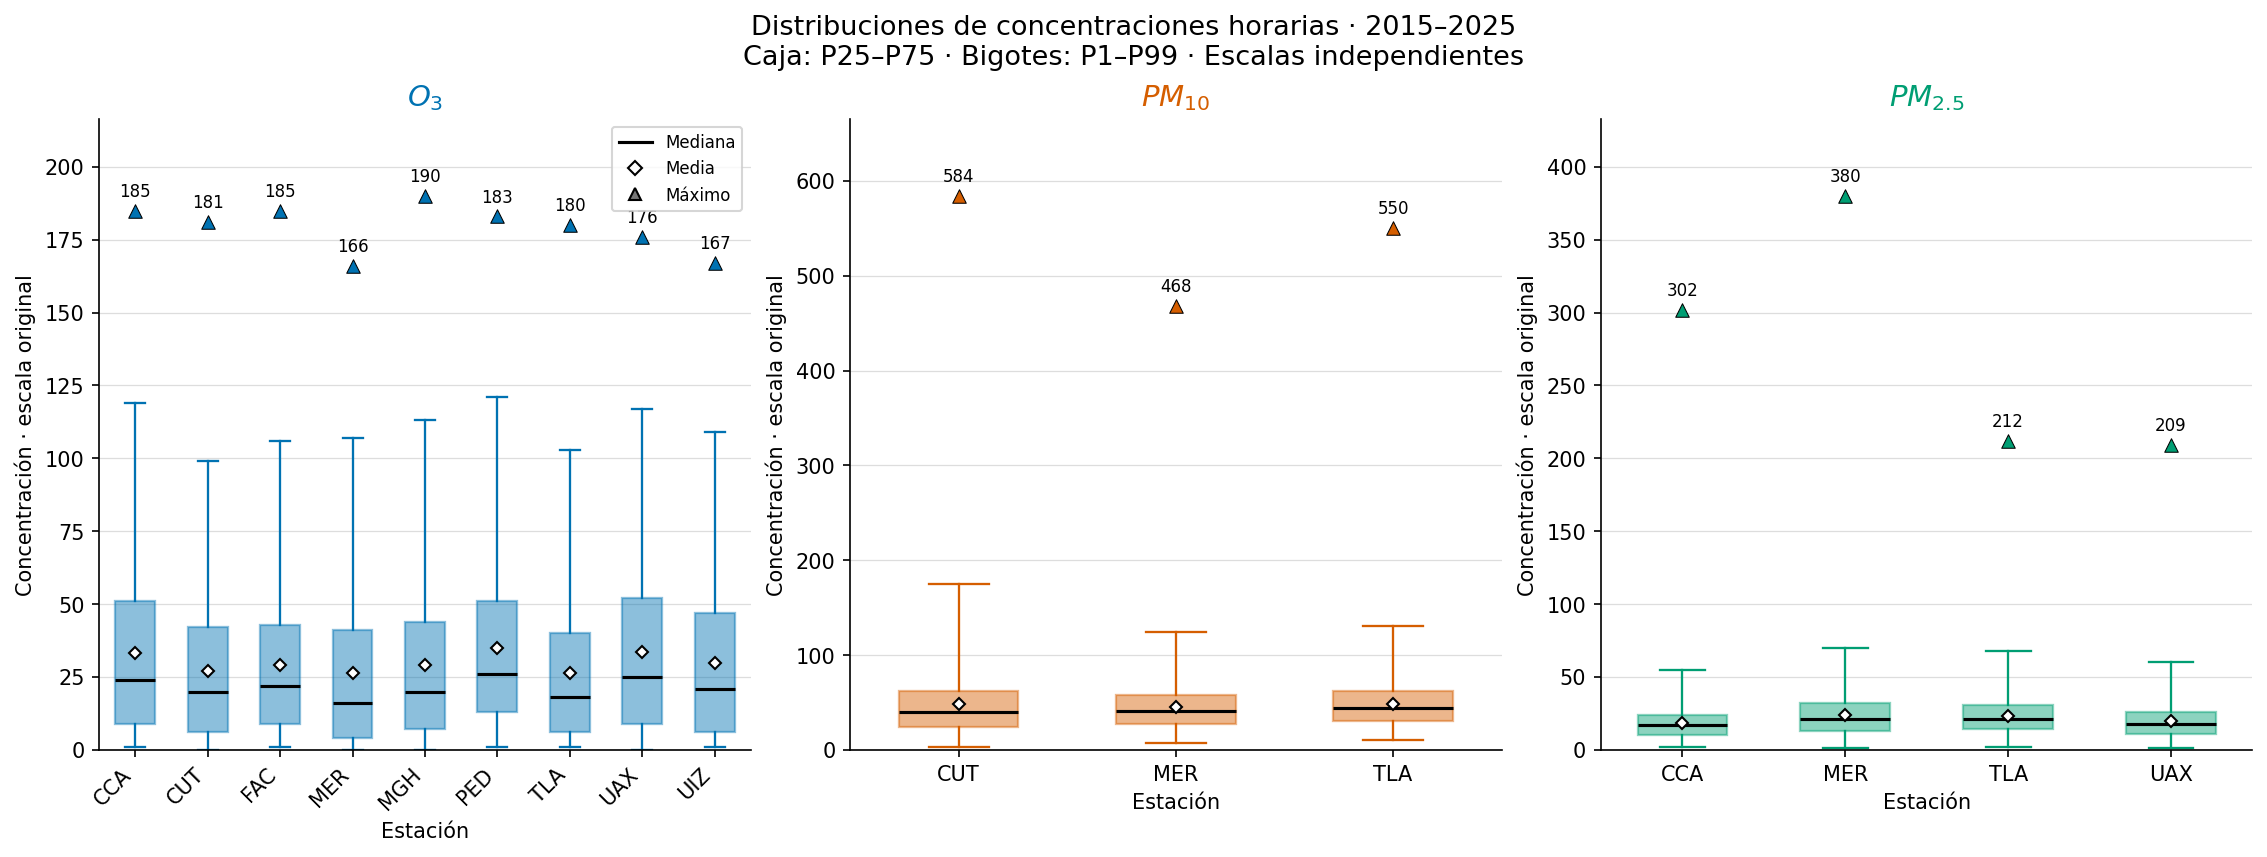


Unidades pendientes de confirmar.
Las observaciones fuera de los bigotes permanecen en las bases.


In [11]:
from matplotlib.lines import Line2D


fig_distribuciones_concentracion, axes = plt.subplots(1,3,figsize=(15, 5.6),dpi=150,constrained_layout=True,)

for ax, contaminante in zip(axes, CONTAMINANTES):
    estaciones = REDES_SELECCIONADAS[contaminante]

    series_observadas = [
        bases_horarias[contaminante][estacion]
        .dropna()
        .to_numpy()
        for estacion in estaciones
    ]

    if any(len(serie) == 0 for serie in series_observadas):
        raise ValueError(f"Hay una estación sin observaciones en {contaminante}.")

    posiciones = np.arange(1, len(estaciones) + 1)
    color = COLORES_CONTAMINANTES[contaminante]

    ax.boxplot(
        series_observadas,
        positions=posiciones,
        widths=0.55,
        whis=(1, 99),
        showfliers=False,
        showmeans=True,
        patch_artist=True,
        boxprops={"facecolor": color,"edgecolor": color,"alpha": 0.45,"linewidth": 1.1,},
        medianprops={"color": "black","linewidth": 1.5,},
        whiskerprops={"color": color,"linewidth": 1.1,},
        capprops={"color": color,"linewidth": 1.1,},
        meanprops={
            "marker": "D",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 4,
        },
    )

    maximos = np.array([
        serie.max() for serie in series_observadas
    ])

    ax.scatter(
        posiciones,
        maximos,
        marker="^",
        s=42,
        facecolor=color,
        edgecolor="black",
        linewidth=0.5,
        zorder=4,
    )

    for posicion, maximo in zip(posiciones, maximos):
        ax.annotate(
            f"{maximo:g}",
            xy=(posicion, maximo),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.set_xticks(posiciones)
    ax.set_xticklabels(
        estaciones,
        rotation=45 if len(estaciones) > 5 else 0,
        ha="right" if len(estaciones) > 5 else "center",
    )

    ax.set_ylim(0, maximos.max() * 1.14)
    ax.set_xlabel("Estación")
    ax.set_ylabel("Concentración · escala original")
    ax.set_title(NOMBRES_CONTAMINANTES[contaminante],color=color,fontsize=14,fontweight="bold",)

    ax.grid(axis="y",color="#DDDDDD",linewidth=0.6,)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


leyenda_distribuciones = [
    Line2D(
        [0], [0],
        color="black",
        linewidth=1.5,
        label="Mediana",
    ),
    Line2D(
        [0], [0],
        marker="D",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=5,
        label="Media",
    ),
    Line2D(
        [0], [0],
        marker="^",
        linestyle="None",
        markerfacecolor="#777777",
        markeredgecolor="black",
        markersize=6,
        label="Máximo",
    ),
]

axes[0].legend(handles=leyenda_distribuciones,loc="upper right",fontsize=8,frameon=True,)

fig_distribuciones_concentracion.suptitle(
    "Distribuciones de concentraciones horarias · 2015–2025\n"
    "Caja: P25–P75 · Bigotes: P1–P99 · Escalas independientes",
    fontsize=13,
)

ruta_fig_distribuciones_concentracion = (
    DIR_FIGURAS_01
    / "distribuciones_concentracion_estaciones_2015_2025.png"
)

fig_distribuciones_concentracion.savefig(
    ruta_fig_distribuciones_concentracion,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("\nUnidades pendientes de confirmar.")
print("Las observaciones fuera de los bigotes permanecen en las bases.")

## 2.3. Revisión del contexto temporal de los máximos

Un máximo resume el valor más alto de una serie, pero no muestra
su contexto.

Para examinarlo necesitamos conocer:

- La fecha y el código horario del registro.
- Las concentraciones de la misma estación una hora antes y una hora después.
- Cuántas estaciones adicionales tenían mediciones en esa hora.
- Las concentraciones observadas en esas otras estaciones.

### Identificación de los máximos

Localizaremos todas las horas en las que cada estación alcanza su
máximo del periodo 2015–2025.

Si el mismo máximo aparece varias veces, conservaremos todas sus
ocurrencias. Así evitaremos seleccionar arbitrariamente una sola fecha.

También mostraremos el percentil 99 de cada serie como referencia
descriptiva de su cola superior.

### Comparación con las horas vecinas

Las concentraciones anterior y posterior corresponderán a horas
consecutivas del calendario completo:

$$
X_{t-1},\qquad X_t,\qquad X_{t+1}.
$$

Si una hora vecina no tiene medición, aparecerá como `NaN`.
No utilizaremos la observación disponible más cercana, porque podría
estar separada por varias horas y producir una comparación engañosa.

Un aumento breve o un máximo muy separado de sus vecinos puede
motivar una revisión, pero no demuestra por sí solo un error.

### Comparación con otras estaciones

Para la misma hora del máximo calcularemos:

- El número de otras estaciones con mediciones disponibles.
- La mediana de sus concentraciones.
- El máximo de sus concentraciones.

La estación que estamos examinando quedará excluida de estos cálculos.
De lo contrario, su propio máximo influiría en la referencia utilizada
para compararlo.

Si ninguna otra estación tiene datos, los resúmenes aparecerán como
`NaN` y el número de otras estaciones disponibles será cero.

Estos resultados ayudan a distinguir un valor elevado registrado
en varias ubicaciones de uno observado únicamente en una estación.
Sin embargo, un episodio localizado no tiene que manifestarse con
la misma intensidad en toda la red.

### Alcance de la revisión

Conservaremos todos los máximos. Esta sección no asigna etiquetas
de error ni define episodios extremos.

La fecha y la hora originales se recuperarán de la referencia interna:

- `FECHA` corresponde al día del índice.
- `HORA` corresponde a la hora del índice más uno.

Esta recuperación reproduce los códigos originales ya validados;
no confirma todavía el inicio o el final del intervalo de medición
ni su zona horaria.

In [12]:
registros_contexto_maximos = []

for contaminante in CONTAMINANTES:
    base = bases_horarias[contaminante]

    for estacion in REDES_SELECCIONADAS[contaminante]:
        serie = base[estacion]
        maximo = serie.max()

        if pd.isna(maximo):
            raise ValueError(
                f"No hay observaciones en {contaminante}, {estacion}."
            )

        tiempos_maximo = serie.index[serie.eq(maximo)]

        # Desplazar sobre el calendario completo, sin eliminar NaN.
        valores_anteriores = serie.shift(1)
        valores_posteriores = serie.shift(-1)

        otras_estaciones = base.drop(columns=estacion)

        referencia_p99 = descriptivos_concentraciones.loc[
            descriptivos_concentraciones["CONTAMINANTE"].eq(
                contaminante
            )
            & descriptivos_concentraciones["ESTACION"].eq(estacion),
            "P99",
        ].iloc[0]

        for tiempo in tiempos_maximo:
            otras_en_hora = otras_estaciones.loc[tiempo].dropna()

            registros_contexto_maximos.append(
                {
                    "CONTAMINANTE": contaminante,
                    "ESTACION": estacion,
                    "FECHA": tiempo.normalize(),
                    "HORA_ORIGINAL": tiempo.hour + 1,
                    "TIEMPO_INTERNO": tiempo,
                    "MAXIMO": maximo,
                    "P99_ESTACION": referencia_p99,
                    "VALOR_HORA_ANTERIOR": valores_anteriores.loc[tiempo],
                    "VALOR_HORA_POSTERIOR": valores_posteriores.loc[tiempo],
                    "N_OTRAS_ESTACIONES": len(otras_en_hora),
                    "MEDIANA_OTRAS_ESTACIONES": otras_en_hora.median(),
                    "MAXIMO_OTRAS_ESTACIONES": otras_en_hora.max(),
                    "N_OCURRENCIAS_MAXIMO": len(tiempos_maximo),
                }
            )

contexto_maximos_estaciones = (
    pd.DataFrame(registros_contexto_maximos)
    .sort_values(["CONTAMINANTE", "ESTACION", "TIEMPO_INTERNO"])
    .reset_index(drop=True)
)

columnas_mostrar = [
    "ESTACION",
    "FECHA",
    "HORA_ORIGINAL",
    "MAXIMO",
    "P99_ESTACION",
    "VALOR_HORA_ANTERIOR",
    "VALOR_HORA_POSTERIOR",
    "N_OTRAS_ESTACIONES",
    "MEDIANA_OTRAS_ESTACIONES",
    "MAXIMO_OTRAS_ESTACIONES",
    "N_OCURRENCIAS_MAXIMO",
]

print("Contexto de todas las ocurrencias de los máximos por estación.")
print("Concentraciones en la escala original de los archivos.")

for contaminante in CONTAMINANTES:
    print(f"\n{contaminante}")

    with pd.option_context("display.max_columns", None,"display.precision", 2,):
        display(
            contexto_maximos_estaciones.loc[
                contexto_maximos_estaciones["CONTAMINANTE"].eq(contaminante),
                columnas_mostrar,
            ].reset_index(drop=True)
        )

print(
    "\nTotal de ocurrencias de máximos:",
    len(contexto_maximos_estaciones),
)
print("Las referencias de otras estaciones excluyen la estación evaluada.")
print("No se eliminaron mediciones ni se definieron episodios.")

Contexto de todas las ocurrencias de los máximos por estación.
Concentraciones en la escala original de los archivos.

O3


,ESTACION,FECHA,HORA_ORIGINAL,MAXIMO,P99_ESTACION,VALOR_HORA_ANTERIOR,VALOR_HORA_POSTERIOR,N_OTRAS_ESTACIONES,MEDIANA_OTRAS_ESTACIONES,MAXIMO_OTRAS_ESTACIONES,N_OCURRENCIAS_MAXIMO
0,CCA,2017-05-23,17,185.0,119.0,144.0,123.0,8,145.0,163.0,1
1,CUT,2024-05-14,17,181.0,99.0,179.0,149.0,8,118.0,172.0,1
2,FAC,2016-03-14,17,185.0,106.0,177.0,158.0,7,135.0,190.0,1
3,MER,2017-05-23,16,166.0,107.0,164.0,140.0,8,135.0,166.0,2
4,MER,2024-02-24,16,166.0,107.0,147.0,147.0,7,118.0,140.0,2
5,MGH,2016-03-14,17,190.0,113.0,187.0,150.0,7,135.0,185.0,1
6,PED,2016-05-04,14,183.0,121.0,151.0,164.0,8,108.5,171.0,1
7,TLA,2024-05-14,16,180.0,103.0,175.0,172.0,8,143.5,179.0,1
8,UAX,2024-02-22,16,176.0,117.0,148.0,145.0,7,130.0,171.0,1
9,UIZ,2017-05-23,15,167.0,109.0,148.0,166.0,8,117.5,164.0,1



PM10


,ESTACION,FECHA,HORA_ORIGINAL,MAXIMO,P99_ESTACION,VALOR_HORA_ANTERIOR,VALOR_HORA_POSTERIOR,N_OTRAS_ESTACIONES,MEDIANA_OTRAS_ESTACIONES,MAXIMO_OTRAS_ESTACIONES,N_OCURRENCIAS_MAXIMO
0,CUT,2021-03-28,16,584.0,175.0,71.0,561.0,2,180.5,228.0,1
1,MER,2016-02-14,9,468.0,124.0,368.0,286.0,2,97.0,110.0,1
2,TLA,2022-01-02,18,550.0,131.0,217.0,178.0,2,107.5,138.0,1



PM25


,ESTACION,FECHA,HORA_ORIGINAL,MAXIMO,P99_ESTACION,VALOR_HORA_ANTERIOR,VALOR_HORA_POSTERIOR,N_OTRAS_ESTACIONES,MEDIANA_OTRAS_ESTACIONES,MAXIMO_OTRAS_ESTACIONES,N_OCURRENCIAS_MAXIMO
0,CCA,2015-12-25,11,302.0,55.0,114.0,157.0,3,147.0,164.0,1
1,MER,2016-02-14,9,380.0,70.0,288.0,220.0,3,38.0,57.0,1
2,TLA,2016-01-01,3,212.0,68.0,123.0,184.0,3,125.0,148.0,1
3,UAX,2017-04-01,16,209.0,60.0,175.0,67.0,3,14.0,20.0,1



Total de ocurrencias de máximos: 17
Las referencias de otras estaciones excluyen la estación evaluada.
No se eliminaron mediciones ni se definieron episodios.


## 2.4. Evolución horaria alrededor de los máximos más altos

La tabla anterior mostró que los máximos tienen contextos diferentes:
algunos ocurren junto con concentraciones elevadas en varias estaciones,
mientras que otros presentan un contraste espacial mayor.

Para examinar su evolución construiremos una figura con tres paneles.
En cada contaminante seleccionaremos el máximo más alto de su red:

- **O₃:** MGH, 14 de marzo de 2016, hora original 17.
- **PM₁₀:** CUT, 28 de marzo de 2021, hora original 16.
- **PM₂.₅:** MER, 14 de febrero de 2016, hora original 9.

La selección se realizará automáticamente desde la tabla de máximos.
Si hubiera un empate, se elegirá primero la ocurrencia más temprana
y después la clave de estación en orden alfabético.

### Ventana de observación

Mostraremos las 24 horas anteriores y las 24 posteriores al máximo,
incluyendo la hora central: una ventana de 49 posiciones horarias.

El eje horizontal representará el tiempo relativo al máximo:

$$
\tau=t-t_{\max}.
$$

Por tanto:

- $\tau=-1$ corresponde a una hora antes.
- $\tau=0$ corresponde a la hora del máximo.
- $\tau=1$ corresponde a una hora después.

Esta representación utiliza diferencias entre posiciones del índice
interno. No requiere asignar todavía una zona horaria.

### Estaciones representadas

En cada panel:

- La estación donde ocurre el máximo se mostrará con una línea gruesa
  del color del contaminante.
- Las demás estaciones se mostrarán con líneas más delgadas.
- Una línea vertical marcará la hora central.
- Un punto destacará el máximo seleccionado.

Los valores faltantes producirán interrupciones en las líneas.
No se interpolarán mediciones.

Las líneas conectan observaciones horarias para facilitar su lectura;
no representan mediciones realizadas entre esas horas.

### Alcance de la figura

La comparación ayudará a observar la duración del aumento y su
coincidencia temporal con otras estaciones.

Sin embargo, la figura no permite por sí sola confirmar la calidad
instrumental, identificar una fuente de emisión ni declarar una
contingencia oficial.

Además, estos casos fueron seleccionados por ser máximos. No
representan necesariamente el comportamiento habitual de las redes.

Las escalas verticales serán independientes y las concentraciones
se mostrarán en la escala original de los archivos.

Casos seleccionados para la figura:
  CONTAMINANTE ESTACION      FECHA  HORA_ORIGINAL  MAXIMO
0           O3      MGH 2016-03-14             17   190.0
1         PM10      CUT 2021-03-28             16   584.0
2         PM25      MER 2016-02-14              9   380.0


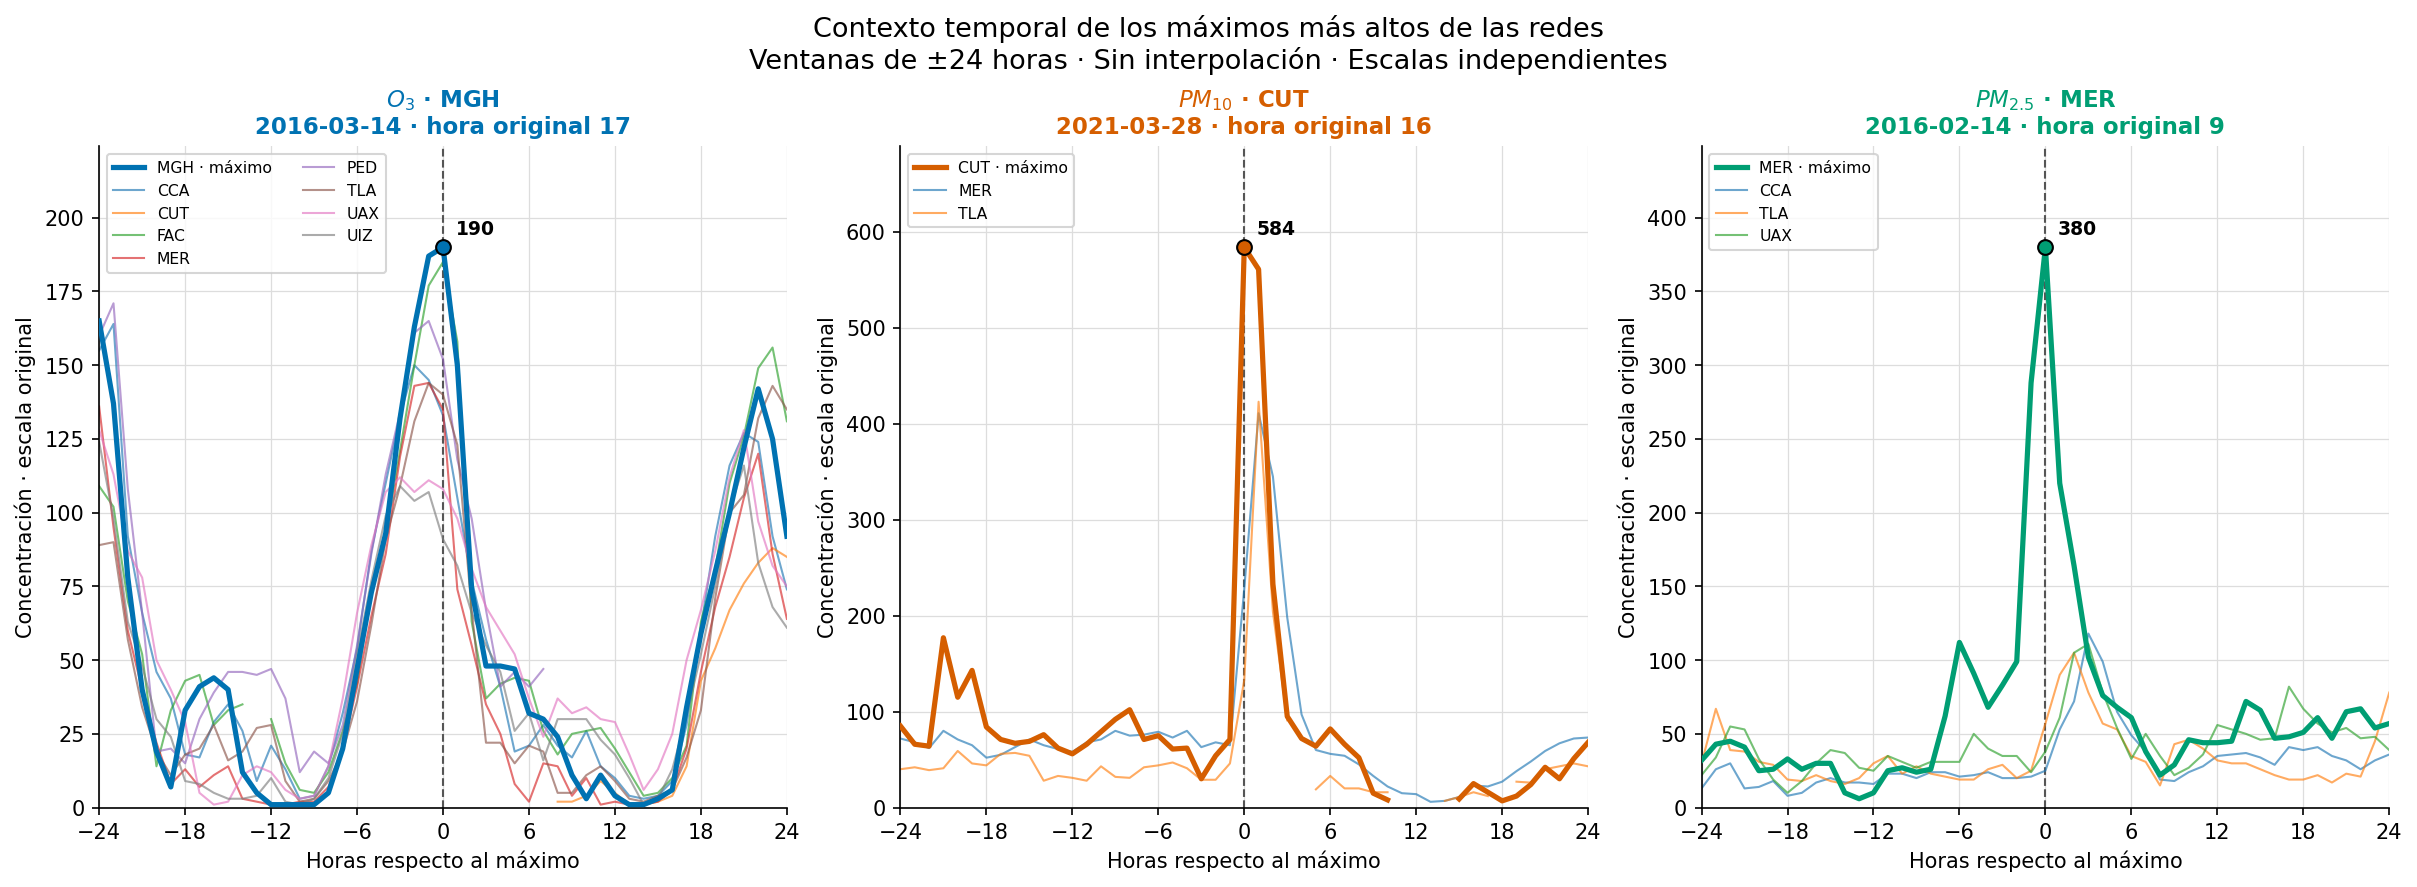

In [13]:
# Elegir un caso por contaminante.
casos_maximos_seleccionados = (
    contexto_maximos_estaciones
    .sort_values(
        ["CONTAMINANTE", "MAXIMO", "TIEMPO_INTERNO", "ESTACION"],
        ascending=[True, False, True, True],
    )
    .drop_duplicates("CONTAMINANTE", keep="first")
    .set_index("CONTAMINANTE")
    .loc[CONTAMINANTES]
    .reset_index()
)

print("Casos seleccionados para la figura:")
print(
    casos_maximos_seleccionados[
        [
            "CONTAMINANTE",
            "ESTACION",
            "FECHA",
            "HORA_ORIGINAL",
            "MAXIMO",
        ]
    ]
)

fig_contexto_maximos, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5.8),
    dpi=150,
    constrained_layout=True,
)

ventanas_maximos = {}

for ax, contaminante in zip(axes, CONTAMINANTES):
    caso = casos_maximos_seleccionados.loc[
        casos_maximos_seleccionados["CONTAMINANTE"].eq(contaminante)
    ].iloc[0]

    estacion_maximo = caso["ESTACION"]
    tiempo_maximo = caso["TIEMPO_INTERNO"]
    color = COLORES_CONTAMINANTES[contaminante]

    indice_ventana = pd.date_range(
        start=tiempo_maximo - pd.Timedelta(hours=24),
        end=tiempo_maximo + pd.Timedelta(hours=24),
        freq="h",
        name="TIEMPO_INTERNO",
    )

    ventana = bases_horarias[contaminante].reindex(indice_ventana)
    ventanas_maximos[contaminante] = ventana

    horas_relativas = np.asarray((ventana.index - tiempo_maximo) / pd.Timedelta(hours=1),dtype=float,)

    otras_estaciones = [
        estacion
        for estacion in ventana.columns
        if estacion != estacion_maximo
    ]

    colores_contexto = plt.get_cmap("tab10")

    for i, estacion in enumerate(otras_estaciones):
        ax.plot(
            horas_relativas,
            ventana[estacion],
            color=colores_contexto(i % 10),
            linewidth=1.0,
            alpha=0.65,
            label=estacion,
            zorder=2,
        )

    ax.plot(
        horas_relativas,
        ventana[estacion_maximo],
        color=color,
        linewidth=2.5,
        label=f"{estacion_maximo} · máximo",
        zorder=4,
    )

    ax.axvline(0,color="#555555",linestyle="--",linewidth=1,zorder=1,)
    ax.scatter([0],[caso["MAXIMO"]],color=color,edgecolor="black",s=50,zorder=5,)

    ax.annotate(
        f'{caso["MAXIMO"]:g}',
        xy=(0, caso["MAXIMO"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

    fecha_texto = pd.Timestamp(caso["FECHA"]).strftime("%Y-%m-%d")

    ax.set_title(
        f"{NOMBRES_CONTAMINANTES[contaminante]} · {estacion_maximo}\n"
        f"{fecha_texto} · hora original {int(caso['HORA_ORIGINAL'])}",
        color=color,
        fontsize=11,
        fontweight="bold",
    )

    ax.set_xlabel("Horas respecto al máximo")
    ax.set_ylabel("Concentración · escala original")
    ax.set_xlim(-24, 24)
    ax.set_xticks(np.arange(-24, 25, 6))

    maximo_ventana = ventana.max().max()
    ax.set_ylim(0, maximo_ventana * 1.18)

    ax.grid(color="#DDDDDD", linewidth=0.6)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        [handles[-1]] + handles[:-1],
        [labels[-1]] + labels[:-1],
        loc="upper left",
        fontsize=7.5,
        ncol=2 if len(ventana.columns) > 5 else 1,
        frameon=True,
    )

fig_contexto_maximos.suptitle(
    "Contexto temporal de los máximos más altos de las redes\n"
    "Ventanas de ±24 horas · Sin interpolación · Escalas independientes",
    fontsize=13,
)

ruta_fig_contexto_maximos = DIR_FIGURAS_01 / "contexto_temporal_maximos_redes_2015_2025.png"

fig_contexto_maximos.savefig(
    ruta_fig_contexto_maximos,
    dpi=300,
    bbox_inches="tight",
)

plt.show()



La figura muestra las 24 horas anteriores y posteriores al máximo
más alto de cada red. La línea vertical señala la hora del máximo;
la línea gruesa corresponde a la estación donde se registró.

**O₃ — MGH, 14 de marzo de 2016.**  
El máximo de 190 está acompañado por un aumento en varias estaciones.
Las curvas presentan incrementos y descensos aproximadamente coincidentes,
aunque sus magnitudes difieren. Dentro de esta ventana también se observan
concentraciones bajas entre los aumentos. El máximo de MGH forma parte
de una elevación compartida por distintas ubicaciones de la red.

**PM₁₀ — CUT, 28 de marzo de 2021.**  
CUT presenta un incremento abrupto que alcanza 584 y permanece elevado
en la hora siguiente, con 561. MER y TLA también registran aumentos
cercanos temporalmente, pero sus picos no coinciden exactamente con el
de CUT y tienen menor magnitud. La figura muestra un aumento en varias
estaciones con diferencias de intensidad y de momento.

**PM₂.₅ — MER, 14 de febrero de 2016.**  
MER alcanza 380 después de registrar 288 en la hora anterior y desciende
a 220 en la siguiente. Las otras estaciones muestran concentraciones
mucho menores en la hora central y aumentos posteriores de menor magnitud.
El contraste espacial es más marcado que en el caso de O₃.
Además, el máximo de PM₁₀ de MER ocurrió en esta misma fecha y código
horario, según la tabla anterior.

Estos patrones justifican conservar y revisar los extremos. La
coincidencia entre estaciones aporta contexto, pero no certifica la
calidad de las mediciones ni identifica la causa del aumento.

Los tres paneles utilizan escalas verticales independientes. Las
concentraciones permanecen en la escala original de los archivos y
las interrupciones de las líneas corresponden a valores faltantes.

## 2.5. Perfil de concentración por código horario

Las ventanas anteriores describen casos particulares. Ahora examinaremos
el comportamiento habitual de las concentraciones a lo largo del día,
utilizando todas las mediciones disponibles de 2015–2025.

Para cada contaminante y estación agruparemos las observaciones por
su código horario original, del 1 al 24.

Por ejemplo, el grupo `HORA_ORIGINAL = 1` reunirá las mediciones
registradas con ese código en todos los días del periodo de estudio.

### Estadísticos del perfil horario

En cada grupo calcularemos:

- Número de mediciones disponibles.
- Porcentaje de disponibilidad respecto a los días del periodo.
- Media.
- Mediana.
- Percentiles 25 y 75.

La mediana permitirá describir el nivel central de concentración
para cada código horario. Los percentiles 25 y 75 mostrarán la
variabilidad de la mitad central de las mediciones.

Estos percentiles **no son un intervalo de confianza**: describen
la dispersión de las observaciones, no la incertidumbre de la mediana.

### Disponibilidad por código horario

El calendario contiene 4,018 días. Por tanto, cada estación tiene
4,018 posiciones esperadas para cada uno de los 24 códigos horarios.

Calcularemos:

$$
\text{Disponibilidad}_{s,h}
=
100\frac{n_{s,h}}{4018},
$$

donde $n_{s,h}$ es el número de mediciones disponibles de la estación
$s$ para el código horario $h$.

Esto permitirá detectar si algunos códigos horarios tienen menos
información que otros.

### Resumen por estación

Identificaremos el código horario con la mediana más alta de cada
estación. Si varias horas comparten esa mediana, mostraremos todas.

La hora con mayor mediana describe el perfil habitual agregado.
No tiene que coincidir con la hora del máximo absoluto, que corresponde
a una observación extrema particular.

### Límites de interpretación

Los perfiles reúnen días de diferentes años y estaciones del año.
Por tanto, describen un patrón agregado, que puede ocultar cambios
temporales.

Además, los faltantes pueden afectar qué días participan en cada
grupo. Mostrar su disponibilidad ayuda a evaluar este aspecto.

Mantendremos los códigos originales 1–24. Hasta confirmar la
convención de la fuente, no los interpretaremos como horas de inicio
o final de un intervalo ni como horas de una zona horaria específica.

In [14]:
registros_perfil_horario = []

for contaminante in CONTAMINANTES:
    base = bases_horarias[contaminante]

    codigos_horarios = pd.Index(base.index.hour + 1,name="HORA_ORIGINAL",)

    horas_esperadas_por_codigo = (
        pd.Series(1, index=base.index)
        .groupby(codigos_horarios)
        .sum()
        .reindex(range(1, 25))
    )

    for estacion in REDES_SELECCIONADAS[contaminante]:
        grupos = base[estacion].groupby(codigos_horarios)

        conteos = grupos.count()
        medias = grupos.mean()
        medianas = grupos.median()
        p25 = grupos.quantile(0.25)
        p75 = grupos.quantile(0.75)

        for hora in range(1, 25):
            n_esperadas = int(horas_esperadas_por_codigo.loc[hora])
            n_observadas = int(conteos.loc[hora])

            registros_perfil_horario.append(
                {
                    "CONTAMINANTE": contaminante,
                    "ESTACION": estacion,
                    "HORA_ORIGINAL": hora,
                    "N_ESPERADAS": n_esperadas,
                    "N_OBSERVADAS": n_observadas,
                    "PCT_DISPONIBILIDAD": (
                        100 * n_observadas / n_esperadas
                    ),
                    "MEDIA": medias.loc[hora],
                    "MEDIANA": medianas.loc[hora],
                    "P25": p25.loc[hora],
                    "P75": p75.loc[hora],
                }
            )

perfil_horario_estaciones = pd.DataFrame(registros_perfil_horario)

# Comprobar que cada observación disponible fue contabilizada.
conteos_perfil = (
    perfil_horario_estaciones
    .groupby(["CONTAMINANTE", "ESTACION"])["N_OBSERVADAS"]
    .sum()
)

conteos_preparacion = (
    resumen_preparacion_estaciones
    .set_index(["CONTAMINANTE", "ESTACION"])["N_OBSERVADOS"]
    .reindex(conteos_perfil.index)
)

if not conteos_perfil.eq(conteos_preparacion).all():
    raise ValueError(
        "Los conteos del perfil horario no coinciden con los de las bases preparadas.")

registros_resumen_perfil = []

for (contaminante, estacion), grupo in (
    perfil_horario_estaciones.groupby(["CONTAMINANTE", "ESTACION"])
):
    mediana_maxima = grupo["MEDIANA"].max()

    horas_mediana_maxima = grupo.loc[grupo["MEDIANA"].eq(mediana_maxima),"HORA_ORIGINAL",].tolist()

    registros_resumen_perfil.append(
        {
            "CONTAMINANTE": contaminante,
            "ESTACION": estacion,
            "HORAS_MEDIANA_MAXIMA": ", ".join(
                str(hora) for hora in horas_mediana_maxima
            ),
            "MEDIANA_MAXIMA": mediana_maxima,
            "MEDIANA_MINIMA": grupo["MEDIANA"].min(),
            "MIN_DISPONIBILIDAD_HORARIA_PCT": (
                grupo["PCT_DISPONIBILIDAD"].min()
            ),
            "MAX_DISPONIBILIDAD_HORARIA_PCT": (
                grupo["PCT_DISPONIBILIDAD"].max()
            ),
        }
    )

resumen_perfil_horario = pd.DataFrame(registros_resumen_perfil)

print("Posiciones esperadas por código horario:")
print(sorted(perfil_horario_estaciones["N_ESPERADAS"].unique().tolist()))

print("\nResumen de los perfiles por estación:")
with pd.option_context("display.max_columns", None,"display.precision", 2,):
    display(resumen_perfil_horario)

print("\nMedianas por estación y código horario:")

for contaminante in CONTAMINANTES:
    print(f"\n{contaminante}")

    tabla_medianas = (
        perfil_horario_estaciones.loc[perfil_horario_estaciones["CONTAMINANTE"].eq(contaminante)]
        .pivot(index="HORA_ORIGINAL",columns="ESTACION",values="MEDIANA",)
        .reindex(columns=REDES_SELECCIONADAS[contaminante])
    )

    with pd.option_context("display.max_columns", None,"display.precision", 2,):
        display(tabla_medianas)

print("\nLos conteos horarios coinciden con la preparación.")
print("No se imputaron mediciones ni se agregaron estaciones.")

Posiciones esperadas por código horario:
[4018]

Resumen de los perfiles por estación:


,CONTAMINANTE,ESTACION,HORAS_MEDIANA_MAXIMA,MEDIANA_MAXIMA,MEDIANA_MINIMA,MIN_DISPONIBILIDAD_HORARIA_PCT,MAX_DISPONIBILIDAD_HORARIA_PCT
0,O3,CCA,"14, 15",79.0,2.0,79.07,94.33
1,O3,CUT,15,62.0,2.0,77.65,91.76
2,O3,FAC,15,68.0,2.0,78.25,92.76
3,O3,MER,"14, 15",69.0,2.0,79.42,93.73
4,O3,MGH,15,74.0,2.0,80.06,94.60
5,O3,PED,15,79.0,5.0,76.21,90.59
6,O3,TLA,15,64.0,2.0,75.91,91.14
7,O3,UAX,"14, 15",77.0,2.0,76.28,90.57
8,O3,UIZ,"14, 15",71.0,2.0,75.46,89.05
9,PM10,CUT,8,66.0,27.0,82.73,89.30



Medianas por estación y código horario:

O3


ESTACION,CCA,CUT,FAC,MER,MGH,PED,TLA,UAX,UIZ
HORA_ORIGINAL,,,,,,,,,
1,14.0,9.0,16.0,7.0,12.0,19.0,11.0,13.0,9.0
2,14.0,8.0,15.0,7.0,11.0,19.0,10.0,12.0,9.0
3,13.0,6.0,15.0,6.0,9.0,19.0,9.0,12.0,9.0
4,11.0,5.0,14.0,4.0,7.0,18.0,8.0,11.0,8.0
5,9.0,3.0,10.0,2.0,4.0,16.0,5.0,8.0,5.0
6,5.0,2.0,5.0,2.0,2.0,11.0,2.0,4.0,3.0
7,2.0,2.0,2.0,2.0,2.0,5.0,2.0,2.0,2.0
8,4.0,3.0,3.0,3.0,3.0,6.0,4.0,4.0,4.0
9,12.0,10.0,10.0,7.0,10.0,12.0,9.0,12.0,10.0



PM10


ESTACION,CUT,MER,TLA
HORA_ORIGINAL,,,
1,32.0,34.0,34.0
2,29.0,34.0,33.0
3,27.0,34.0,32.0
4,27.0,34.0,32.0
5,30.0,36.0,33.0
6,35.0,41.0,38.0
7,48.0,46.0,46.0
8,66.0,52.0,56.0
9,60.0,55.0,64.0



PM25


ESTACION,CCA,MER,TLA,UAX
HORA_ORIGINAL,,,,
1,15.0,18.0,18.0,18.0
2,15.0,19.0,18.0,18.0
3,14.0,19.0,18.0,17.0
4,14.0,20.0,18.0,17.0
5,14.0,21.0,18.0,18.0
6,14.0,22.0,20.0,19.0
7,15.0,25.0,22.0,21.0
8,16.0,27.0,25.0,20.0
9,17.0,30.0,30.0,17.0



Los conteos horarios coinciden con la preparación.
No se imputaron mediciones ni se agregaron estaciones.


## 2.6. Visualización de los perfiles horarios y su disponibilidad

Representaremos los resultados anteriores en una matriz de dos filas
y tres columnas.

Cada columna corresponderá a un contaminante:

- Primera fila: mediana de concentración por código horario y estación.
- Segunda fila: porcentaje de disponibilidad para esos mismos grupos.

### Perfil de concentración

Cada línea representará una estación y mostrará sus 24 medianas.

Las curvas permitirán comparar:

- La forma del perfil horario.
- Los códigos donde aparecen los niveles centrales más altos y bajos.
- Las diferencias de concentración entre estaciones.

Estos puntos son medianas de grupos de observaciones de muchos días.
Por tanto, las líneas **no representan la trayectoria de un día
particular**.

Para mantener la legibilidad, especialmente en O₃, no superpondremos
las bandas intercuartílicas de todas las estaciones. Los percentiles
25 y 75 seguirán disponibles en `perfil_horario_estaciones`.

### Disponibilidad por código horario

La segunda fila mostrará el porcentaje de mediciones disponibles
respecto a las 4,018 posiciones esperadas de cada código.

Una menor disponibilidad indica que el resumen de concentración
se calculó con menos días. Esto no demuestra por sí solo un sesgo,
pero ayuda a identificar diferencias en el soporte de los perfiles.

En cada contaminante se utilizará el mismo color para una estación
en ambas filas. Los estilos de línea también se conservarán.

### Escalas e interpretación

Las concentraciones tendrán escalas verticales independientes por
contaminante. La disponibilidad utilizará una escala común de 0 a 100%.

El eje horizontal conservará los códigos originales 1–24. No se
convertirán todavía a horas de inicio o final de intervalo.

Las curvas describen el periodo completo 2015–2025. No permiten
atribuir los patrones a una causa específica ni determinar si se
mantienen iguales en cada año o estación del año.

La figura se guardará como PNG para documentar los resultados.

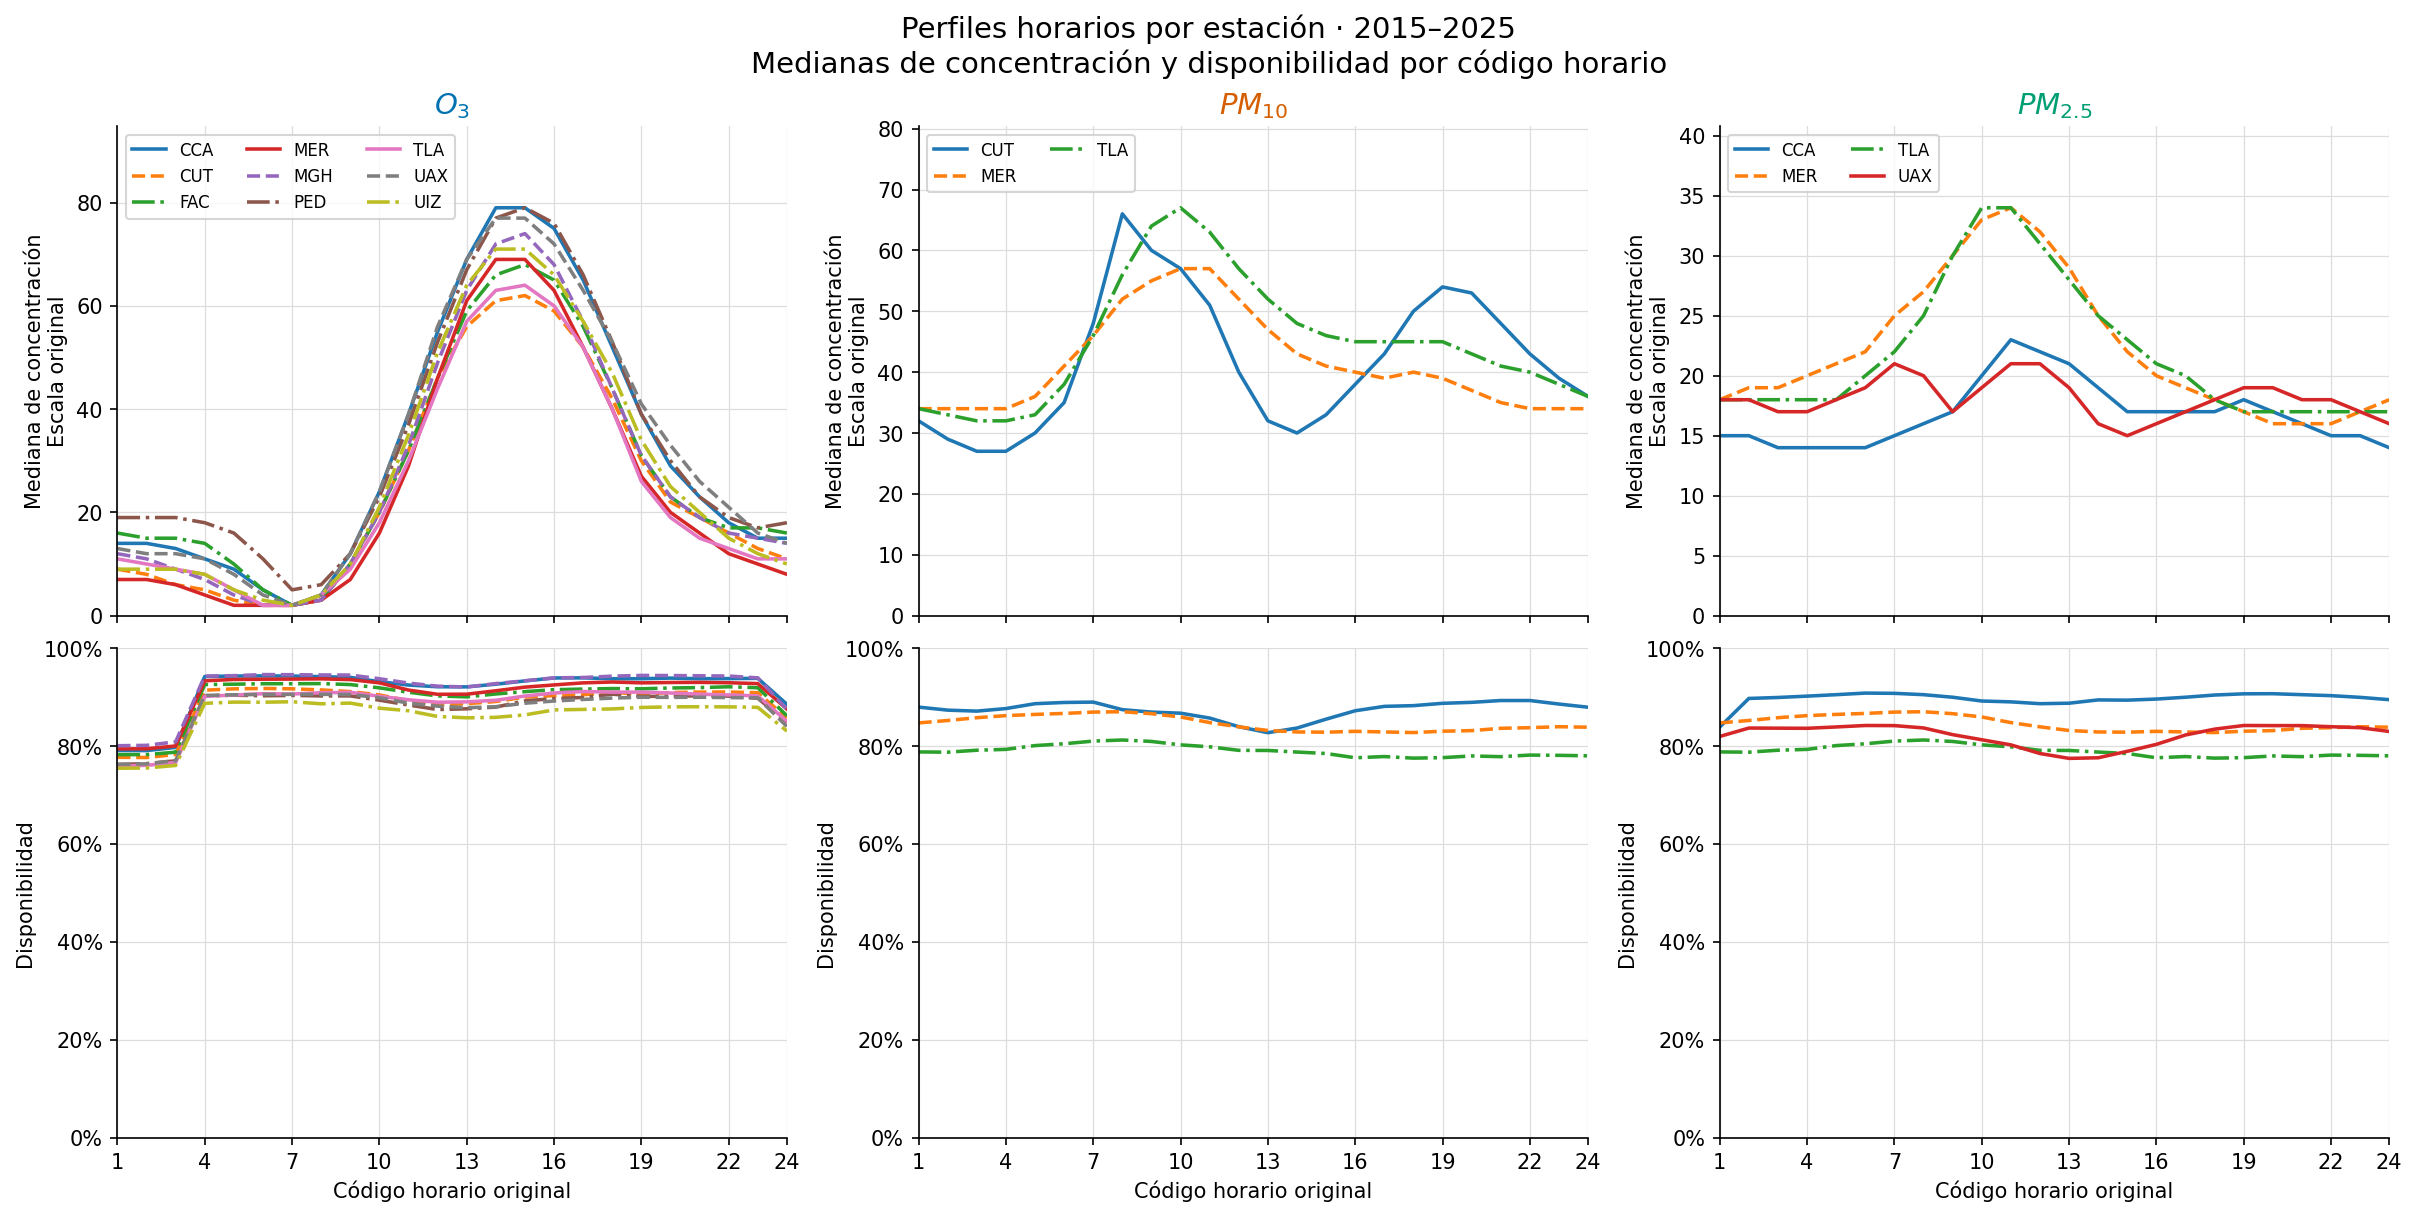


Cada estación conserva su color y estilo en ambas filas.
Las curvas reúnen observaciones de diferentes días.


In [15]:
fig_perfiles_horarios, axes = plt.subplots(
    2,
    3,
    figsize=(16, 8),
    sharex=True,
    dpi=150,
    constrained_layout=True,
)

colores_estaciones_perfil = {}
paleta_estaciones = plt.get_cmap("tab10")
estilos_linea = ["-", "--", "-."]

for columna, contaminante in enumerate(CONTAMINANTES):
    ax_concentracion = axes[0, columna]
    ax_disponibilidad = axes[1, columna]

    estaciones = REDES_SELECCIONADAS[contaminante]

    for i, estacion in enumerate(estaciones):
        datos = (
            perfil_horario_estaciones.loc[
                perfil_horario_estaciones["CONTAMINANTE"].eq(contaminante) & perfil_horario_estaciones["ESTACION"].eq(estacion)
            ]
            .sort_values("HORA_ORIGINAL")
        )

        color = paleta_estaciones(i)
        estilo = estilos_linea[i % len(estilos_linea)]

        colores_estaciones_perfil[(contaminante, estacion)] = color

        horas = datos["HORA_ORIGINAL"].to_numpy()
        medianas = datos["MEDIANA"].to_numpy(dtype=float)
        disponibilidad = datos["PCT_DISPONIBILIDAD"].to_numpy(dtype=float)

        ax_concentracion.plot(
            horas,
            medianas,
            color=color,
            linestyle=estilo,
            linewidth=1.7,
            label=estacion,
        )

        ax_disponibilidad.plot(
            horas,
            disponibilidad,
            color=color,
            linestyle=estilo,
            linewidth=1.7,
        )

    ax_concentracion.set_title(
        NOMBRES_CONTAMINANTES[contaminante],
        color=COLORES_CONTAMINANTES[contaminante],
        fontsize=14,
        fontweight="bold",
    )

    ax_concentracion.set_ylabel("Mediana de concentración\nEscala original")

    mayor_mediana = perfil_horario_estaciones.loc[
        perfil_horario_estaciones["CONTAMINANTE"].eq(contaminante),
        "MEDIANA",
    ].max()

    ax_concentracion.set_ylim(0, mayor_mediana * 1.20)

    ax_concentracion.legend(
        loc="upper left",
        ncol=3 if len(estaciones) > 5 else 2,
        fontsize=8,
        frameon=True,
    )

    ax_disponibilidad.set_ylabel("Disponibilidad")
    ax_disponibilidad.set_ylim(0, 100)
    ax_disponibilidad.set_yticks(range(0, 101, 20))
    ax_disponibilidad.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax_disponibilidad.set_xlabel("Código horario original")

    for ax in [ax_concentracion, ax_disponibilidad]:
        ax.set_xlim(1, 24)
        ax.set_xticks([1, 4, 7, 10, 13, 16, 19, 22, 24])
        ax.grid(color="#DDDDDD", linewidth=0.6)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

fig_perfiles_horarios.suptitle(
    "Perfiles horarios por estación · 2015–2025\n"
    "Medianas de concentración y disponibilidad por código horario",
    fontsize=14,)

ruta_fig_perfiles_horarios = DIR_FIGURAS_01 / "perfiles_horarios_concentracion_disponibilidad_2015_2025.png"

fig_perfiles_horarios.savefig(
    ruta_fig_perfiles_horarios,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print("\nCada estación conserva su color y estilo en ambas filas.")
print("Las curvas reúnen observaciones de diferentes días.")

### Interpretación de los perfiles horarios

La fila superior muestra las medianas de concentración por código
horario y estación. La fila inferior presenta la disponibilidad de
las mediciones utilizadas para calcular esos perfiles.

**O₃.**  
Las nueve estaciones presentan una forma similar: las medianas son
bajas alrededor del código 7, aumentan después y alcanzan su mayor
nivel en los códigos 14–15. Posteriormente disminuyen.

CCA y PED alcanzan medianas máximas de 79, mientras que CUT alcanza
62. Las diferencias de magnitud conviven con un patrón horario
compartido por la red.

La disponibilidad es menor en los códigos 1–3 y aumenta claramente
en el código 4. También se observa una disminución más moderada
alrededor de los códigos 12–14 y al final del día. La figura no
permite determinar la causa de estas variaciones.

**PM₁₀.**  
Los perfiles difieren más entre estaciones. CUT alcanza su mayor
mediana en el código 8 y presenta otro aumento alrededor de los
códigos 19–20. MER alcanza su mayor mediana en los códigos 10–11,
mientras que TLA lo hace en el código 10.

TLA presenta menor disponibilidad que CUT y MER durante todo el
perfil. En consecuencia, sus medianas se calculan con menos
observaciones, aunque esto no demuestra por sí solo un sesgo.

**PM₂.₅.**  
MER y TLA muestran perfiles cercanos, con medianas máximas de 34
en los códigos 10–11. CCA alcanza su mayor mediana, de 23, en el
código 11.

UAX presenta un perfil más irregular y de menor amplitud, con una
mediana máxima de 21 en los códigos 7, 11 y 12. Su disponibilidad
también cambia a lo largo del perfil, con una disminución alrededor
de los códigos 13–15.

**Alcance de la comparación.**  
Las curvas reúnen observaciones de 2015–2025; no representan un día
particular ni prueban que el patrón sea idéntico en todos los años.

Los paneles de concentración utilizan escalas independientes.
Los códigos horarios se conservan como aparecen en la fuente y
las unidades siguen pendientes de confirmación.

## 2.7. Distribución de las concentraciones por mes del año

Los perfiles horarios describen variaciones dentro del día.
Ahora exploraremos las diferencias entre los doce meses del año.

Para cada contaminante y estación agruparemos las mediciones horarias
según el mes de su fecha original.

Por ejemplo, el grupo de enero reunirá las observaciones horarias
de todos los eneros de 2015–2025.

### ¿Se cambia la resolución de la base?

No. Las bases seguirán siendo horarias. Esta agrupación únicamente
produce resúmenes descriptivos de las mediciones que corresponden
a cada mes del calendario.

No calcularemos primero promedios diarios ni sustituiremos las
series originales por series mensuales.

### Estadísticos por mes

Calcularemos:

- Número de horas esperadas.
- Número de mediciones disponibles.
- Porcentaje de disponibilidad.
- Media y mediana.
- Percentiles 25 y 75.
- Percentil 95.

La mediana describirá el nivel central; los percentiles 25 y 75,
la dispersión central; y el percentil 95, una referencia de las
concentraciones altas.

Los percentiles no son intervalos de confianza ni umbrales
normativos.

### Disponibilidad mensual

Los meses tienen duraciones distintas. Por ello, el denominador
de disponibilidad se calculará desde el calendario completo:

$$
\text{Disponibilidad}_{s,m}
=
100\frac{n_{s,m}}{N_m},
$$

donde:

- $n_{s,m}$ es el número de mediciones disponibles de la estación
  $s$ en el mes del calendario $m$.
- $N_m$ es el número de posiciones horarias esperadas para ese mes
  durante los once años.

En febrero se incluirán los días adicionales de los años bisiestos.

### Mes del calendario y periodo mensual

Esta sección agrupa, por ejemplo, todos los eneros en una categoría.
Es diferente de evaluar cada periodo por separado, como enero de
2015 o enero de 2025.

La agrupación ayuda a explorar un posible patrón anual, pero puede
ocultar cambios entre años. Además, las horas observadas tienen el
mismo peso: los años con más datos disponibles aportan más
observaciones al resumen.

Por ello, las diferencias entre meses se interpretarán como
descriptivas. No estableceremos todavía tendencias, causas ni
episodios extremos.

In [16]:
NOMBRES_MESES = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre",
}

registros_perfil_mensual = []

for contaminante in CONTAMINANTES:
    base = bases_horarias[contaminante]

    meses = pd.Index(base.index.month, name="MES")

    horas_esperadas_por_mes = (
        pd.Series(1, index=base.index)
        .groupby(meses)
        .sum()
        .reindex(range(1, 13))
    )

    for estacion in REDES_SELECCIONADAS[contaminante]:
        grupos = base[estacion].groupby(meses)

        conteos = grupos.count()
        medias = grupos.mean()
        medianas = grupos.median()
        p25 = grupos.quantile(0.25)
        p75 = grupos.quantile(0.75)
        p95 = grupos.quantile(0.95)

        for mes in range(1, 13):
            n_esperadas = int(horas_esperadas_por_mes.loc[mes])
            n_observadas = int(conteos.loc[mes])

            registros_perfil_mensual.append(
                {
                    "CONTAMINANTE": contaminante,
                    "ESTACION": estacion,
                    "MES": mes,
                    "NOMBRE_MES": NOMBRES_MESES[mes],
                    "N_ESPERADAS": n_esperadas,
                    "N_OBSERVADAS": n_observadas,
                    "PCT_DISPONIBILIDAD": (
                        100 * n_observadas / n_esperadas
                    ),
                    "MEDIA": medias.loc[mes],
                    "MEDIANA": medianas.loc[mes],
                    "P25": p25.loc[mes],
                    "P75": p75.loc[mes],
                    "P95": p95.loc[mes],
                }
            )

perfil_mensual_estaciones = pd.DataFrame(registros_perfil_mensual)

# Comprobar que cada medición disponible se contabilizó una sola vez.
conteos_mensuales = (
    perfil_mensual_estaciones
    .groupby(["CONTAMINANTE", "ESTACION"])["N_OBSERVADAS"]
    .sum()
)

conteos_preparacion = (
    resumen_preparacion_estaciones
    .set_index(["CONTAMINANTE", "ESTACION"])["N_OBSERVADOS"]
    .reindex(conteos_mensuales.index)
)

if not conteos_mensuales.eq(conteos_preparacion).all():
    raise ValueError("Los conteos mensuales no coinciden con las bases preparadas.")

registros_resumen_mensual = []

for (contaminante, estacion), grupo in (
    perfil_mensual_estaciones.groupby(["CONTAMINANTE", "ESTACION"])
):
    mediana_maxima = grupo["MEDIANA"].max()
    mediana_minima = grupo["MEDIANA"].min()

    meses_maximo = grupo.loc[grupo["MEDIANA"].eq(mediana_maxima), "NOMBRE_MES"].tolist()
    meses_minimo = grupo.loc[grupo["MEDIANA"].eq(mediana_minima), "NOMBRE_MES"].tolist()

    registros_resumen_mensual.append(
        {
            "CONTAMINANTE": contaminante,
            "ESTACION": estacion,
            "MESES_MEDIANA_MAXIMA": ", ".join(meses_maximo),
            "MEDIANA_MAXIMA": mediana_maxima,
            "MESES_MEDIANA_MINIMA": ", ".join(meses_minimo),
            "MEDIANA_MINIMA": mediana_minima,
            "MIN_DISPONIBILIDAD_MENSUAL_PCT": (
                grupo["PCT_DISPONIBILIDAD"].min()
            ),
            "MAX_DISPONIBILIDAD_MENSUAL_PCT": (
                grupo["PCT_DISPONIBILIDAD"].max()
            ),
        }
    )

resumen_perfil_mensual = pd.DataFrame(registros_resumen_mensual)

print("Horas esperadas por mes del calendario, 2015–2025:")
display(
    perfil_mensual_estaciones[["MES", "NOMBRE_MES", "N_ESPERADAS"]]
    .drop_duplicates()
    .sort_values("MES")
    .reset_index(drop=True)
)

print("\nResumen de los perfiles mensuales:")
with pd.option_context("display.max_columns", None,"display.precision", 2,):
    display(resumen_perfil_mensual)

print("\nMedianas por mes del calendario y estación:")

for contaminante in CONTAMINANTES:
    print(f"\n{contaminante}")

    tabla_medianas_mensuales = (
        perfil_mensual_estaciones.loc[perfil_mensual_estaciones["CONTAMINANTE"].eq(contaminante)]
        .pivot(index="MES",columns="ESTACION",values="MEDIANA",)
        .reindex(columns=REDES_SELECCIONADAS[contaminante])
    )

    tabla_medianas_mensuales.index = tabla_medianas_mensuales.index.map(NOMBRES_MESES)
    tabla_medianas_mensuales.index.name = "MES"

    with pd.option_context("display.max_columns", None,"display.precision", 2,):
        display(tabla_medianas_mensuales)

print("\nLos conteos mensuales coinciden con la preparación.")
print("Las bases mantienen su resolución horaria.")

Horas esperadas por mes del calendario, 2015–2025:


,MES,NOMBRE_MES,N_ESPERADAS
0,1,Enero,8184
1,2,Febrero,7464
2,3,Marzo,8184
3,4,Abril,7920
4,5,Mayo,8184
5,6,Junio,7920
6,7,Julio,8184
7,8,Agosto,8184
8,9,Septiembre,7920
9,10,Octubre,8184



Resumen de los perfiles mensuales:


,CONTAMINANTE,ESTACION,MESES_MEDIANA_MAXIMA,MEDIANA_MAXIMA,MESES_MEDIANA_MINIMA,MEDIANA_MINIMA,MIN_DISPONIBILIDAD_MENSUAL_PCT,MAX_DISPONIBILIDAD_MENSUAL_PCT
0,O3,CCA,"Abril, Mayo",39.0,Diciembre,16.0,85.13,96.30
1,O3,CUT,Mayo,32.0,Diciembre,12.0,75.29,96.41
2,O3,FAC,Abril,33.0,Diciembre,15.0,82.01,95.43
3,O3,MER,"Abril, Mayo",31.0,"Noviembre, Diciembre",8.0,80.51,94.27
4,O3,MGH,"Abril, Mayo",34.0,Diciembre,13.0,83.10,96.14
5,O3,PED,Abril,41.0,Noviembre,19.0,71.48,93.29
6,O3,TLA,Mayo,32.0,Diciembre,10.0,70.23,95.75
7,O3,UAX,Mayo,42.0,Noviembre,16.0,75.66,94.91
8,O3,UIZ,Mayo,36.0,Noviembre,12.0,80.08,92.07
9,PM10,CUT,Febrero,53.0,Septiembre,27.0,77.30,94.20



Medianas por mes del calendario y estación:

O3


...


PM10


ESTACION,CUT,MER,TLA
MES,,,
Enero,51.0,50.0,53.0
Febrero,53.0,50.0,53.0
Marzo,51.0,51.0,50.0
Abril,51.0,50.0,49.0
Mayo,45.0,44.0,47.0
Junio,30.0,32.0,37.0
Julio,31.0,32.0,36.0
Agosto,28.0,27.0,31.0
Septiembre,27.0,27.0,33.0



PM25


ESTACION,CCA,MER,TLA,UAX
MES,,,,
Enero,17.0,25.0,24.0,22.0
Febrero,18.0,24.0,23.0,22.0
Marzo,19.0,24.0,22.0,22.0
Abril,23.0,27.0,25.0,24.0
Mayo,22.0,27.0,26.0,23.0
Junio,14.0,17.0,19.5,15.0
Julio,13.0,18.0,18.0,15.0
Agosto,12.0,15.0,15.0,12.0
Septiembre,12.0,16.0,17.0,12.0



Los conteos mensuales coinciden con la preparación.
Las bases mantienen su resolución horaria.


## 2.8. Visualización de los perfiles por mes del año

Construiremos una figura de dos filas y tres columnas para comparar
los perfiles mensuales de las estaciones.

Cada columna corresponderá a un contaminante:

- **Fila superior:** mediana de concentración por mes del calendario.
- **Fila inferior:** disponibilidad de las mediciones utilizadas.

### Lectura de las curvas

Cada punto de concentración será la mediana de las mediciones
horarias disponibles para ese mes durante 2015–2025.

Por ejemplo, el punto de abril reunirá las mediciones de los once
abriles del periodo. La línea conectará esos resúmenes para facilitar
la lectura del patrón anual.

Esta línea no representa la evolución de un año particular ni una
serie de promedios diarios.

### Comparación entre estaciones

Dentro de cada contaminante, cada estación conservará el color
y el estilo utilizados en la figura de perfiles horarios.

Esto facilitará seguir una misma estación entre figuras y comparar:

- Los meses con mayores y menores medianas.
- Las diferencias de magnitud entre estaciones.
- La similitud de sus patrones a lo largo del calendario.
- La disponibilidad que sustenta cada resumen.

### Disponibilidad y límites

La disponibilidad se calculará respecto al número de horas esperado
para cada mes durante los once años, incluyendo los días bisiestos.

Los paneles de disponibilidad tendrán una escala común de 0 a 100%.
Los paneles de concentración utilizarán escalas independientes por
contaminante.

Los perfiles mensuales describen las observaciones disponibles.
Las diferencias de cobertura pueden modificar la composición de
años, días y códigos horarios que participa en cada punto.

Por tanto, estos resultados permiten explorar un patrón anual,
pero no atribuirlo a una causa ni afirmar que se repita con la
misma magnitud en todos los años.

Las unidades continúan pendientes de confirmación. La figura se
guardará en PNG sin modificar las bases horarias.

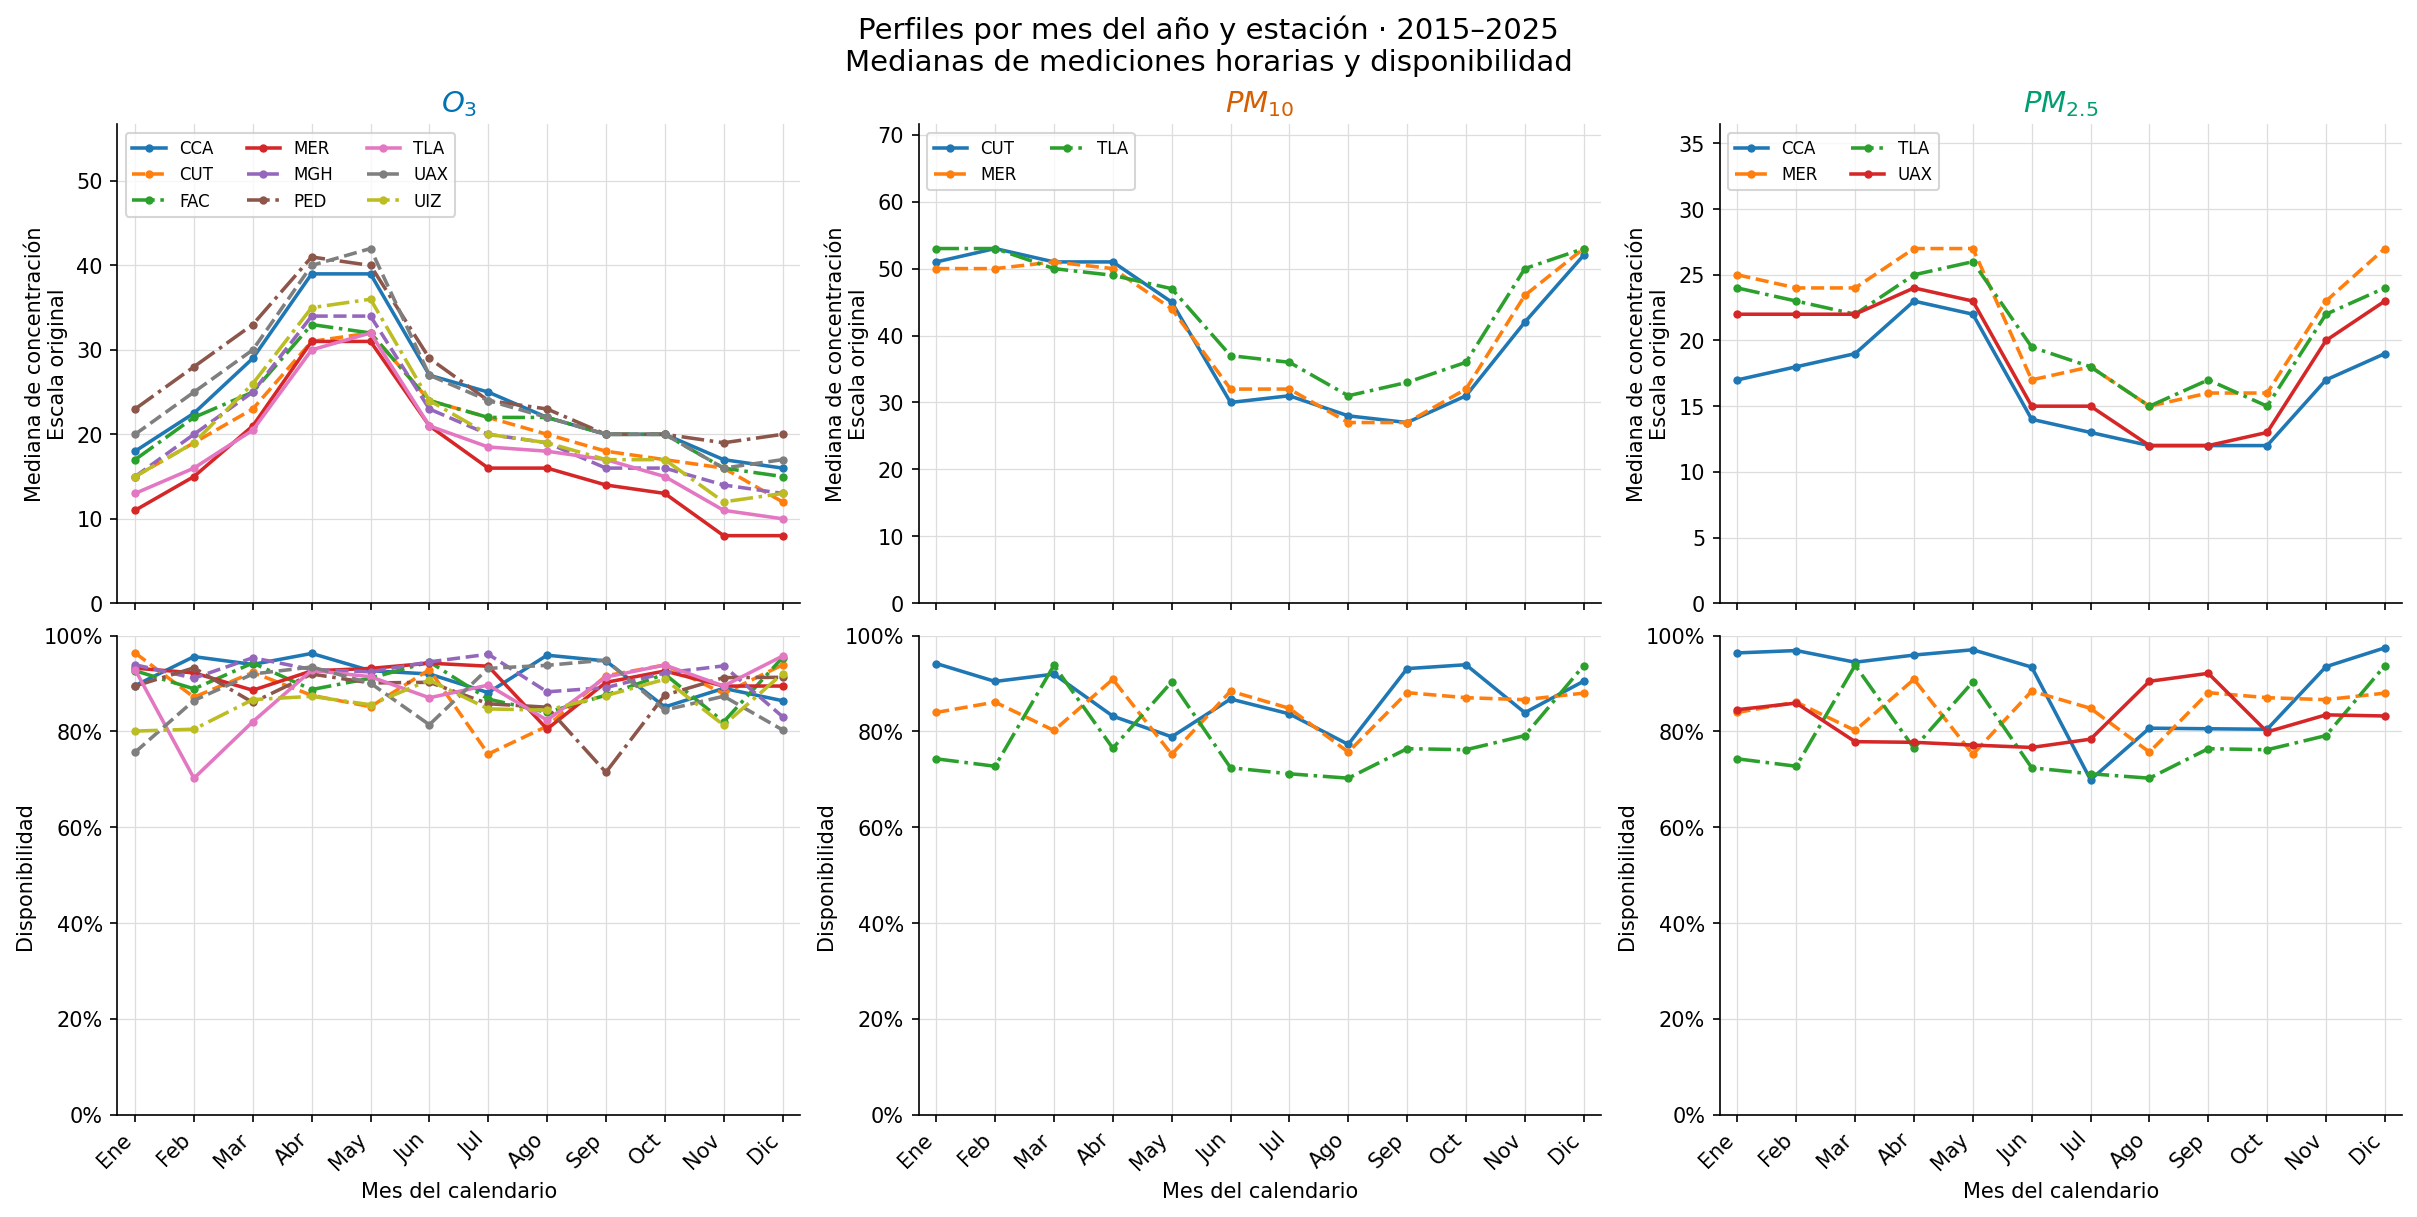


Cada mes reúne mediciones de los once años del estudio.
Las bases originales mantienen su resolución horaria.


In [17]:
ABREVIATURAS_MESES = [
    "Ene", "Feb", "Mar", "Abr", "May", "Jun",
    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic",
]

fig_perfiles_mensuales, axes = plt.subplots(
    2,
    3,
    figsize=(16, 8),
    sharex=True,
    dpi=150,
    constrained_layout=True,
)

for columna, contaminante in enumerate(CONTAMINANTES):
    ax_concentracion = axes[0, columna]
    ax_disponibilidad = axes[1, columna]

    estaciones = REDES_SELECCIONADAS[contaminante]

    for i, estacion in enumerate(estaciones):
        datos = (
            perfil_mensual_estaciones.loc[
                perfil_mensual_estaciones["CONTAMINANTE"].eq(contaminante) & perfil_mensual_estaciones["ESTACION"].eq(estacion)]
            .sort_values("MES")
        )

        color = colores_estaciones_perfil[(contaminante, estacion)]
        estilo = estilos_linea[i % len(estilos_linea)]

        meses = datos["MES"].to_numpy()
        medianas = datos["MEDIANA"].to_numpy(dtype=float)
        disponibilidad = datos["PCT_DISPONIBILIDAD"].to_numpy(dtype=float)

        ax_concentracion.plot(
            meses,
            medianas,
            color=color,
            linestyle=estilo,
            linewidth=1.7,
            marker="o",
            markersize=3,
            label=estacion,
        )

        ax_disponibilidad.plot(
            meses,
            disponibilidad,
            color=color,
            linestyle=estilo,
            linewidth=1.7,
            marker="o",
            markersize=3,
        )

    ax_concentracion.set_title(
        NOMBRES_CONTAMINANTES[contaminante],
        color=COLORES_CONTAMINANTES[contaminante],
        fontsize=14,
        fontweight="bold",
    )

    ax_concentracion.set_ylabel("Mediana de concentración\nEscala original")

    mayor_mediana = perfil_mensual_estaciones.loc[
        perfil_mensual_estaciones["CONTAMINANTE"].eq(contaminante),
        "MEDIANA",
    ].max()

    # Espacio superior para la leyenda.
    ax_concentracion.set_ylim(0, mayor_mediana * 1.35)

    ax_concentracion.legend(
        loc="upper left",
        ncol=3 if len(estaciones) > 5 else 2,
        fontsize=8,
        frameon=True,
    )

    ax_disponibilidad.set_ylabel("Disponibilidad")
    ax_disponibilidad.set_ylim(0, 100)
    ax_disponibilidad.set_yticks(range(0, 101, 20))
    ax_disponibilidad.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax_disponibilidad.set_xlabel("Mes del calendario")

    for ax in [ax_concentracion, ax_disponibilidad]:
        ax.set_xlim(0.7, 12.3)
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(ABREVIATURAS_MESES,rotation=45,ha="right",)
        ax.grid(color="#DDDDDD", linewidth=0.6)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

fig_perfiles_mensuales.suptitle(
    "Perfiles por mes del año y estación · 2015–2025\n"
    "Medianas de mediciones horarias y disponibilidad",
    fontsize=14,
)

ruta_fig_perfiles_mensuales = DIR_FIGURAS_01 / "perfiles_mensuales_concentracion_disponibilidad_2015_2025.png"


fig_perfiles_mensuales.savefig(
    ruta_fig_perfiles_mensuales,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print("\nCada mes reúne mediciones de los once años del estudio.")
print("Las bases originales mantienen su resolución horaria.")

La fila superior presenta las medianas de las concentraciones horarias,
agrupadas por mes del calendario durante 2015–2025. La fila inferior
muestra la disponibilidad de las mediciones utilizadas.

**O₃.**  
Las nueve estaciones comparten un patrón: las medianas aumentan desde
enero hasta abril–mayo y disminuyen después. PED alcanza su mayor mediana
en abril, con 41, y UAX en mayo, con 42.

Aunque las magnitudes difieren entre estaciones, los meses con mayores
medianas son similares. MER presenta los valores centrales más bajos
al final del año, con una mediana de 8 en noviembre y diciembre.

La disponibilidad varía entre estaciones y meses. Se observan descensos
particulares, como TLA en febrero y PED en septiembre. Estos cambios
indican que la composición de las observaciones no es uniforme.

**PM₁₀.**  
Las tres estaciones presentan medianas relativamente altas entre enero
y abril, menores entre junio y octubre, y un aumento en noviembre
y diciembre.

CUT y MER alcanzan sus medianas mínimas en septiembre, con 27;
MER también registra ese valor en agosto. TLA alcanza su mínimo
en agosto, con 31.

La disponibilidad es variable. TLA presenta menor cobertura en varios
meses, especialmente entre junio y agosto, pero no es la estación
con menor cobertura en todos los meses.

**PM₂.₅.**  
Las medianas aumentan en abril–mayo, descienden después y vuelven
a aumentar hacia el final del año. MER alcanza una mediana de 27
en abril, mayo y diciembre.

CCA presenta medianas menores que MER y TLA durante el perfil.
CCA y UAX alcanzan valores de 12 en agosto y septiembre.

La disponibilidad también cambia según el mes. Destaca la reducción
de CCA en julio, cercana al 70%, frente a valores superiores al 90%
en varios otros meses.

**Alcance de los resultados.**  
La figura describe un patrón agregado de los once años. No demuestra
que todos los años presenten la misma forma ni permite atribuir las
diferencias a una causa específica.

Las medianas se calculan con las mediciones disponibles, cuya composición
puede cambiar entre meses. Las unidades siguen pendientes de confirmación
y las escalas de concentración son independientes por contaminante.

## 2.9. Comparación de las concentraciones entre años

Los perfiles anteriores reunieron las observaciones de 2015–2025.
Ahora separaremos los años para examinar las diferencias que pueden
quedar ocultas en los resúmenes del periodo completo.

Para cada combinación de contaminante, estación y año calcularemos:

- Número de horas esperadas y mediciones disponibles.
- Porcentaje de disponibilidad.
- Media y mediana.
- Percentiles 25 y 75.
- Percentil 95.
- Máximo observado.

Obtendremos 176 combinaciones:

$$
(9+3+4)\ \text{estaciones por contaminante}
\times 11\ \text{años}
=176.
$$

### Disponibilidad anual

El denominador será el número de horas del calendario de cada año:

- 8,760 horas en años comunes.
- 8,784 horas en años bisiestos.

Las dos filas ausentes de 2024 permanecerán en el denominador y
no se contarán como mediciones disponibles.

### Nivel central y concentraciones altas

La mediana describirá el centro de la distribución anual, mientras
que el percentil 95 permitirá examinar su parte alta.

El máximo se conservará como referencia de un extremo particular.
Una diferencia en el máximo puede depender de pocas observaciones;
por ello, no se interpretará de la misma manera que una diferencia
en la mediana.

### Comparación descriptiva, no prueba de tendencia

Una secuencia de medianas anuales puede mostrar aumentos o disminuciones,
pero esta tabla no constituye una prueba estadística de tendencia.

Las diferencias pueden estar relacionadas con cambios de concentración,
de cobertura o de la composición de meses y horas observadas.
No atribuiremos causas a partir de estos resúmenes.

Además, estos resultados se utilizarán para explorar y documentar
la base. No se usarán automáticamente para ajustar umbrales o
transformaciones de futuros modelos: esas decisiones deberán respetar
la separación temporal entre entrenamiento y evaluación.

In [18]:
registros_descriptivos_anuales = []

for contaminante in CONTAMINANTES:
    base = bases_horarias[contaminante]

    for anio in ANIOS_ESTUDIO:
        base_anual = base.loc[base.index.year == anio]
        n_esperadas = len(base_anual)

        for estacion in REDES_SELECCIONADAS[contaminante]:
            observados = base_anual[estacion].dropna()

            percentiles = observados.quantile(
                [0.25, 0.50, 0.75, 0.95]
            )

            registros_descriptivos_anuales.append(
                {
                    "CONTAMINANTE": contaminante,
                    "ESTACION": estacion,
                    "ANIO": anio,
                    "N_ESPERADAS": n_esperadas,
                    "N_OBSERVADAS": len(observados),
                    "PCT_DISPONIBILIDAD": (
                        100 * len(observados) / n_esperadas
                    ),
                    "MEDIA": observados.mean(),
                    "MEDIANA": percentiles.loc[0.50],
                    "P25": percentiles.loc[0.25],
                    "P75": percentiles.loc[0.75],
                    "P95": percentiles.loc[0.95],
                    "MAXIMO": observados.max(),
                }
            )

descriptivos_anuales_estaciones = pd.DataFrame(registros_descriptivos_anuales)

# Contrastar cada conteo anual con la auditoría de los archivos.
verificacion_conteos_anuales = (
    descriptivos_anuales_estaciones[["CONTAMINANTE", "ESTACION", "ANIO", "N_OBSERVADAS"]]
    .merge(
        auditoria_valores_01[["CONTAMINANTE","ESTACION","ANIO","N_NUMERICOS_DISPONIBLES",]],
        on=["CONTAMINANTE", "ESTACION", "ANIO"],
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
)

conteos_correctos = (
    verificacion_conteos_anuales["_merge"].eq("both")
    & verificacion_conteos_anuales["N_OBSERVADAS"].eq(verificacion_conteos_anuales["N_NUMERICOS_DISPONIBLES"])
)

if not conteos_correctos.all():
    print(verificacion_conteos_anuales.loc[~conteos_correctos])
    raise ValueError("Los conteos anuales no coinciden con la auditoría original.")

print("Combinaciones de contaminante, estación y año:",len(descriptivos_anuales_estaciones),)

for contaminante in CONTAMINANTES:
    datos = descriptivos_anuales_estaciones.loc[
        descriptivos_anuales_estaciones["CONTAMINANTE"].eq(contaminante)
    ]

    print(f"\n{contaminante}: medianas anuales")
    with pd.option_context(
        "display.max_columns", None,
        "display.precision", 2,
    ):
        display(
            datos.pivot(index="ANIO",columns="ESTACION",values="MEDIANA",).reindex(columns=REDES_SELECCIONADAS[contaminante])
        )

    print(f"\n{contaminante}: percentiles 95 anuales")
    with pd.option_context(
        "display.max_columns", None,
        "display.precision", 2,
    ):
        display(
            datos.pivot(index="ANIO",columns="ESTACION",values="P95",
            ).reindex(columns=REDES_SELECCIONADAS[contaminante])
        )

    print(f"\n{contaminante}: disponibilidad anual (%)")
    with pd.option_context("display.max_columns", None,"display.precision", 2,):
        display(
            datos.pivot(index="ANIO",columns="ESTACION",values="PCT_DISPONIBILIDAD",
            ).reindex(columns=REDES_SELECCIONADAS[contaminante])
        )

print("\nTodos los conteos anuales coinciden con la auditoría.")
print("Concentraciones en la escala original de los archivos.")

Combinaciones de contaminante, estación y año: 176

O3: medianas anuales


ESTACION,CCA,CUT,FAC,MER,MGH,PED,TLA,UAX,UIZ
ANIO,,,,,,,,,
2015,18.0,18.0,21.0,13.0,16.0,22.0,14.0,21.0,18.0
2016,22.0,16.0,22.0,15.0,18.0,24.0,16.0,23.0,19.0
2017,24.0,20.0,22.0,16.0,19.0,26.0,17.0,25.0,21.0
2018,22.0,22.0,21.0,18.0,19.0,26.0,16.0,23.0,17.0
2019,25.0,20.0,24.0,19.0,21.0,29.0,19.0,25.0,19.0
2020,28.0,19.0,22.0,21.0,25.0,29.0,19.0,29.0,25.0
2021,26.0,18.0,23.0,16.0,21.0,25.0,18.0,24.0,21.0
2022,26.0,19.0,20.0,17.0,20.0,26.0,19.0,27.0,22.0
2023,25.0,21.0,22.0,15.0,22.0,26.0,19.0,27.0,23.0



O3: percentiles 95 anuales


ESTACION,CCA,CUT,FAC,MER,MGH,PED,TLA,UAX,UIZ
ANIO,,,,,,,,,
2015,90.0,60.0,82.0,80.0,84.0,94.90,76.0,92.0,86.0
2016,96.0,57.0,83.0,80.0,86.0,97.00,77.0,94.0,81.0
2017,96.0,79.0,83.0,77.0,83.0,95.00,75.0,93.0,89.0
2018,93.0,77.0,81.0,85.0,85.0,94.00,72.0,88.0,71.0
2019,87.0,78.0,82.0,85.0,79.0,95.00,73.0,86.0,78.0
2020,92.0,73.0,75.0,84.0,88.0,91.00,71.0,90.0,88.0
2021,94.0,77.0,81.0,82.0,89.0,88.00,75.0,83.0,86.0
2022,97.0,77.0,73.0,82.0,86.0,92.00,78.0,93.0,87.0
2023,92.0,75.0,83.0,79.0,89.0,91.15,83.0,94.0,90.0



O3: disponibilidad anual (%)


...


PM25: percentiles 95 anuales


ESTACION,CCA,MER,TLA,UAX
ANIO,,,,
2015,37.0,60.00,60.0,40.0
2016,36.0,60.00,56.0,45.0
2017,42.0,55.00,53.0,48.0
2018,41.0,54.55,52.0,46.0
2019,43.0,49.00,51.0,47.0
2020,34.0,45.00,45.0,37.0
2021,37.0,47.00,44.0,43.0
2022,40.0,46.00,44.0,37.0
2023,33.0,42.00,44.0,38.0



PM25: disponibilidad anual (%)


ESTACION,CCA,MER,TLA,UAX
ANIO,,,,
2015,92.04,94.78,69.49,94.18
2016,97.78,83.17,88.14,92.94
2017,84.74,73.47,82.01,84.00
2018,77.34,71.58,82.99,86.34
2019,88.82,90.57,78.20,63.77
2020,86.09,78.11,76.61,95.21
2021,89.20,97.04,87.43,90.92
2022,95.26,87.91,84.75,92.39
2023,90.48,82.67,75.99,77.08



Todos los conteos anuales coinciden con la auditoría.
Concentraciones en la escala original de los archivos.


## 2.10. Visualización de las diferencias entre años

Construiremos una figura de tres filas y tres columnas.
Cada columna corresponderá a un contaminante.

Las filas mostrarán:

1. Mediana anual de concentración.
2. Percentil 95 anual.
3. Disponibilidad anual de las mediciones.

### ¿Por qué separar la mediana y el percentil 95?

La mediana describe el centro de la distribución anual.
El percentil 95 describe una posición de su parte alta.

Ambos pueden cambiar de manera diferente. Por ejemplo, una estación
puede conservar una mediana semejante y registrar cambios en sus
concentraciones altas.

El percentil 95 no es el máximo ni constituye por sí solo un umbral
para definir episodios extremos.

### Lectura de las líneas

Cada línea representará una estación. Sus colores y estilos se
mantendrán respecto a las figuras anteriores.

Los puntos corresponderán a resúmenes anuales. Las líneas únicamente
facilitarán seguir sus diferencias entre años; no representan una
evolución continua de las concentraciones.

No se ajustará una recta de tendencia ni se realizará una prueba
estadística en esta celda.

### Cobertura e interpretación

La tercera fila permitirá examinar cuánta información sustenta cada
resumen anual.

Una cobertura baja puede dejar fuera meses o códigos horarios de
forma desigual. Por ello, una diferencia entre años no debe
interpretarse automáticamente como un cambio en la concentración
de todo el año.

En particular, revisaremos visualmente la menor cobertura de algunas
estaciones en 2024, sin eliminar ese año ni imputar sus mediciones.

Los paneles de concentración tendrán escalas independientes.
Los de disponibilidad compartirán una escala de 0 a 100%.

Esta comparación es descriptiva. No establece causas ni confirma
una tendencia temporal, y las unidades permanecen pendientes de
verificación documental.

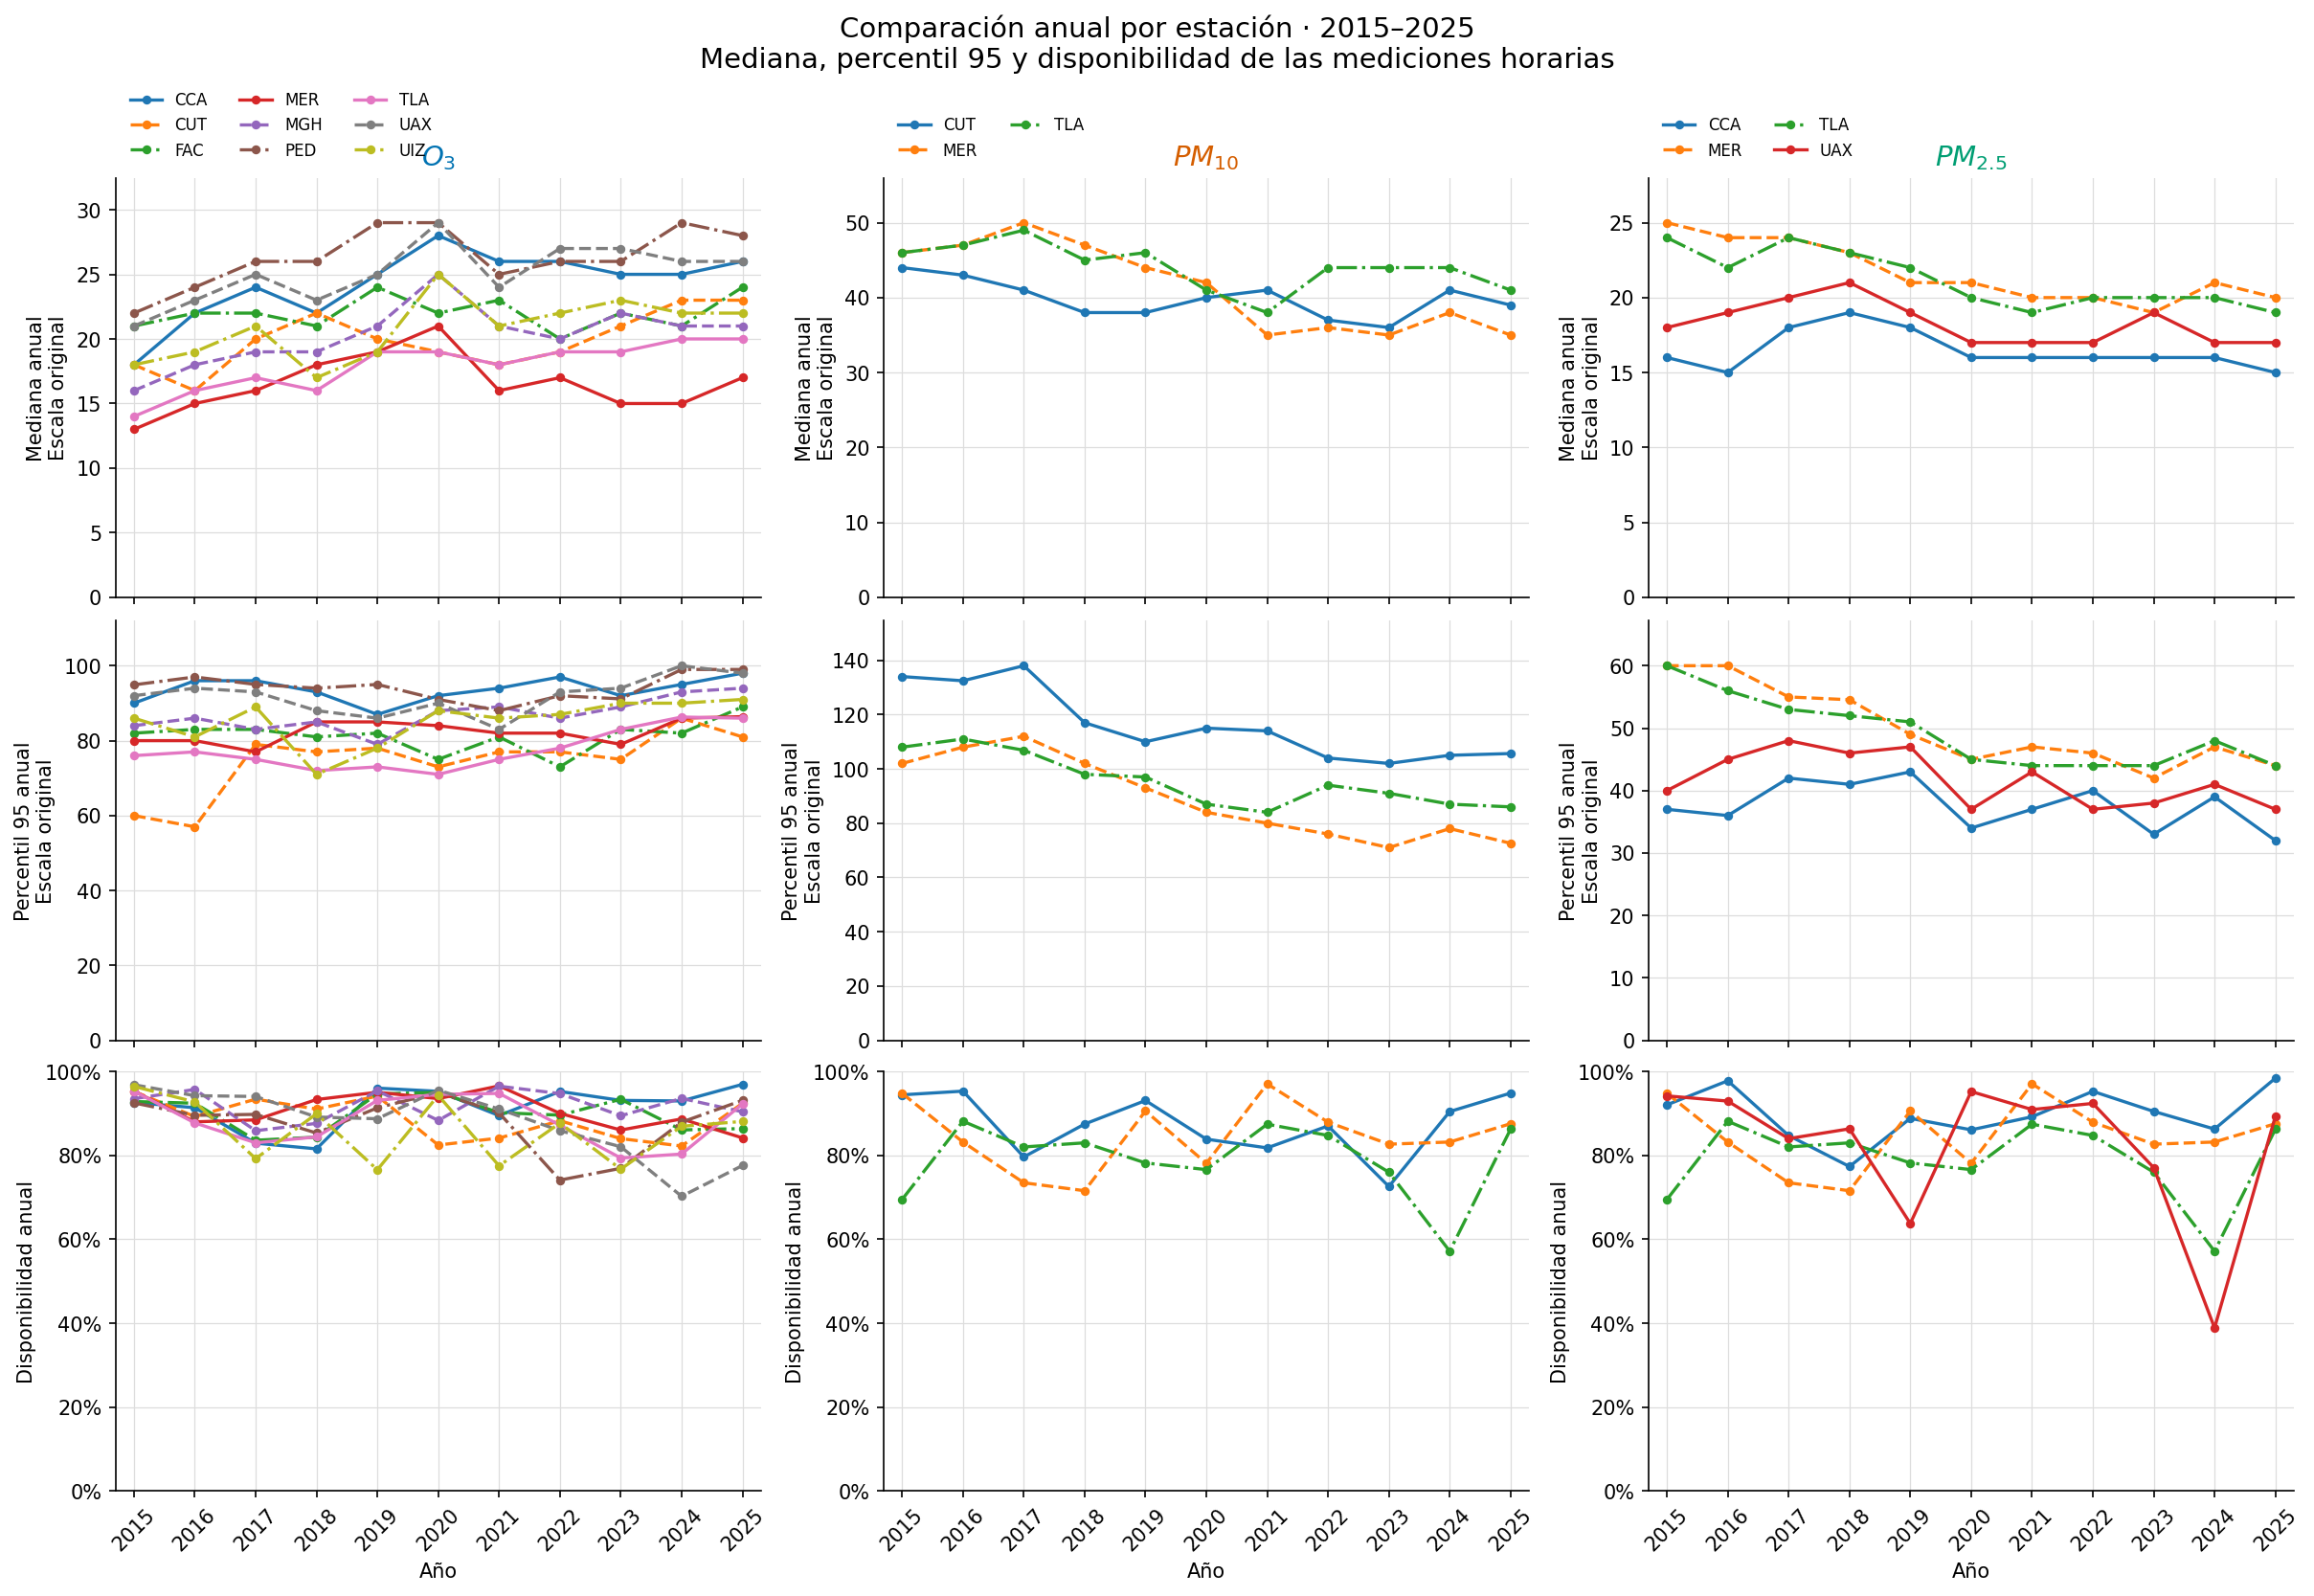


Comparación descriptiva; no se ajustaron tendencias.
No se eliminaron años ni se imputaron mediciones.


In [19]:
fig_comparacion_anual, axes = plt.subplots(
    3,
    3,
    figsize=(16, 11),
    sharex=True,
    dpi=150,
    constrained_layout=True,
)

indicadores_figura_anual = [
    ("MEDIANA", "Mediana anual\nEscala original"),
    ("P95", "Percentil 95 anual\nEscala original"),
    ("PCT_DISPONIBILIDAD", "Disponibilidad anual"),
]

for columna, contaminante in enumerate(CONTAMINANTES):
    estaciones = REDES_SELECCIONADAS[contaminante]

    datos_contaminante = descriptivos_anuales_estaciones.loc[
        descriptivos_anuales_estaciones["CONTAMINANTE"].eq(contaminante)
    ]

    for i, estacion in enumerate(estaciones):
        datos = (
            datos_contaminante.loc[datos_contaminante["ESTACION"].eq(estacion)]
            .sort_values("ANIO")
        )

        color = colores_estaciones_perfil[(contaminante, estacion)]
        estilo = estilos_linea[i % len(estilos_linea)]

        for fila, (indicador, _) in enumerate(indicadores_figura_anual):
            axes[fila, columna].plot(
                datos["ANIO"].to_numpy(),
                datos[indicador].to_numpy(dtype=float),
                color=color,
                linestyle=estilo,
                linewidth=1.6,
                marker="o",
                markersize=3.5,
                label=estacion,
            )

    axes[0, columna].set_title(
        NOMBRES_CONTAMINANTES[contaminante],
        color=COLORES_CONTAMINANTES[contaminante],
        fontsize=14,
        fontweight="bold",
    )

    # Colocar la leyenda fuera del área de las curvas.
    axes[0, columna].legend(
        loc="lower left",
        bbox_to_anchor=(0, 1.01),
        ncol=3 if len(estaciones) > 5 else 2,
        fontsize=8,
        frameon=False,
    )

    for fila, (indicador, etiqueta) in enumerate(indicadores_figura_anual):
        ax = axes[fila, columna]
        ax.set_ylabel(etiqueta)

        if indicador == "PCT_DISPONIBILIDAD":
            ax.set_ylim(0, 100)
            ax.set_yticks(range(0, 101, 20))
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
        else:
            mayor_valor = datos_contaminante[indicador].max()
            ax.set_ylim(0, mayor_valor * 1.12)

        ax.set_xlim(ANIOS_ESTUDIO[0] - 0.3,ANIOS_ESTUDIO[-1] + 0.3,)
        ax.set_xticks(ANIOS_ESTUDIO)
        ax.tick_params(axis="x", labelrotation=45)
        ax.grid(color="#DDDDDD", linewidth=0.6)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[2, columna].set_xlabel("Año")

fig_comparacion_anual.suptitle(
    "Comparación anual por estación · 2015–2025\n"
    "Mediana, percentil 95 y disponibilidad de las mediciones horarias",
    fontsize=14,
)

ruta_fig_comparacion_anual = DIR_FIGURAS_01 / "comparacion_anual_concentracion_disponibilidad_2015_2025.png"


fig_comparacion_anual.savefig(
    ruta_fig_comparacion_anual,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print("\nComparación descriptiva; no se ajustaron tendencias.")
print("No se eliminaron años ni se imputaron mediciones.")



Las columnas corresponden a O₃, PM₁₀ y PM₂.₅. Las filas muestran,
respectivamente, la mediana anual, el percentil 95 y la disponibilidad
de las mediciones.

**O₃.**  
Varias estaciones presentan medianas mayores en los últimos años
que en 2015, aunque los cambios no son uniformes ni estrictamente
crecientes. PED se mantiene entre las estaciones con mayor mediana;
MER presenta valores centrales menores durante todo el periodo.

Los percentiles 95 no siguen exactamente el comportamiento de las
medianas. En varias estaciones aumentan en 2024–2025, mientras que
otras muestran fluctuaciones durante el periodo.

**PM₁₀.**  
Las medianas de MER y TLA son menores en 2025 que al inicio del periodo.
CUT también presenta una mediana menor, pero con aumentos y descensos
intermedios.

Los percentiles 95 muestran una reducción más marcada entre los
primeros años y los recientes. Por ejemplo, MER pasa de 102 en 2015
a 72.6 en 2025. Esta diferencia describe las observaciones disponibles;
todavía no constituye una prueba de tendencia.

**PM₂.₅.**  
MER y TLA presentan medianas y percentiles 95 menores en los años
recientes que en 2015. CCA y UAX muestran fluctuaciones y diferencias
menos uniformes.

Estos resultados indican que el centro y la parte alta de las
distribuciones pueden cambiar de manera distinta entre estaciones.

**Disponibilidad.**  
La cobertura varía entre estaciones y años. Destacan en 2024
la disponibilidad de TLA, de 57.16% para ambas partículas,
y la de UAX, de 38.88% para PM₂.₅.

Los resúmenes de esos casos se calculan con una fracción menor
del calendario anual. Si las ausencias se concentran en determinados
meses u horas, pueden afectar la comparación con otros años.

**Alcance de la figura.**  
Las líneas conectan resúmenes anuales y no representan mediciones
continuas. La figura no establece causas ni confirma tendencias
estadísticas. Las concentraciones se conservan en la escala original,
con unidades pendientes de confirmación.

## 3. Comparación entre estaciones en horas compartidas

Las estaciones tienen diferentes patrones de valores faltantes.
Por ello, comparar sus estadísticas calculadas por separado puede
mezclar diferencias espaciales con diferencias en los periodos observados.

Para reducir ese problema, cada comparación utilizará únicamente
las horas en que ambas estaciones tengan una medición disponible.

## 3.1. Asociación y diferencias entre pares de estaciones

Para cada par del mismo contaminante calcularemos:

- Número y porcentaje de horas compartidas.
- Correlación de Pearson.
- Correlación de Spearman.
- Mediana de cada estación en esas horas.
- Mediana de las diferencias horarias entre ambas estaciones.

### Horas compartidas

Para las estaciones A y B utilizaremos:

$$
T_{AB}
=
\{t:X_{A,t}\text{ y }X_{B,t}\text{ están disponibles}\}.
$$

El porcentaje de horas compartidas tendrá como denominador
las 96,432 horas del calendario completo.

Cada par puede tener un conjunto de horas diferente. Por tanto,
las comparaciones entre pares no necesariamente utilizan las mismas
fechas.

### Correlación de Pearson

Mide la asociación lineal entre las concentraciones de ambas estaciones.

Una correlación positiva alta indica que, en las horas compartidas,
los valores tienden a aumentar y disminuir conjuntamente.

No implica que las concentraciones sean iguales. Dos estaciones
pueden tener una asociación alta y niveles sistemáticamente distintos.

### Correlación de Spearman

Calcula la asociación entre los rangos de los valores y describe
una relación monótona, que no tiene que ser lineal.

Compararla con Pearson ayuda a examinar si la asociación cambia
al considerar el orden de los valores en lugar de sus magnitudes.
Los valores repetidos reciben rangos promedio.

### Diferencias de concentración

Para cada hora compartida calcularemos:

$$
D_t=X_{B,t}-X_{A,t}.
$$

Una mediana de diferencias positiva indica que B registra valores
mayores que A en términos de la diferencia horaria central.
Una mediana negativa indica lo contrario.

La mediana de las diferencias no es necesariamente igual a la
diferencia entre las dos medianas.

### Límites de interpretación

Las correlaciones describen asociaciones sobre las observaciones
compartidas. Pueden reflejar patrones horarios y anuales comunes;
no demuestran causalidad ni equivalencia entre estaciones.

No calcularemos pruebas de significación tratando las horas como
observaciones independientes, porque las series pueden presentar
dependencia temporal.

Esta revisión tampoco establece que una estación pueda sustituir
a otra ni define reglas de imputación.

In [20]:
from itertools import combinations


registros_comparacion_pares = []

for contaminante in CONTAMINANTES:
    base = bases_horarias[contaminante]
    estaciones = REDES_SELECCIONADAS[contaminante]

    for estacion_a, estacion_b in combinations(estaciones, 2):
        compartidos = base[[estacion_a, estacion_b]].dropna()

        valores_a = compartidos[estacion_a]
        valores_b = compartidos[estacion_b]

        n_compartidas = len(compartidos)

        # La correlación requiere variación en ambas series.
        correlacion_definida = (
            n_compartidas >= 2
            and valores_a.nunique() > 1
            and valores_b.nunique() > 1
        )

        if correlacion_definida:
            pearson = valores_a.corr(valores_b)

            # Spearman equivale a Pearson sobre los rangos.
            spearman = valores_a.rank(method="average").corr(valores_b.rank(method="average"))
            
        else:
            pearson = np.nan
            spearman = np.nan

        diferencias = valores_b - valores_a

        registros_comparacion_pares.append(
            {
                "CONTAMINANTE": contaminante,
                "ESTACION_A": estacion_a,
                "ESTACION_B": estacion_b,
                "N_HORAS_COMPARTIDAS": n_compartidas,
                "PCT_HORAS_COMPARTIDAS": 100 * n_compartidas / len(base),
                "PEARSON": pearson,
                "SPEARMAN": spearman,
                "MEDIANA_A_COMPARTIDA": valores_a.median(),
                "MEDIANA_B_COMPARTIDA": valores_b.median(),
                "MEDIANA_DIFERENCIA_B_MENOS_A": diferencias.median(),
            }
        )

comparacion_pares_estaciones = pd.DataFrame(registros_comparacion_pares)

print("Comparaciones entre pares del mismo contaminante:")
print("Las diferencias se expresan como estación B menos estación A.")

for contaminante in CONTAMINANTES:
    print(f"\n{contaminante}")

    datos = comparacion_pares_estaciones.loc[comparacion_pares_estaciones["CONTAMINANTE"].eq(contaminante)]

    with pd.option_context("display.max_columns", None,"display.precision", 3,):
        display(
            datos.sort_values(
                ["SPEARMAN", "ESTACION_A", "ESTACION_B"],
                ascending=[False, True, True],
            ).reset_index(drop=True)
        )

print(
    "\nNúmero total de pares comparados:",
    len(comparacion_pares_estaciones),
)
print("Cada par utiliza únicamente sus horas compartidas.")
print("No se imputaron mediciones ni se calcularon pruebas de significación.")

Comparaciones entre pares del mismo contaminante:
Las diferencias se expresan como estación B menos estación A.

O3


,CONTAMINANTE,ESTACION_A,ESTACION_B,N_HORAS_COMPARTIDAS,PCT_HORAS_COMPARTIDAS,PEARSON,SPEARMAN,MEDIANA_A_COMPARTIDA,MEDIANA_B_COMPARTIDA,MEDIANA_DIFERENCIA_B_MENOS_A
0,O3,UAX,UIZ,74665,77.428,0.960,0.950,25.0,21.0,-2.0
1,O3,CCA,PED,79173,82.102,0.969,0.942,24.0,26.0,1.0
2,O3,CCA,MGH,83137,86.213,0.955,0.934,24.0,20.0,-3.0
3,O3,MER,UIZ,77212,80.069,0.948,0.930,16.0,21.0,2.0
4,O3,MER,MGH,82262,85.306,0.954,0.923,16.0,20.0,2.0
5,O3,CCA,UAX,79355,82.291,0.951,0.923,24.0,25.0,0.0
6,O3,FAC,TLA,78367,81.267,0.952,0.923,22.0,18.0,-2.0
7,O3,MGH,TLA,79902,82.858,0.943,0.922,20.0,18.0,-1.0
8,O3,MER,TLA,79319,82.254,0.937,0.921,16.0,18.0,1.0
9,O3,MER,UAX,78549,81.455,0.929,0.919,16.0,25.0,5.0



PM10


,CONTAMINANTE,ESTACION_A,ESTACION_B,N_HORAS_COMPARTIDAS,PCT_HORAS_COMPARTIDAS,PEARSON,SPEARMAN,MEDIANA_A_COMPARTIDA,MEDIANA_B_COMPARTIDA,MEDIANA_DIFERENCIA_B_MENOS_A
0,PM10,MER,TLA,64331,66.711,0.666,0.676,42.0,44.0,3.0
1,PM10,CUT,TLA,67176,69.662,0.569,0.582,41.0,44.0,3.0
2,PM10,CUT,MER,71998,74.662,0.525,0.535,40.0,41.0,0.0



PM25


,CONTAMINANTE,ESTACION_A,ESTACION_B,N_HORAS_COMPARTIDAS,PCT_HORAS_COMPARTIDAS,PEARSON,SPEARMAN,MEDIANA_A_COMPARTIDA,MEDIANA_B_COMPARTIDA,MEDIANA_DIFERENCIA_B_MENOS_A
0,PM25,CCA,UAX,71236,73.872,0.719,0.698,17.0,19.0,2.0
1,PM25,MER,TLA,64331,66.711,0.640,0.623,22.0,21.0,0.0
2,PM25,CCA,MER,73924,76.659,0.635,0.617,17.0,22.0,5.0
3,PM25,MER,UAX,66825,69.298,0.605,0.583,22.0,18.0,-3.0
4,PM25,CCA,TLA,69432,72.001,0.565,0.559,17.0,21.0,4.0
5,PM25,TLA,UAX,64175,66.549,0.449,0.448,21.0,19.0,-2.0



Número total de pares comparados: 45
Cada par utiliza únicamente sus horas compartidas.
No se imputaron mediciones ni se calcularon pruebas de significación.


## 3.2. Matrices de asociación y horas compartidas

Construiremos una figura con dos filas y tres columnas:

- **Fila superior:** correlación de Spearman entre estaciones.
- **Fila inferior:** porcentaje de horas con mediciones disponibles
  simultáneamente en cada par.

Cada columna corresponderá a un contaminante.

### Lectura de las matrices

Las filas y columnas identificarán estaciones. Cada celda fuera de
la diagonal corresponderá a la comparación entre dos estaciones.

Las matrices serán simétricas: comparar A con B produce la misma
correlación y el mismo número de horas compartidas que comparar B con A.

En la diagonal:

- La correlación de una estación consigo misma será 1.
- La disponibilidad corresponderá al porcentaje de horas con medición
  de esa estación.

La diagonal de disponibilidad no representa la cobertura de toda
la red, sino la cobertura individual.

### Asociación y cantidad de información

Mostrar ambas matrices permite examinar conjuntamente la asociación
y la cantidad de horas que la sustenta.

Una correlación calculada con 80% del calendario y otra calculada
con 67% no utilizan necesariamente los mismos periodos. Los conteos
exactos permanecerán disponibles en la tabla de pares.

### Escalas comunes

La correlación utilizará una escala de −1 a 1:

- Valores positivos indican asociación en el mismo sentido.
- Valores negativos indican asociación en sentido contrario.
- Valores cercanos a cero indican poca asociación entre los rangos.

La disponibilidad utilizará una escala de 0 a 100%.

Las escalas serán comunes entre contaminantes para evitar que
diferencias pequeñas parezcan grandes por cambios en los límites
de color.

Los valores escritos en las celdas permitirán comparar los resultados
con precisión aun cuando los colores sean parecidos.

### Límites de interpretación

Las matrices describen las concentraciones originales durante
2015–2025, sin eliminar sus patrones horarios o anuales.

Por ello, una asociación alta no demuestra que las estaciones tengan
concentraciones equivalentes, respondan igual durante los extremos
o puedan sustituirse entre sí.

Además, cada par utiliza sus propias horas compartidas. Esta figura
es un resumen descriptivo y no establece un modelo conjunto de
dependencia espacial.

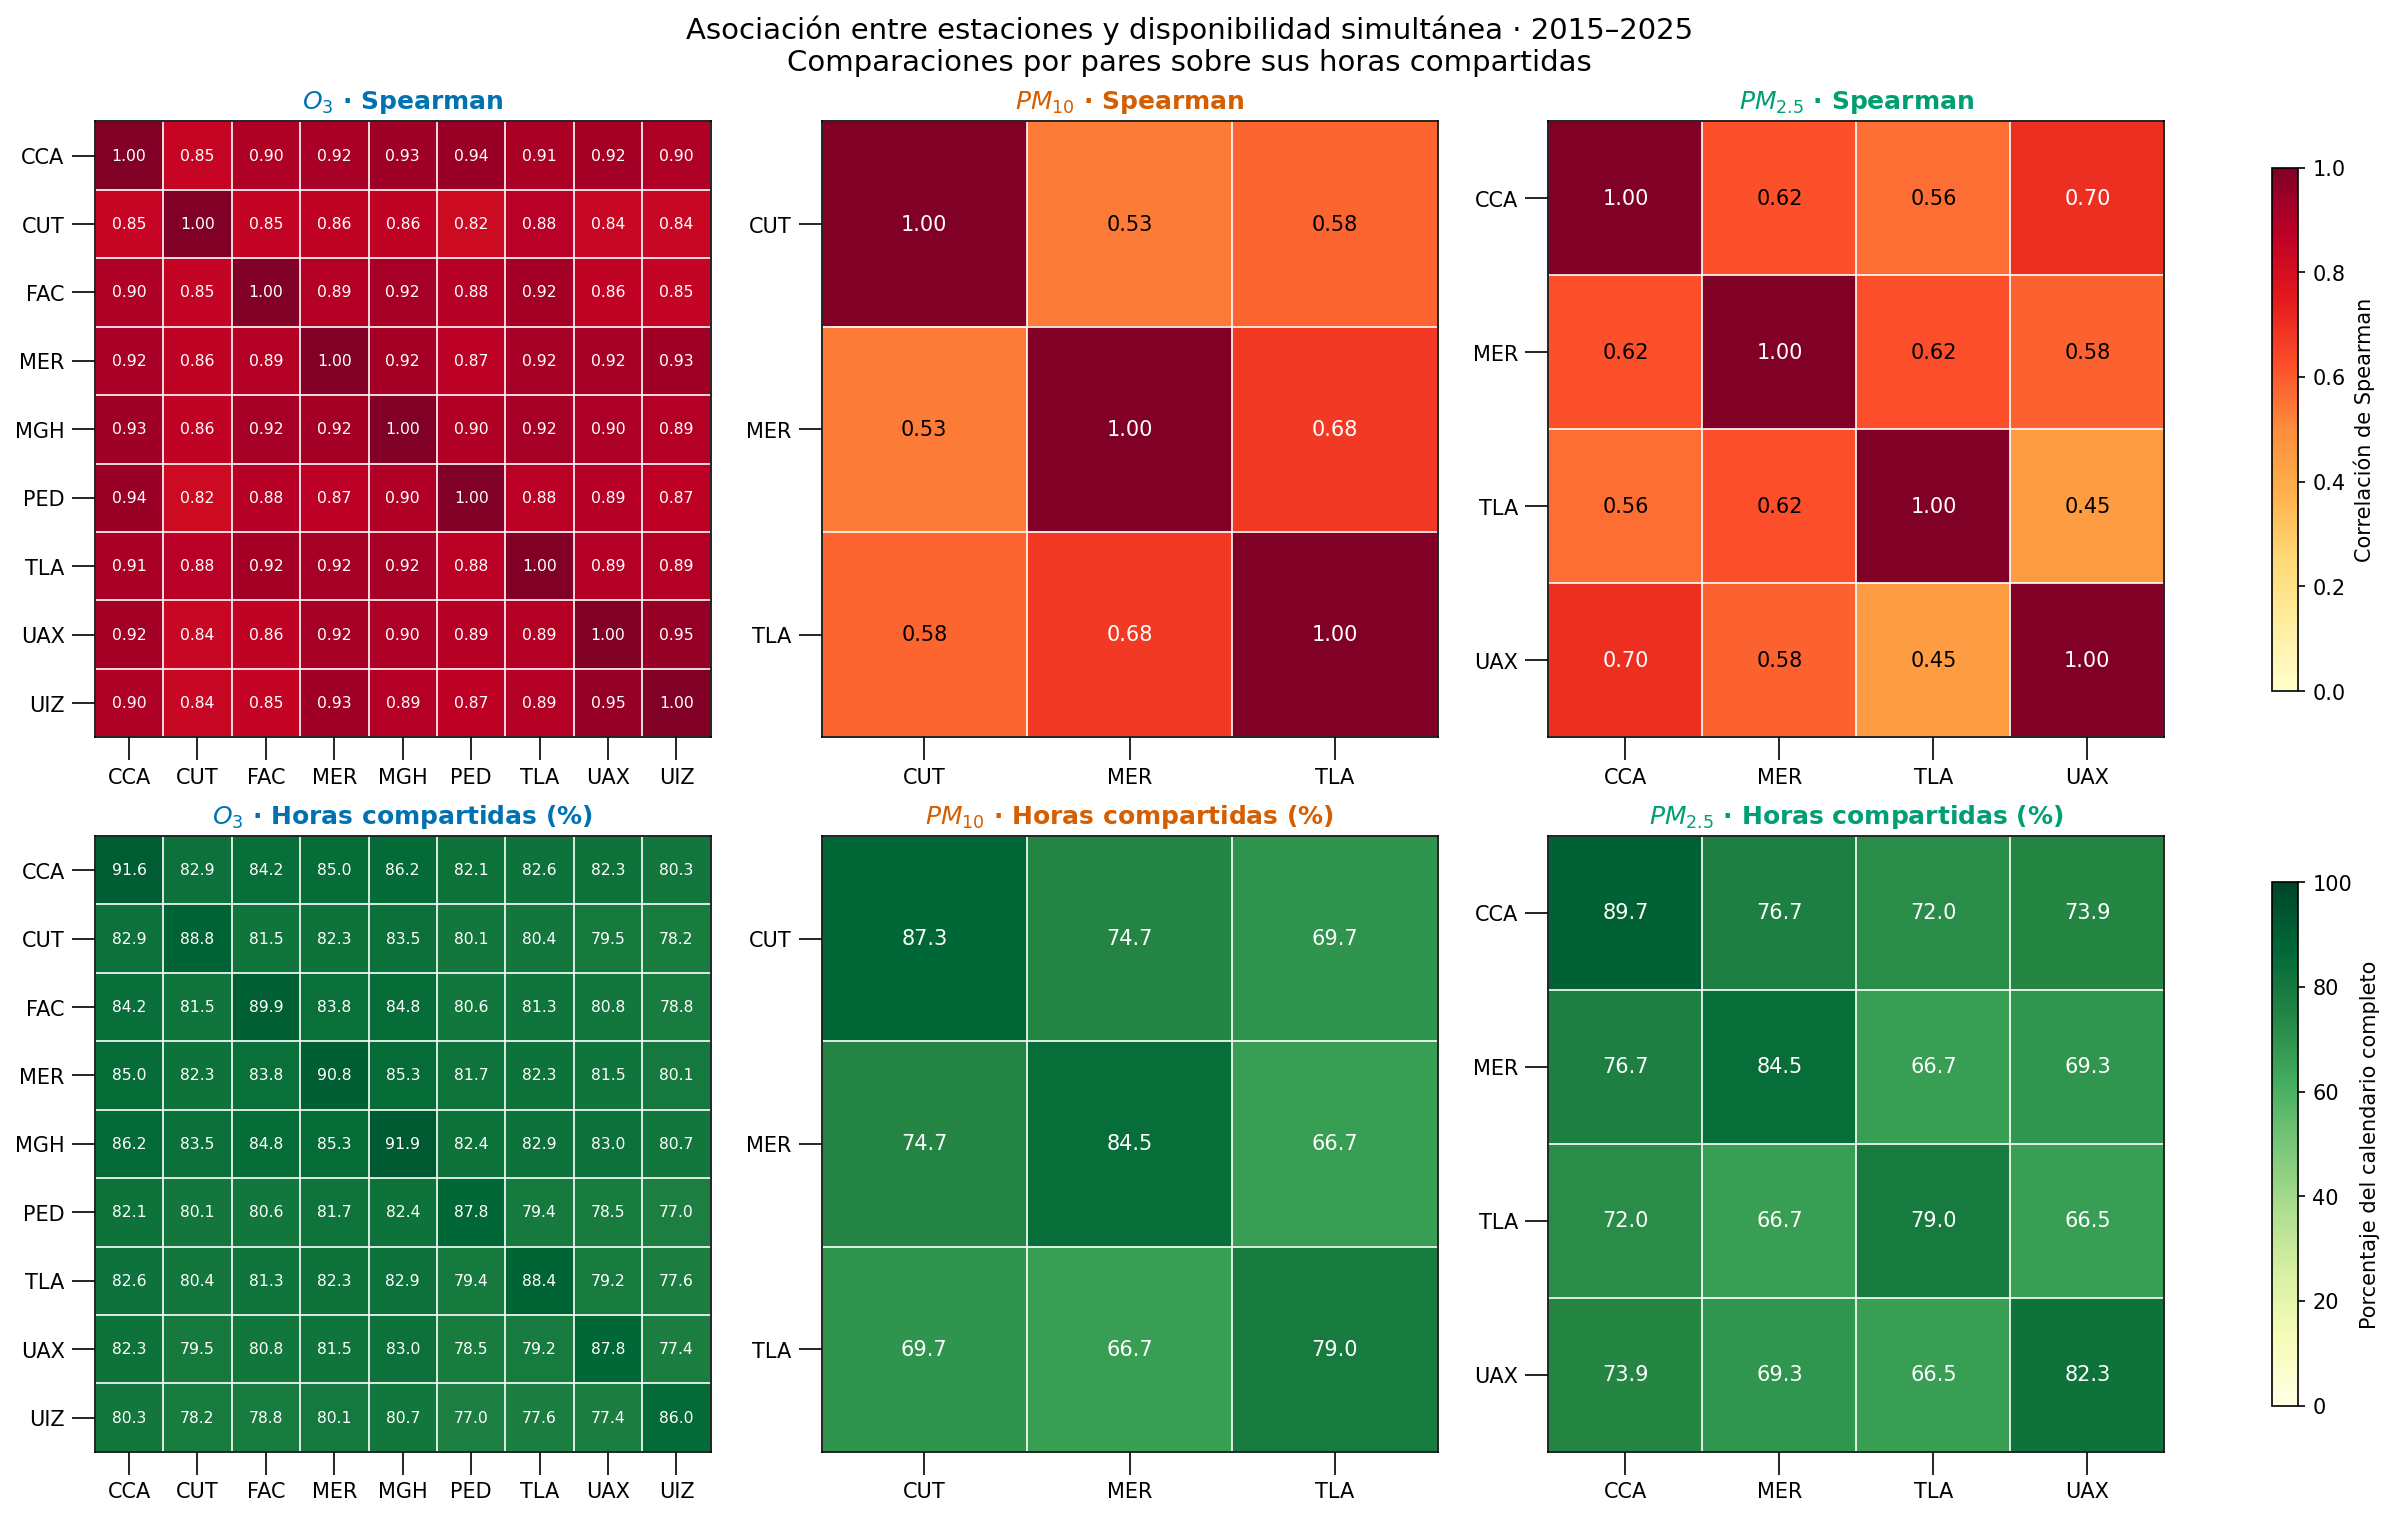


La diagonal inferior muestra disponibilidad individual.
Los conteos exactos permanecen en comparacion_pares_estaciones.


In [21]:
matrices_spearman = {}
matrices_horas_compartidas_pct = {}

for contaminante in CONTAMINANTES:
    estaciones = REDES_SELECCIONADAS[contaminante]

    matriz_correlacion = pd.DataFrame(np.nan,index=estaciones,columns=estaciones,)
    matriz_disponibilidad = pd.DataFrame(np.nan,index=estaciones,columns=estaciones,)

    # Diagonales: autocorrelación contemporánea y cobertura individual.
    for estacion in estaciones:
        observados = bases_horarias[contaminante][estacion].dropna()

        matriz_correlacion.loc[estacion, estacion] = (
            1.0 if observados.nunique() > 1 else np.nan)

        matriz_disponibilidad.loc[estacion, estacion] = (
            100 * len(observados) / len(INDICE_HORARIO_COMPLETO))

    pares = comparacion_pares_estaciones.loc[comparacion_pares_estaciones["CONTAMINANTE"].eq(contaminante)]

    for _, fila in pares.iterrows():
        estacion_a = fila["ESTACION_A"]
        estacion_b = fila["ESTACION_B"]

        for a, b in [(estacion_a, estacion_b),(estacion_b, estacion_a),]:
            matriz_correlacion.loc[a, b] = fila["SPEARMAN"]
            matriz_disponibilidad.loc[a, b] = fila["PCT_HORAS_COMPARTIDAS"]

    matrices_spearman[contaminante] = matriz_correlacion
    matrices_horas_compartidas_pct[contaminante] = matriz_disponibilidad


fig_asociacion_estaciones, axes = plt.subplots(2,3,figsize=(16, 10),dpi=150,constrained_layout=True,)

for columna, contaminante in enumerate(CONTAMINANTES):
    estaciones = REDES_SELECCIONADAS[contaminante]

    valores_correlacion = matrices_spearman[contaminante].to_numpy(dtype=float)

    valores_disponibilidad = matrices_horas_compartidas_pct[contaminante].to_numpy(dtype=float)

    imagen_correlacion = axes[0, columna].imshow(
        np.ma.masked_invalid(valores_correlacion),
        cmap="YlOrRd",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )

    imagen_disponibilidad = axes[1, columna].imshow(
        np.ma.masked_invalid(valores_disponibilidad),
        cmap="YlGn",
        vmin=0,
        vmax=100,
        interpolation="nearest",
    )

    for fila_panel, valores in [(0, valores_correlacion),(1, valores_disponibilidad),]:
        ax = axes[fila_panel, columna]

        ax.set_xticks(range(len(estaciones)))
        ax.set_yticks(range(len(estaciones)))
        ax.set_xticklabels(estaciones)
        ax.set_yticklabels(estaciones)
        ax.tick_params(direction='out', length=11)
        
        # Separaciones entre celdas.
        bordes = np.arange(-0.5, len(estaciones), 1)
        ax.set_xticks(bordes, minor=True)
        ax.set_yticks(bordes, minor=True)
        ax.grid(which="minor", color="white", linewidth=0.8)
        ax.tick_params(which="minor", bottom=False, left=False)

        for i in range(len(estaciones)):
            for j in range(len(estaciones)):
                valor = valores[i, j]

                if np.isnan(valor):
                    etiqueta = "NA"
                    color_texto = "black"
                elif fila_panel == 0:
                    etiqueta = f"{valor:.2f}"
                    color_texto = ("white" if abs(valor) >= 0.65 else "black")
                else:
                    etiqueta = f"{valor:.1f}"
                    color_texto = ("white" if valor >= 65 else "black")

                ax.text(
                    j,
                    i,
                    etiqueta,
                    ha="center",
                    va="center",
                    fontsize=7.5 if len(estaciones) > 5 else 10,
                    color=color_texto,
                )

        ax.set_title(
            f"{NOMBRES_CONTAMINANTES[contaminante]} · "
            + (
                "Spearman"
                if fila_panel == 0
                else "Horas compartidas (%)"
            ),
            color=COLORES_CONTAMINANTES[contaminante],
            fontsize=12,
            fontweight="bold",
        )

fig_asociacion_estaciones.colorbar(
    imagen_correlacion,
    ax=axes[0, :].tolist(),
    label="Correlación de Spearman",
    shrink=0.85,
)

fig_asociacion_estaciones.colorbar(
    imagen_disponibilidad,
    ax=axes[1, :].tolist(),
    label="Porcentaje del calendario completo",
    shrink=0.85,
)

fig_asociacion_estaciones.suptitle(
    "Asociación entre estaciones y disponibilidad simultánea · 2015–2025\n"
    "Comparaciones por pares sobre sus horas compartidas",
    fontsize=14,
)

ruta_fig_asociacion_estaciones = DIR_FIGURAS_01 / "asociacion_horas_compartidas_estaciones_2015_2025.png"

fig_asociacion_estaciones.savefig(
    ruta_fig_asociacion_estaciones,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("\nLa diagonal inferior muestra disponibilidad individual.")
print("Los conteos exactos permanecen en comparacion_pares_estaciones.")



La fila superior muestra las correlaciones de Spearman calculadas
sobre las horas compartidas de cada par. La fila inferior presenta
qué porcentaje del calendario completo participa en esas comparaciones.

**O₃.**  
Las asociaciones entre estaciones son altas: los coeficientes
fuera de la diagonal van aproximadamente de 0.82 a 0.95.

UAX–UIZ presenta la mayor asociación, con 0.950, seguida de
CCA–PED, con 0.942. CUT–PED presenta la menor, con 0.822,
aunque continúa siendo una asociación positiva alta.

Las horas compartidas representan entre 76.98% y 86.21% del
calendario. Por tanto, las comparaciones utilizan una fracción
amplia del periodo, pero no todas las horas ni necesariamente
las mismas fechas para cada par.

**PM₁₀.**  
Las asociaciones son menores que en O₃. MER–TLA presenta
el mayor coeficiente, con 0.676, y CUT–MER el menor, con 0.535.

CUT–MER tiene el mayor porcentaje de horas compartidas, de 74.66%.
Esto muestra que disponer de más horas conjuntas no implica
automáticamente una asociación mayor.

**PM₂.₅.**  
Los coeficientes varían entre 0.448 y 0.698. CCA–UAX presenta
la mayor asociación y TLA–UAX la menor.

La disponibilidad conjunta varía entre 66.55% y 76.66%.
CCA–MER tiene la mayor cobertura compartida, aunque no es
el par con mayor correlación.

**Diagonales y alcance.**  
La diagonal superior corresponde a la comparación de una estación
consigo misma. La diagonal inferior muestra su disponibilidad
individual, no la disponibilidad de toda la red.

Las asociaciones más altas de O₃ son compatibles con los perfiles
horarios semejantes observados anteriormente. Sin embargo, estas
correlaciones incluyen los patrones temporales comunes y no
demuestran equivalencia entre estaciones ni justifican sustituir
sus mediciones.

Cada par utiliza sus propias horas compartidas. Las matrices
describen asociaciones, no relaciones causales.

## 4. Integración de la base y preparación de los productos finales

La lectura, la auditoría y la exploración ya se realizaron por
contaminante. Ahora organizaremos los resultados en una estructura
conjunta que pueda reutilizarse en los siguientes notebooks.

## 4.1. Base conjunta de concentraciones y estados

Integraremos las tres redes en una tabla con:

- 96,432 filas, una por posición del calendario horario.
- 16 columnas de concentración, una por combinación de
  contaminante y estación.

Una estación puede medir varios contaminantes. Por ejemplo,
las columnas de O₃ en MER y PM₁₀ en MER representan variables
distintas, aunque correspondan a la misma ubicación.

### Identificación de las columnas

En la base exportable utilizaremos nombres como:

- `O3_CCA`
- `PM10_MER`
- `PM25_TLA`

También construiremos un diccionario de variables que vincule cada
nombre con su contaminante y estación.

### Tablas que se conservarán por separado

1. **Concentraciones:** valores observados y `NaN` para los faltantes.
2. **Estados:** origen de cada celda, como `OBSERVADO`,
   `CODIGO_MENOS_99` o `FILA_AUSENTE`.
3. **Información temporal y disponibilidad:** fecha, código horario
   y número de estaciones disponibles por contaminante.
4. **Diccionario de variables:** identificación de las 16 series.

Todas compartirán el mismo índice temporal cuando corresponda.
Separarlas facilita utilizar las concentraciones sin mezclar
columnas numéricas con etiquetas de estado.

La fecha y el código horario del calendario se reconstruirán para
todas las posiciones, incluidas las filas agregadas. En esas filas
son etiquetas temporales esperadas, no campos leídos de una fila
original.

### Comprobaciones de integración

Verificaremos que:

- Las bases tengan el mismo calendario.
- Los nombres de las variables sean únicos.
- La integración conserve cada serie de concentración.
- Las celdas con estado `OBSERVADO` coincidan con valores no faltantes.
- El número de estaciones disponibles reproduzca las series
  calculadas anteriormente.

No se construirán promedios de red, etiquetas de episodios,
predictores ni imputaciones en esta sección.

### Documentación pendiente

La base quedará preparada estructuralmente, pero aún deben
confirmarse las unidades, la zona horaria y el significado del
intervalo de medición.

Estas cuestiones se conservarán explícitamente como pendientes
en el diccionario y en la documentación de exportación.

In [22]:
partes_concentraciones = []
partes_estados = []
registros_diccionario = []

for contaminante in CONTAMINANTES:
    base = bases_horarias[contaminante]
    estados = estados_horarios[contaminante]

    if not base.index.equals(INDICE_HORARIO_COMPLETO):
        raise ValueError(f"El calendario de concentraciones difiere en {contaminante}.")

    if (
        not estados.index.equals(base.index)
        or not estados.columns.equals(base.columns)
    ):
        raise ValueError(f"Los estados no están alineados en {contaminante}.")

    nombres_variables = {
        estacion: f"{contaminante}_{estacion}"
        for estacion in REDES_SELECCIONADAS[contaminante]
    }

    partes_concentraciones.append(base.rename(columns=nombres_variables))
    partes_estados.append(estados.rename(columns=nombres_variables))

    for estacion, variable in nombres_variables.items():
        registros_diccionario.append(
            {
                "VARIABLE": variable,
                "CONTAMINANTE": contaminante,
                "ESTACION": estacion,
                "UNIDAD": "PENDIENTE_DE_CONFIRMACION",
                "VALOR_FALTANTE_EN_BASE": "NaN",
                "IMPUTACION_REALIZADA": False,
            }
        )

base_horaria_conjunta = pd.concat(partes_concentraciones, axis=1)

estados_horarios_conjuntos = pd.concat(partes_estados, axis=1)

diccionario_variables_01 = pd.DataFrame(registros_diccionario)

if not base_horaria_conjunta.columns.is_unique:
    raise ValueError("Hay nombres de variables duplicados.")

n_variables_esperadas = sum(
    len(REDES_SELECCIONADAS[c])
    for c in CONTAMINANTES
)

if base_horaria_conjunta.shape != (
    len(INDICE_HORARIO_COMPLETO),
    n_variables_esperadas,
):
    raise ValueError("Las dimensiones conjuntas no son las esperadas.")

if not base_horaria_conjunta.notna().equals(
    estados_horarios_conjuntos.eq("OBSERVADO")
):
    raise ValueError(
        "Los estados conjuntos no coinciden con las concentraciones."
    )


# Etiquetas del calendario completo, incluidas las posiciones agregadas.
informacion_horaria_01 = pd.DataFrame(index=INDICE_HORARIO_COMPLETO)

informacion_horaria_01["FECHA_CALENDARIO"] = (INDICE_HORARIO_COMPLETO.normalize())
informacion_horaria_01["HORA_CODIGO"] = (INDICE_HORARIO_COMPLETO.hour + 1)
informacion_horaria_01["ANIO"] = INDICE_HORARIO_COMPLETO.year
informacion_horaria_01["MES"] = INDICE_HORARIO_COMPLETO.month

for contaminante in CONTAMINANTES:
    variables = diccionario_variables_01.loc[
        diccionario_variables_01["CONTAMINANTE"].eq(contaminante),
        "VARIABLE",
    ].tolist()

    k_conjunto = (base_horaria_conjunta[variables].notna().sum(axis=1))

    if not k_conjunto.equals(series_estaciones_disponibles[contaminante]):
        raise ValueError(f"La disponibilidad cambió al integrar {contaminante}.")

    informacion_horaria_01[
        f"N_ESTACIONES_DISPONIBLES_{contaminante}"
    ] = k_conjunto

    informacion_horaria_01[
        f"FILA_ORIGINAL_PRESENTE_{contaminante}"
    ] = ~estados_horarios_conjuntos[
        variables
    ].eq("FILA_AUSENTE").all(axis=1)

    # Verificar cada serie contra su base por contaminante.
    for estacion in REDES_SELECCIONADAS[contaminante]:
        variable = f"{contaminante}_{estacion}"

        if not base_horaria_conjunta[variable].equals(
            bases_horarias[contaminante][estacion]
        ):
            raise ValueError(f"La serie {variable} cambió durante la integración.")


print("Dimensiones de los productos integrados:")
display(
    pd.DataFrame(
        [
            {
                "PRODUCTO": "Concentraciones",
                "FILAS": len(base_horaria_conjunta),
                "COLUMNAS": base_horaria_conjunta.shape[1],
            },
            {
                "PRODUCTO": "Estados",
                "FILAS": len(estados_horarios_conjuntos),
                "COLUMNAS": estados_horarios_conjuntos.shape[1],
            },
            {
                "PRODUCTO": "Información horaria",
                "FILAS": len(informacion_horaria_01),
                "COLUMNAS": informacion_horaria_01.shape[1],
            },
            {
                "PRODUCTO": "Diccionario de variables",
                "FILAS": len(diccionario_variables_01),
                "COLUMNAS": diccionario_variables_01.shape[1],
            },
        ]
    )
)

print("\nDiccionario de las 16 variables:")
display(diccionario_variables_01)

print("\nPrimeras cinco filas de la base conjunta:")
with pd.option_context("display.max_columns", None):
    display(base_horaria_conjunta.head())

print("\nPrimeras cinco filas de la información horaria:")
with pd.option_context("display.max_columns", None):
    display(informacion_horaria_01.head())

print("\nLa integración conserva las concentraciones y su disponibilidad.")
print("Unidades, zona horaria e interpretación del intervalo: pendientes.")

Dimensiones de los productos integrados:


,PRODUCTO,FILAS,COLUMNAS
0,Concentraciones,96432,16
1,Estados,96432,16
2,Información horaria,96432,10
3,Diccionario de variables,16,6



Diccionario de las 16 variables:


,VARIABLE,CONTAMINANTE,ESTACION,UNIDAD,VALOR_FALTANTE_EN_BASE,IMPUTACION_REALIZADA
0,O3_CCA,O3,CCA,PENDIENTE_DE_CONFIRMACION,NaN,False
1,O3_CUT,O3,CUT,PENDIENTE_DE_CONFIRMACION,NaN,False
2,O3_FAC,O3,FAC,PENDIENTE_DE_CONFIRMACION,NaN,False
3,O3_MER,O3,MER,PENDIENTE_DE_CONFIRMACION,NaN,False
4,O3_MGH,O3,MGH,PENDIENTE_DE_CONFIRMACION,NaN,False
5,O3_PED,O3,PED,PENDIENTE_DE_CONFIRMACION,NaN,False
6,O3_TLA,O3,TLA,PENDIENTE_DE_CONFIRMACION,NaN,False
7,O3_UAX,O3,UAX,PENDIENTE_DE_CONFIRMACION,NaN,False
8,O3_UIZ,O3,UIZ,PENDIENTE_DE_CONFIRMACION,NaN,False
9,PM10_CUT,PM10,CUT,PENDIENTE_DE_CONFIRMACION,NaN,False



Primeras cinco filas de la base conjunta:


,O3_CCA,O3_CUT,O3_FAC,O3_MER,O3_MGH,O3_PED,O3_TLA,O3_UAX,O3_UIZ,PM10_CUT,PM10_MER,PM10_TLA,PM25_CCA,PM25_MER,PM25_TLA,PM25_UAX
TIEMPO_INTERNO,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,2.0,3.0,5.0,3.0,3.0,NaN,3.0,2.0,2.0,186.0,123.0,NaN,118.0,84.0,NaN,132.0
2015-01-01 01:00:00,4.0,3.0,5.0,2.0,5.0,NaN,3.0,2.0,2.0,177.0,113.0,NaN,107.0,79.0,NaN,138.0
2015-01-01 02:00:00,1.0,3.0,5.0,2.0,4.0,NaN,4.0,2.0,4.0,223.0,118.0,NaN,121.0,87.0,NaN,123.0
2015-01-01 03:00:00,2.0,3.0,4.0,NaN,3.0,NaN,4.0,4.0,4.0,225.0,NaN,NaN,124.0,NaN,NaN,129.0
2015-01-01 04:00:00,1.0,3.0,4.0,3.0,4.0,NaN,2.0,5.0,4.0,147.0,NaN,NaN,123.0,NaN,NaN,132.0



Primeras cinco filas de la información horaria:


,FECHA_CALENDARIO,HORA_CODIGO,ANIO,MES,N_ESTACIONES_DISPONIBLES_O3,FILA_ORIGINAL_PRESENTE_O3,N_ESTACIONES_DISPONIBLES_PM10,FILA_ORIGINAL_PRESENTE_PM10,N_ESTACIONES_DISPONIBLES_PM25,FILA_ORIGINAL_PRESENTE_PM25
TIEMPO_INTERNO,,,,,,,,,,
2015-01-01 00:00:00,2015-01-01,1,2015,1,8,True,2,True,3,True
2015-01-01 01:00:00,2015-01-01,2,2015,1,8,True,2,True,3,True
2015-01-01 02:00:00,2015-01-01,3,2015,1,8,True,2,True,3,True
2015-01-01 03:00:00,2015-01-01,4,2015,1,7,True,1,True,2,True
2015-01-01 04:00:00,2015-01-01,5,2015,1,8,True,1,True,2,True



La integración conserva las concentraciones y su disponibilidad.
Unidades, zona horaria e interpretación del intervalo: pendientes.


## 4.2. Exportación y verificación de los resultados

Los resultados deben guardarse para que el siguiente notebook pueda
ejecutarse desde cero, sin depender de las variables en memoria.

### Productos principales

Exportaremos tres tablas horarias:

1. **Concentraciones:** las 16 variables, con valores faltantes como `NaN`.
2. **Estados:** la clasificación de cada celda observada o faltante.
3. **Información horaria:** etiquetas del calendario, disponibilidad
   de las redes y presencia de las filas originales.

Se guardarán como archivos `CSV.gz`. Son archivos CSV comprimidos:
pandas puede leerlos directamente y ocupan menos espacio, especialmente
en la tabla de estados, donde las etiquetas se repiten muchas veces.

El índice se exportará como una columna llamada `TIEMPO_INTERNO`.

### Tablas de documentación y análisis

También guardaremos:

- El diccionario de variables y las coordenadas de las redes.
- El inventario y las auditorías de lectura, tiempo y concentraciones.
- Los resúmenes de disponibilidad y la verificación con el notebook 00.
- Los estadísticos descriptivos y el contexto de los máximos.
- Los perfiles horarios, mensuales y anuales.
- Las comparaciones entre pares de estaciones.

Estas tablas se guardarán como CSV sin redondear previamente
sus resultados numéricos.

### Configuración y figuras

Un archivo JSON documentará el periodo, las redes y las decisiones
de preparación. Las unidades, la zona horaria y la interpretación
del intervalo seguirán registradas como pendientes de confirmación.

Un inventario identificará las siete figuras generadas y comprobará
su existencia.

### Verificación después de guardar

Leeremos nuevamente las tres tablas horarias y las compararemos
con los objetos en memoria.

Comprobaremos que se conserven:

- El índice temporal y los nombres de las columnas.
- Las concentraciones y sus valores faltantes.
- Las etiquetas de estado.
- La información temporal y de disponibilidad.

Además, el inventario de archivos incluirá su tamaño y una huella
SHA-256. Esta huella permite detectar posteriormente si cambia
el contenido de un archivo; no certifica su calidad científica.

Los resultados se guardarán en `resultados_01_base_horaria_RAMA`.
Si la celda se ejecuta nuevamente, actualizará los archivos con
los mismos nombres.

In [23]:
import hashlib
import json


DIR_RESULTADOS_01.mkdir(parents=True, exist_ok=True)

# 1. Comprobar la existencia de las figuras.
rutas_figuras_01 = [
    ruta_fig_distribucion_estaciones,
    ruta_fig_distribuciones_concentracion,
    ruta_fig_contexto_maximos,
    ruta_fig_perfiles_horarios,
    ruta_fig_perfiles_mensuales,
    ruta_fig_comparacion_anual,
    ruta_fig_asociacion_estaciones,
]

inventario_figuras_01 = pd.DataFrame(
    [
        {
            "FIGURA": ruta.name,
            "RUTA_RELATIVA": ruta.relative_to(DIR_RESULTADOS_01).as_posix(),
            "EXISTE": ruta.is_file(),
        }
        for ruta in rutas_figuras_01
    ]
)

if not inventario_figuras_01["EXISTE"].all():
    display(inventario_figuras_01.loc[~inventario_figuras_01["EXISTE"]])
    raise FileNotFoundError("Faltan figuras. Revisa las rutas antes de exportar.")


# 2. Exportar las tablas horarias comprimidas.
tablas_horarias_exportar = {
    "base_horaria_concentraciones_2015_2025.csv.gz":
        base_horaria_conjunta,
    "estados_horarios_2015_2025.csv.gz":
        estados_horarios_conjuntos,
    "informacion_horaria_2015_2025.csv.gz":
        informacion_horaria_01,
}

registros_exportacion = []

for nombre, tabla in tablas_horarias_exportar.items():
    ruta = DIR_RESULTADOS_01 / nombre

    tabla.to_csv(
        ruta,
        index=True,
        index_label="TIEMPO_INTERNO",
        encoding="utf-8-sig",
        compression="gzip",
        na_rep="NaN",
        date_format="%Y-%m-%d %H:%M:%S",
    )

    registros_exportacion.append(
        {
            "ARCHIVO": nombre,
            "FILAS": len(tabla),
            "COLUMNAS_ARCHIVO": tabla.shape[1] + 1,
        }
    )


# 3. Exportar las tablas de documentación y análisis.
tablas_resumen_exportar = {
    "diccionario_variables.csv": diccionario_variables_01,
    "redes_seleccionadas_con_coordenadas.csv": coordenadas_redes_00,
    "inventario_archivos_originales.csv": inventario_01,
    "auditoria_lectura.csv": auditoria_lectura_01,
    "auditoria_temporal.csv": auditoria_temporal_01,
    "horas_ausentes_archivos.csv": horas_ausentes_archivos,
    "auditoria_valores.csv": auditoria_valores_01,
    "resumen_preparacion_estaciones.csv": resumen_preparacion_estaciones,
    "indicadores_redes.csv": indicadores_redes_01,
    "verificacion_consistencia_nb00_nb01.csv": verificacion_consistencia_01,
    "distribucion_estaciones_disponibles.csv": distribucion_estaciones_disponibles,
    "descriptivos_concentraciones.csv": descriptivos_concentraciones,
    "contexto_maximos_estaciones.csv": contexto_maximos_estaciones,
    "perfil_horario_estaciones.csv": perfil_horario_estaciones,
    "resumen_perfil_horario.csv": resumen_perfil_horario,
    "perfil_mensual_estaciones.csv": perfil_mensual_estaciones,
    "resumen_perfil_mensual.csv": resumen_perfil_mensual,
    "descriptivos_anuales_estaciones.csv": descriptivos_anuales_estaciones,
    "comparacion_pares_estaciones.csv": comparacion_pares_estaciones,
    "inventario_figuras.csv": inventario_figuras_01,
}

for nombre, tabla in tablas_resumen_exportar.items():
    ruta = DIR_RESULTADOS_01 / nombre

    tabla.to_csv(
        ruta,
        index=False,
        encoding="utf-8-sig",
        na_rep="NaN",
        date_format="%Y-%m-%d %H:%M:%S",
    )

    registros_exportacion.append(
        {
            "ARCHIVO": nombre,
            "FILAS": len(tabla),
            "COLUMNAS_ARCHIVO": tabla.shape[1],
        }
    )


# 4. Documentar la configuración.
configuracion_base_01 = {
    "anios_estudio": ANIOS_ESTUDIO,
    "resolucion_temporal": "horaria",
    "n_horas_calendario": len(INDICE_HORARIO_COMPLETO),
    "n_variables_concentracion": base_horaria_conjunta.shape[1],
    "redes_seleccionadas": REDES_SELECCIONADAS,
    "indice_temporal_interno": "FECHA + (HORA - 1) horas",
    "zona_horaria": None,
    "zona_horaria_confirmada": False,
    "interpretacion_intervalo_confirmada": False,
    "unidades_confirmadas": False,
    "unidades_por_contaminante": {
        contaminante: None
        for contaminante in CONTAMINANTES
    },
    "codigo_faltante_original": -99,
    "representacion_faltantes_csv": "NaN",
    "imputacion_realizada": False,
    "ceros_conservados": True,
    "extremos_eliminados": False,
    "datos_2026_incluidos": False,
    "etiquetas_episodios_definidas": False,
    "estados_celdas": {
        "OBSERVADO": "Número finito distinto de -99",
        "CODIGO_MENOS_99": "Código -99 en una fila original",
        "CELDA_VACIA": "Celda vacía en una fila original",
        "FILA_AUSENTE": "Posición sin fila en el archivo original",
    },
    "archivo_diagnostico_origen":
        "resultados_00_diagnostico_RAMA_contingencias/"
        "configuracion_diagnostico.json",
    "archivos_horarios": list(tablas_horarias_exportar),
    "pendientes": [
        "Confirmar las unidades de los archivos originales",
        "Confirmar la zona horaria de la fuente",
        "Confirmar si HORA indica inicio o final del intervalo",
        "Documentar el estado de validación instrumental de los datos",
    ],
}

ruta_configuracion_base_01 = DIR_RESULTADOS_01 / "configuracion_base_horaria.json"

with ruta_configuracion_base_01.open(
    "w", encoding="utf-8"
) as archivo:
    json.dump(
        configuracion_base_01,
        archivo,
        ensure_ascii=False,
        indent=2,
        allow_nan=False,
    )


# 5. Recuperar y verificar las tres tablas horarias.
base_recuperada = pd.read_csv(
    DIR_RESULTADOS_01
    / "base_horaria_concentraciones_2015_2025.csv.gz",
    encoding="utf-8-sig",
    index_col="TIEMPO_INTERNO",
    parse_dates=["TIEMPO_INTERNO"],
    float_precision="round_trip",
)

estados_recuperados = pd.read_csv(
    DIR_RESULTADOS_01 / "estados_horarios_2015_2025.csv.gz",
    encoding="utf-8-sig",
    index_col="TIEMPO_INTERNO",
    parse_dates=["TIEMPO_INTERNO"],
    keep_default_na=False,
)

informacion_recuperada = pd.read_csv(
    DIR_RESULTADOS_01 / "informacion_horaria_2015_2025.csv.gz",
    encoding="utf-8-sig",
    index_col="TIEMPO_INTERNO",
    parse_dates=["TIEMPO_INTERNO", "FECHA_CALENDARIO"],
)

for original, recuperada in [
    (base_horaria_conjunta, base_recuperada),
    (estados_horarios_conjuntos, estados_recuperados),
    (informacion_horaria_01, informacion_recuperada),
]:
    pd.testing.assert_frame_equal(
        original,
        recuperada,
        check_dtype=False,
        check_freq=False,
        check_exact=True,
    )


# 6. Inventario con tamaños y huellas de los archivos.
def calcular_sha256(ruta):
    huella = hashlib.sha256()

    with ruta.open("rb") as archivo:
        for bloque in iter(lambda: archivo.read(1024 * 1024), b""):
            huella.update(bloque)

    return huella.hexdigest()


inventario_exportacion_01 = pd.DataFrame(registros_exportacion)

inventario_exportacion_01["BYTES"] = (
    inventario_exportacion_01["ARCHIVO"].map(
        lambda nombre: (DIR_RESULTADOS_01 / nombre).stat().st_size
    )
)

inventario_exportacion_01["SHA256"] = (
    inventario_exportacion_01["ARCHIVO"].map(
        lambda nombre: calcular_sha256(DIR_RESULTADOS_01 / nombre)
    )
)

inventario_exportacion_01.to_csv(
    DIR_RESULTADOS_01 / "inventario_exportacion.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Directorio de resultados:")
print(DIR_RESULTADOS_01.resolve())

print("\nTablas exportadas:")
display(inventario_exportacion_01[["ARCHIVO", "FILAS", "COLUMNAS_ARCHIVO", "BYTES"]])

print("\nFiguras documentadas:")
display(inventario_figuras_01)

print("\nConfiguración guardada:")
print(ruta_configuracion_base_01.name)

print("\nLas tres tablas horarias se recuperaron sin cambios.")
print("El inventario incluye las huellas SHA-256 de las tablas.")
print("Los pendientes de documentación quedaron registrados.")

Directorio de resultados:
/Users/juanalbertomartinez/Desktop/contaminantes_Isay/resultados_01_base_horaria_RAMA

Tablas exportadas:


,ARCHIVO,FILAS,COLUMNAS_ARCHIVO,BYTES
0,base_horaria_concentraciones_2015_2025.csv.gz,96432,17,1912514
1,estados_horarios_2015_2025.csv.gz,96432,17,340084
2,informacion_horaria_2015_2025.csv.gz,96432,11,558132
3,diccionario_variables.csv,16,6,913
4,redes_seleccionadas_con_coordenadas.csv,16,8,1154
5,inventario_archivos_originales.csv,33,7,4229
6,auditoria_lectura.csv,33,11,1953
7,auditoria_temporal.csv,33,12,1558
8,horas_ausentes_archivos.csv,6,5,361
9,auditoria_valores.csv,176,13,8642



Figuras documentadas:


,FIGURA,RUTA_RELATIVA,EXISTE
0,distribucion_estaciones_disponibles_2015_2025.png,figuras/distribucion_estaciones_disponibles_20...,True
1,distribuciones_concentracion_estaciones_2015_2...,figuras/distribuciones_concentracion_estacione...,True
2,contexto_temporal_maximos_redes_2015_2025.png,figuras/contexto_temporal_maximos_redes_2015_2...,True
3,perfiles_horarios_concentracion_disponibilidad...,figuras/perfiles_horarios_concentracion_dispon...,True
4,perfiles_mensuales_concentracion_disponibilida...,figuras/perfiles_mensuales_concentracion_dispo...,True
5,comparacion_anual_concentracion_disponibilidad...,figuras/comparacion_anual_concentracion_dispon...,True
6,asociacion_horas_compartidas_estaciones_2015_2...,figuras/asociacion_horas_compartidas_estacione...,True



Configuración guardada:
configuracion_base_horaria.json

Las tres tablas horarias se recuperaron sin cambios.
El inventario incluye las huellas SHA-256 de las tablas.
Los pendientes de documentación quedaron registrados.


## 5. Conclusiones y alcance de la base preparada

### 5.1. Construcción y validación

Se construyó una base horaria para los años completos 2015–2025,
con 96,432 posiciones temporales y 16 variables de concentración:

| Contaminante | Estaciones | Número |
|---|---|---:|
| O₃ | CCA, CUT, FAC, MER, MGH, PED, TLA, UAX, UIZ | 9 |
| PM₁₀ | CUT, MER, TLA | 3 |
| PM₂.₅ | CCA, MER, TLA, UAX | 4 |

Estas combinaciones corresponden a nueve ubicaciones distintas.

Se revisaron los 33 archivos originales. No se encontraron fechas
u horas inválidas, registros temporales duplicados ni problemas
de orden cronológico.

Los tres contaminantes carecen de las mismas dos filas de 2024:

| Fecha | Código horario original |
|---|---:|
| 2024-01-17 | 19 |
| 2024-04-06 | 24 |

Estas posiciones se incorporaron al calendario con concentraciones
faltantes. No se estimaron sus mediciones.

### 5.2. Tratamiento de las concentraciones

En las estaciones seleccionadas no se encontraron contenidos
no numéricos, valores infinitos ni negativos distintos de `-99`.

El código `-99` se reemplazó por `NaN`. Se conservaron los ceros
y los valores extremos, y se documentó por separado el origen
de cada valor faltante.

La preparación no incluyó imputación, recorte de extremos,
conversión de unidades ni incorporación de datos parciales de 2026.

### 5.3. Consistencia con el diagnóstico

Los indicadores recalculados coinciden con los exportados
por el notebook 00:

| Contaminante | Horas con ≥1 estación | Horas con ≥2 estaciones | Horas con toda la red | Mayor racha sin red |
|---|---:|---:|---:|---:|
| O₃ | 98.04% | 97.79% | 42.78% | 6 horas |
| PM₁₀ | 99.30% | 92.08% | 59.48% | 53 horas |
| PM₂.₅ | 99.82% | 97.76% | 51.52% | 24 horas |

La alta disponibilidad de alguna estación no implica que toda la
red esté disponible simultáneamente. Esta distinción deberá
conservarse al construir indicadores de concentración de la red.

### 5.4. Resultados exploratorios

Las distribuciones presentan medias mayores que sus medianas
y valores altos alejados de la parte central.

La revisión de los máximos mostró aumentos compartidos entre
varias estaciones en O₃ y contrastes espaciales más marcados
en algunos casos de partículas. Este contexto no confirma por
sí solo la calidad instrumental ni identifica la causa del aumento.

Los perfiles horarios de O₃ presentan medianas máximas en los
códigos 14–15. En partículas, los perfiles difieren más entre
estaciones y sus máximos centrales aparecen principalmente
entre los códigos 8 y 11.

Los perfiles por mes del calendario muestran:

- Medianas mayores de O₃ en abril–mayo.
- Medianas de PM₁₀ menores entre junio y octubre respecto a
  los primeros y últimos meses del año.
- Aumentos de PM₂.₅ en abril–mayo y hacia el final del año.

Estos resultados describen las observaciones disponibles de
los once años; no establecen causas ni prueban que el patrón
sea idéntico cada año.

### 5.5. Cobertura y comparación espacial

La disponibilidad cambia entre estaciones, códigos horarios,
meses y años. Destaca la menor cobertura de 2024 en TLA para
ambas partículas y en UAX para PM₂.₅.

Estas diferencias pueden cambiar la composición temporal
de las observaciones que participan en los resúmenes.

Las comparaciones sobre horas compartidas mostraron asociaciones
de Spearman más altas en O₃ que en partículas:

| Contaminante | Rango de Spearman entre pares |
|---|---:|
| O₃ | 0.822–0.950 |
| PM₁₀ | 0.535–0.676 |
| PM₂.₅ | 0.448–0.698 |

Las correlaciones incluyen patrones temporales comunes.
No demuestran equivalencia entre estaciones ni justifican
sustituir o imputar sus mediciones.

### 5.6. Productos obtenidos

Se exportaron las concentraciones, los estados de las celdas,
la información horaria, el diccionario de variables, las auditorías
y los resultados exploratorios.

También se documentaron siete figuras y la configuración
de preparación.

Las tres tablas horarias fueron leídas nuevamente y comparadas
con los objetos en memoria, conservando sus valores, faltantes,
columnas e índice temporal.

### 5.7. Pendientes antes de definir episodios

La base está validada en su estructura y preparación, pero deben
confirmarse documentalmente:

1. Las unidades de concentración de los archivos originales.
2. La zona horaria utilizada por la fuente.
3. Si el código HORA representa el inicio o el final del intervalo.
4. El estado de validación y los controles de calidad de las mediciones.

Estos pendientes son necesarios para interpretar las concentraciones
y relacionarlas correctamente con umbrales o eventos externos.

El siguiente notebook abordará la definición de los episodios y
de sus etiquetas, distinguiendo los extremos medidos de las
contingencias oficiales.

Las decisiones sobre umbrales, transformaciones y modelos deberán
respetar la separación temporal entre entrenamiento y evaluación.
En este notebook todavía no se definieron episodios ni se evaluó
capacidad de anticipación.

## 6. Cuestionario de comprensión


1. ¿Por qué trabajamos con datos horarios de 2015–2025? ¿Qué información
   podría perderse al utilizar promedios diarios?

2. ¿Por qué la base contiene 96,432 horas y 16 variables, pero solamente
   nueve ubicaciones distintas? Justifica ambos conteos.

3. ¿Qué diferencia existe entre una fila horaria ausente, el código
   `-99` y una concentración igual a cero? ¿Cómo se trataron?

4. Explica la transformación `FECHA + (HORA - 1)` y los aspectos de
   interpretación temporal que todavía debemos confirmar.

5. ¿Por qué completar el calendario con `NaN` no equivale a imputar?
   ¿Qué problema tendría una imputación que utiliza información futura
   para construir predictores?

6. ¿Cómo puede PM₁₀ tener alguna estación disponible en 99.30% de las
   horas, pero su red completa solamente en 59.48%?

7. ¿Qué diferencias existen entre mediana, percentil 95 y máximo?
   ¿Por qué no eliminamos automáticamente las concentraciones extremas?

8. ¿Qué patrones horarios y mensuales observaste en los contaminantes?
   Explica cómo los faltantes pueden afectar su interpretación.

9. **Ejercicio de gráfica:** utiliza `resumen_preparacion_estaciones.csv`
   para construir barras horizontales de disponibilidad de las 16
   variables. Ordénalas, utiliza un color por contaminante e identifica
   la mayor y la menor disponibilidad. Explica por qué esta gráfica
   no muestra la disponibilidad simultánea de toda la red.

10. **Ejercicio de gráfica:** utiliza `perfil_horario_estaciones.csv`
    para graficar la mediana de PM₂.₅ en MER por código horario y sombrear
    P25–P75. Identifica el código con mayor mediana y explica por qué
    la banda no es un intervalo de confianza ni la curva representa
    un día particular.

